# Kindle eBook User Analysis and Recommendation System

This notebook consolidates the complete project workflow into one logical narrative: **data analysis and preprocessing → content-based recommendation → sequential recommendation → Two-Tower  → hybrid recommendation**.

The implementation uses a shared chronological protocol: training history is used for validation, while training history plus the validation item is used as the test context. Each held-out positive is ranked against the same 100 pre-generated negatives. Model selection is based on validation NDCG@10.

| Name | zID |
|---|---|
| Jiayu Chen | z5654380 |
|Lumi Wu  |  z5653789|
| Yilan Luo | z5670641 |
| Yinan Zhang | z5535762 |
| Weisi Li | z5538537 |

## Problem statement

Personalised recommendation for Kindle eBooks is difficult because the interaction matrix is extremely sparse, user activity is highly skewed, and item metadata is heterogeneous. A single paradigm is rarely sufficient: content-based methods exploit titles, categories and descriptions but ignore collaborative structure; sequential models capture reading order but can underuse static metadata; two tower recovers preference patterns yet struggles with cold or long-tail items.

This project therefore builds a unified recommendation pipeline on the Amazon Kindle Store reviews. After chronological preprocessing and fixed negative sampling, three complementary models are trained under one evaluation protocol: content-based scoring, sequential next-item prediction and Two-Tower. These models are then combined through hybrid fusion and re-ranking. The goal is to measure how much each component contributes and whether a carefully designed hybrid system can improve ranking quality over any individual model on the same candidate sets.

## Project workflow

| Stage | Main purpose | Handoff to the next stage |
|---|---|---|
| Data analysis and processing | Audit the Kindle data, clean metadata/interactions, apply 5-core filtering, chronological splitting and fixed negative sampling | `processed_kindle/` |
| Content-Based | Represent item metadata with TF-IDF/SVD and build user profiles | `outputs/content_based/content_based_candidate_scores.csv.gz` |
| Sequential | Compare Markov, SASRec and GRU4Rec next-item models | `outputs/gru4rec_best.pt` |
| Two-Tower | Learn user/item embeddings with hybrid negative sampling | `outputs/collaborative_model.pt` |
| Hybrid | Align candidate scores, fuse/rerank them and compare final systems | `outputs/hybrid/` |

## Shared execution environment

Run this notebook from either the repository root, `proj2/`, or `proj2/8.2ver/`. The cell below normalises all relative paths to `proj2/`. Expensive raw-data processing and neural searches remain explicit project stages; prepared data and saved checkpoints may be reused for a shorter presentation run.

In [1]:
from pathlib import Path
import os

START_DIR = Path.cwd().resolve()
if START_DIR.name.lower() == '8.2ver':
    PROJECT_ROOT = START_DIR.parent
elif START_DIR.name.lower() == 'proj2':
    PROJECT_ROOT = START_DIR
elif (START_DIR / 'proj2').is_dir():
    PROJECT_ROOT = (START_DIR / 'proj2').resolve()
else:
    raise FileNotFoundError('Cannot locate proj2/ from the current working directory.')

os.chdir(PROJECT_ROOT)
DATA_ROOT = PROJECT_ROOT / 'processed_kindle'
ARTIFACT_ROOT = PROJECT_ROOT / 'outputs'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_FULL_PREPROCESSING = False
print('Project root:', PROJECT_ROOT)
print('Prepared data:', DATA_ROOT, DATA_ROOT.is_dir())
print('Artifact root:', ARTIFACT_ROOT)

Project root: D:\unsw\COMP9727\proj2
Prepared data: D:\unsw\COMP9727\proj2\processed_kindle True
Artifact root: D:\unsw\COMP9727\proj2\outputs


# 1. Data Analysis and Processing

## 1.1 Exploratory data analysis

The EDA first characterises scale, rating behaviour, sparsity, temporal coverage and metadata quality. Cached aggregate scans are supported because the raw compressed files are several gigabytes.

In [2]:
from pathlib import Path
import gzip
import json
from collections import Counter
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
PROJ2 = PROJECT_ROOT
PROJ1 = PROJECT_ROOT.parent / 'proj1'
REVIEW_PATH = PROJ1 / 'Kindle_Store.jsonl.gz'
META_PATH = PROJ1 / 'meta_Kindle_Store.jsonl.gz'
CACHE_DIR = PROJECT_ROOT / 'cache'
CACHE_DIR.mkdir(exist_ok=True)

print('Review file:', REVIEW_PATH, REVIEW_PATH.exists())
print('Metadata file:', META_PATH, META_PATH.exists())
print('Cache directory:', CACHE_DIR)

Review file: D:\unsw\COMP9727\proj1\Kindle_Store.jsonl.gz True
Metadata file: D:\unsw\COMP9727\proj1\meta_Kindle_Store.jsonl.gz True
Cache directory: D:\unsw\COMP9727\proj2\cache


## Optional speed control

For final numbers, keep `MAX_REVIEW_LINES = None` and `MAX_META_LINES = None`. For a quick test run, set them to smaller values such as `500_000`.

In [3]:
MAX_REVIEW_LINES = None   # e.g. 500_000 for quick testing
MAX_META_LINES = None     # e.g. 200_000 for quick testing

## Review-data summary

This cell streams the review file once and caches compact aggregate statistics. It does not load the full JSONL into memory as a dataframe.

In [4]:
def scan_reviews(path=REVIEW_PATH, max_lines=MAX_REVIEW_LINES, cache_dir=CACHE_DIR):
    suffix = 'full' if max_lines is None else f'sample_{max_lines}'
    cache_path = cache_dir / f'kindle_review_summary_{suffix}.json'
    if cache_path.exists():
        with cache_path.open('r', encoding='utf-8') as f:
            return json.load(f)

    rating_counts = Counter()
    year_counts = Counter()
    user_counts = Counter()
    item_counts = Counter()
    verified_counts = Counter()
    bad_json = 0
    missing_required = 0
    min_ts = None
    max_ts = None
    total = 0

    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line_no, line in enumerate(f, 1):
            if max_lines is not None and line_no > max_lines:
                break
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue

            user_id = row.get('user_id')
            item_id = row.get('parent_asin')
            rating = row.get('rating')
            timestamp = row.get('timestamp')
            if user_id is None or item_id is None or rating is None or timestamp is None:
                missing_required += 1
                continue

            total += 1
            rating = float(rating)
            ts = int(timestamp)
            rating_counts[str(rating)] += 1
            user_counts[user_id] += 1
            item_counts[item_id] += 1
            verified_counts[str(row.get('verified_purchase'))] += 1
            year_counts[str(datetime.fromtimestamp(ts / 1000, tz=timezone.utc).year)] += 1
            min_ts = ts if min_ts is None else min(min_ts, ts)
            max_ts = ts if max_ts is None else max(max_ts, ts)

            if line_no % 2_000_000 == 0:
                print(f'scanned {line_no:,} lines...')

    user_values = np.array(list(user_counts.values()), dtype=np.int64)
    item_values = np.array(list(item_counts.values()), dtype=np.int64)
    bins = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 10_000]

    def survival_counts(values):
        return {str(b): int((values >= b).sum()) for b in bins}

    summary = {
        'total_interactions': int(total),
        'num_users': int(len(user_counts)),
        'num_items': int(len(item_counts)),
        'rating_counts': dict(rating_counts),
        'verified_counts': dict(verified_counts),
        'year_counts': dict(year_counts),
        'bad_json': bad_json,
        'missing_required': missing_required,
        'min_date': str(datetime.fromtimestamp(min_ts / 1000, tz=timezone.utc).date()) if min_ts else None,
        'max_date': str(datetime.fromtimestamp(max_ts / 1000, tz=timezone.utc).date()) if max_ts else None,
        'avg_interactions_per_user': float(total / len(user_counts)) if user_counts else 0.0,
        'median_interactions_per_user': float(np.median(user_values)) if len(user_values) else 0.0,
        'avg_interactions_per_item': float(total / len(item_counts)) if item_counts else 0.0,
        'median_interactions_per_item': float(np.median(item_values)) if len(item_values) else 0.0,
        'users_ge_threshold': survival_counts(user_values),
        'items_ge_threshold': survival_counts(item_values),
        'positive_ge_4': int(sum(v for k, v in rating_counts.items() if float(k) >= 4)),
    }
    summary['positive_ge_4_rate'] = summary['positive_ge_4'] / total if total else 0.0

    with cache_path.open('w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    return summary

review_summary = scan_reviews()
review_summary

{'total_interactions': 25577616,
 'num_users': 5646991,
 'num_items': 1590697,
 'rating_counts': {'5.0': 16699504,
  '3.0': 1940802,
  '4.0': 5386277,
  '1.0': 738729,
  '2.0': 812301,
  '0.0': 3},
 'verified_counts': {'False': 8193631, 'True': 17383985},
 'year_counts': {'2015': 2819569,
  '2017': 2729707,
  '2022': 1891488,
  '2013': 1942498,
  '2021': 2024915,
  '2020': 2170734,
  '2019': 2263300,
  '2018': 2463305,
  '2016': 2852713,
  '2014': 2967159,
  '2023': 696419,
  '2012': 590633,
  '2011': 124492,
  '2010': 29923,
  '2006': 29,
  '2009': 8042,
  '2008': 2499,
  '2007': 157,
  '2005': 10,
  '2001': 7,
  '2004': 7,
  '1999': 1,
  '2002': 3,
  '2000': 5,
  '2003': 1},
 'bad_json': 0,
 'missing_required': 0,
 'min_date': '1999-08-28',
 'max_date': '2023-09-13',
 'avg_interactions_per_user': 4.529423900268302,
 'median_interactions_per_user': 1.0,
 'avg_interactions_per_item': 16.07950225592932,
 'median_interactions_per_item': 3.0,
 'users_ge_threshold': {'1': 5646991,
  '2': 2

## Dataset overview

In [5]:
overview = pd.DataFrame([
    ['Interactions', review_summary['total_interactions']],
    ['Users', review_summary['num_users']],
    ['Items', review_summary['num_items']],
    ['Avg interactions/user', review_summary['avg_interactions_per_user']],
    ['Median interactions/user', review_summary['median_interactions_per_user']],
    ['Positive rating >=4 rate', review_summary['positive_ge_4_rate']],
], columns=['Metric', 'Value'])
overview

,Metric,Value
0,Interactions,2.557762e+07
1,Users,5.646991e+06
2,Items,1.590697e+06
3,Avg interactions/user,4.529424e+00
4,Median interactions/user,1.000000e+00
5,Positive rating >=4 rate,8.634808e-01


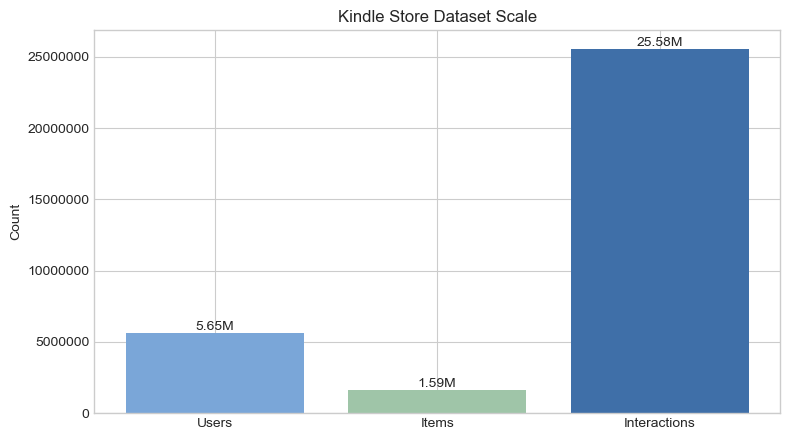

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics = ['Users', 'Items', 'Interactions']
values = [review_summary['num_users'], review_summary['num_items'], review_summary['total_interactions']]
ax.bar(metrics, values, color=['#7aa6d8', '#9fc5a8', '#3f6fa8'])
ax.set_title('Kindle Store Dataset Scale')
ax.set_ylabel('Count')
ax.ticklabel_format(style='plain', axis='y')
for i, v in enumerate(values):
    ax.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Rating distribution

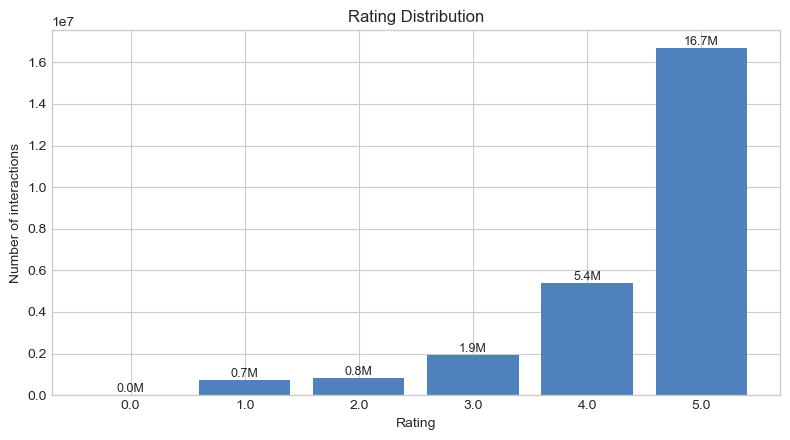

In [7]:
rating_df = pd.DataFrame(
    sorted((float(k), v) for k, v in review_summary['rating_counts'].items()),
    columns=['rating', 'count']
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rating_df['rating'].astype(str), rating_df['count'], color='#4f81bd')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of interactions')
for i, v in enumerate(rating_df['count']):
    ax.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## User and item sparsity

These plots show how many users/items remain after minimum-interaction thresholds. They support the proposed filtering strategy for sequential modelling.

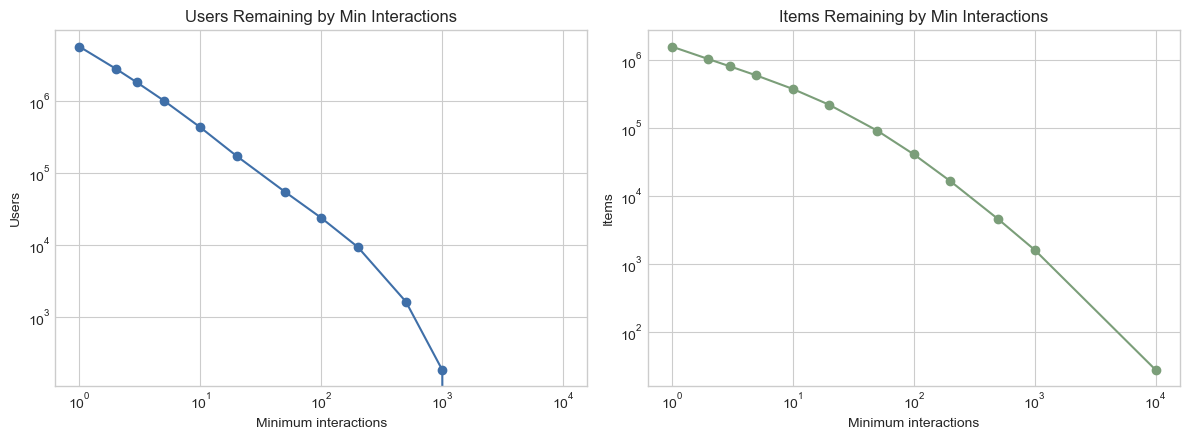

In [8]:
users_thr = pd.DataFrame({
    'threshold': [int(k) for k in review_summary['users_ge_threshold'].keys()],
    'users': list(review_summary['users_ge_threshold'].values())
}).sort_values('threshold')
items_thr = pd.DataFrame({
    'threshold': [int(k) for k in review_summary['items_ge_threshold'].keys()],
    'items': list(review_summary['items_ge_threshold'].values())
}).sort_values('threshold')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(users_thr['threshold'], users_thr['users'], marker='o', color='#3f6fa8')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Users Remaining by Min Interactions')
axes[0].set_xlabel('Minimum interactions')
axes[0].set_ylabel('Users')

axes[1].plot(items_thr['threshold'], items_thr['items'], marker='o', color='#7b9e79')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Items Remaining by Min Interactions')
axes[1].set_xlabel('Minimum interactions')
axes[1].set_ylabel('Items')
plt.tight_layout()
plt.show()

## Interactions over time

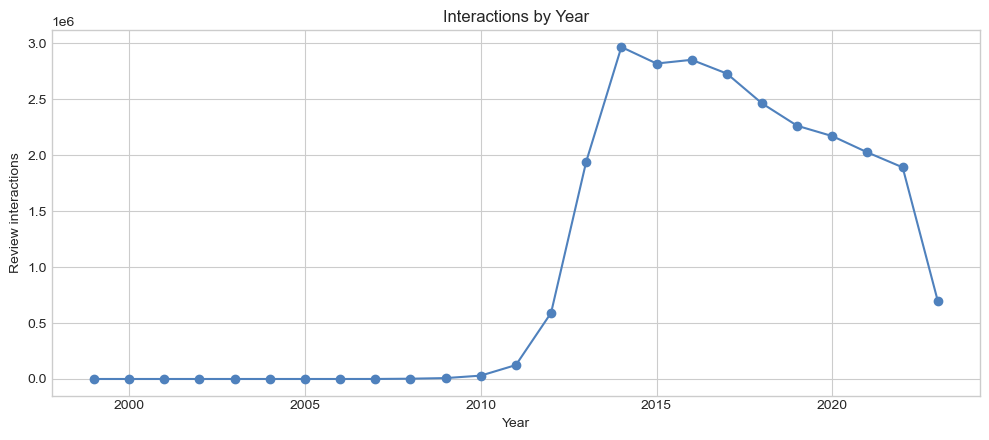

In [9]:
year_df = pd.DataFrame(
    sorted((int(k), v) for k, v in review_summary['year_counts'].items()),
    columns=['year', 'count']
)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(year_df['year'], year_df['count'], marker='o', color='#4f81bd')
ax.set_title('Interactions by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Review interactions')
plt.tight_layout()
plt.show()

## Comparison with other Amazon subsets

These values are from the project comparison statistics and motivate choosing Kindle Store.

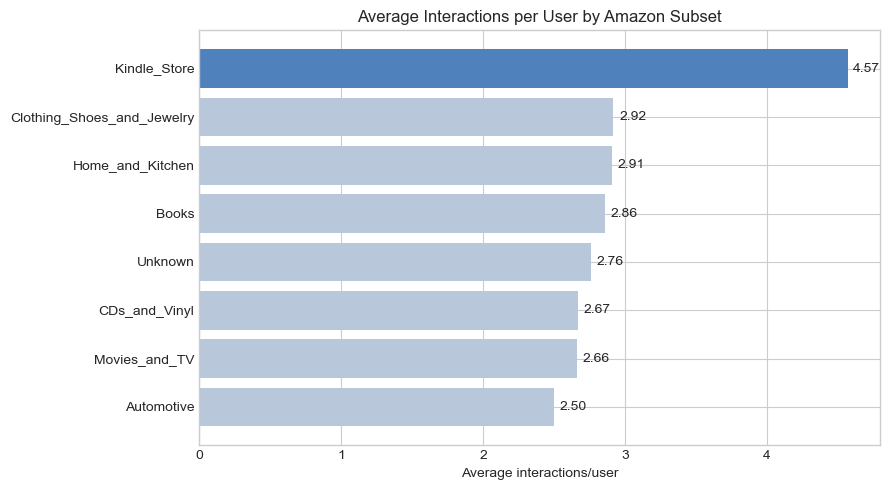

In [10]:
category_avg = pd.DataFrame({
    'category': [
        'Kindle_Store', 'Clothing_Shoes_and_Jewelry', 'Home_and_Kitchen', 'Books',
        'Unknown', 'CDs_and_Vinyl', 'Movies_and_TV', 'Automotive'
    ],
    'avg_interactions_per_user': [4.57, 2.92, 2.91, 2.86, 2.76, 2.67, 2.66, 2.50]
}).sort_values('avg_interactions_per_user')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4f81bd' if c == 'Kindle_Store' else '#b8c7d9' for c in category_avg['category']]
ax.barh(category_avg['category'], category_avg['avg_interactions_per_user'], color=colors)
ax.set_title('Average Interactions per User by Amazon Subset')
ax.set_xlabel('Average interactions/user')
for y, v in enumerate(category_avg['avg_interactions_per_user']):
    ax.text(v + 0.04, y, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

## Metadata category and missingness summary

This scan uses `meta_Kindle_Store.jsonl.gz`. It may take a few minutes on the full metadata file.

In [11]:
def scan_metadata(path=META_PATH, max_lines=MAX_META_LINES, cache_dir=CACHE_DIR):
    suffix = 'full' if max_lines is None else f'sample_{max_lines}'
    cache_path = cache_dir / f'kindle_meta_summary_cleaned_{suffix}.json'

    if cache_path.exists():
        with cache_path.open('r', encoding='utf-8') as f:
            return json.load(f)

    fields = [
        'title', 'categories', 'description', 'details', 'features',
        'author', 'average_rating', 'rating_number', 'images'
    ]
    excluded_categories = {'Kindle Store', 'Kindle eBooks'}

    missing = Counter()
    categories = Counter()
    total = 0
    bad_json = 0

    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line_no, line in enumerate(f, 1):
            if max_lines is not None and line_no > max_lines:
                break

            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue

            total += 1

            for field in fields:
                value = row.get(field)
                if value in (None, '', [], {}):
                    missing[field] += 1

            cats = row.get('categories') or []
            cats = [
                str(category)
                for category in cats
                if str(category) not in excluded_categories
            ]

            if cats:
                categories[' > '.join(cats[:3])] += 1

            if line_no % 1_000_000 == 0:
                print(f'scanned {line_no:,} metadata lines...')

    summary = {
        'total_metadata_rows': total,
        'bad_json': bad_json,
        'missing': dict(missing),
        'top_categories': dict(categories.most_common(20)),
    }

    with cache_path.open('w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)

    return summary


meta_summary = scan_metadata()
meta_summary

scanned 1,000,000 metadata lines...


{'total_metadata_rows': 1591371,
 'bad_json': 0,
 'missing': {'description': 950868,
  'author': 335876,
  'features': 32158,
  'images': 424064,
  'details': 57603},
 'top_categories': {'Literature & Fiction': 498481,
  'Romance': 135539,
  'Religion & Spirituality': 123568,
  'Science Fiction & Fantasy': 106598,
  "Children's eBooks": 102704,
  'Mystery, Thriller & Suspense': 75220,
  'Business & Money': 67277,
  'History': 52728,
  'Teen & Young Adult': 49603,
  'Biographies & Memoirs': 45885,
  'Health, Fitness & Dieting': 33550,
  'Politics & Social Sciences': 28877,
  'Comics, Manga & Graphic Novels': 26304,
  'Cookbooks, Food & Wine': 25236,
  'Arts & Photography': 23606,
  'Education & Teaching': 22073,
  'Sports & Outdoors': 19526,
  'Humor & Entertainment': 18390,
  'Computers & Technology': 15901,
  'Science & Math': 14758}}

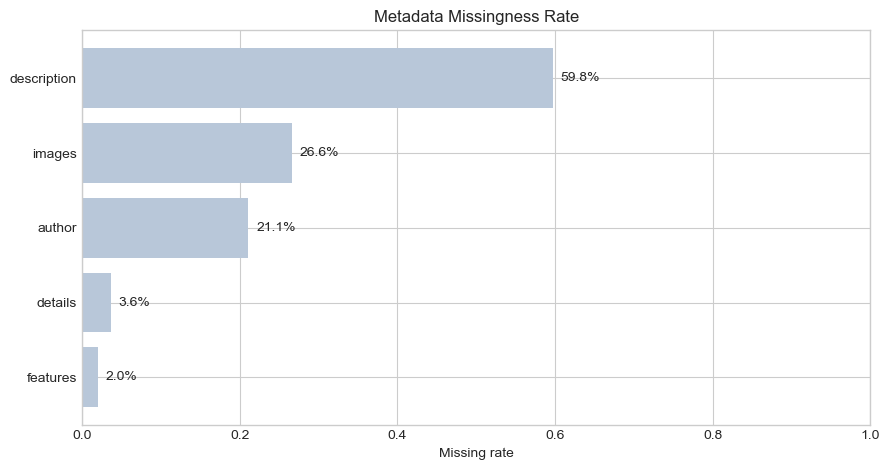

In [12]:
missing_df = pd.DataFrame({
    'field': list(meta_summary['missing'].keys()),
    'missing_count': list(meta_summary['missing'].values())
})
missing_df['missing_rate'] = missing_df['missing_count'] / meta_summary['total_metadata_rows']
missing_df = missing_df.sort_values('missing_rate')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(missing_df['field'], missing_df['missing_rate'], color='#b8c7d9')
ax.set_title('Metadata Missingness Rate')
ax.set_xlabel('Missing rate')
ax.set_xlim(0, 1)
for y, v in enumerate(missing_df['missing_rate']):
    ax.text(v + 0.01, y, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

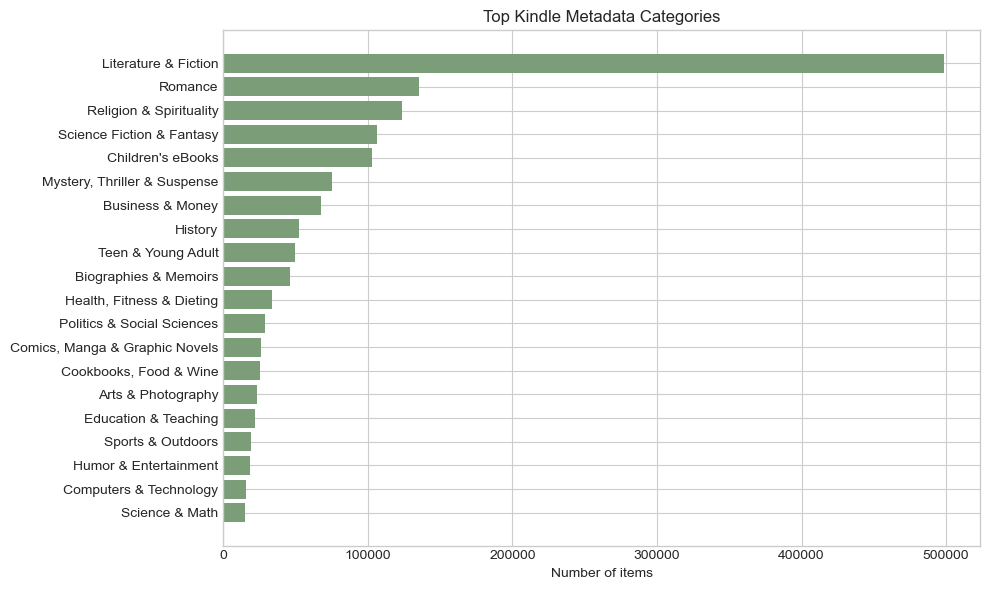

In [13]:
top_cat_df = pd.DataFrame(
    list(meta_summary['top_categories'].items()),
    columns=['category_path', 'count']
).sort_values('count')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_cat_df['category_path'], top_cat_df['count'], color='#7b9e79')
ax.set_title('Top Kindle Metadata Categories')
ax.set_xlabel('Number of items')
plt.tight_layout()
plt.show()

## Suggested figures for the report

Recommended figures to include in the final report:

1. Average interactions/user comparison across Amazon subsets.
2. Rating distribution for Kindle Store.
3. Users/items remaining after minimum-interaction thresholds.
4. Metadata missingness or top categories, if discussing content-based recommendation.

## 1.2 Preprocessing pipeline

The preprocessing implementation is retained as a staged pipeline: metadata cleaning, review deduplication, positive-interaction filtering, iterative 5-core filtering, user-level sampling, chronological splitting, ID mapping and fixed negative generation.

The filtering rules applied during this pipeline are as follows. Each rule is motivated by a concrete data or modelling constraint, and its intended effect is noted below.

1. **Temporal window (2014–2022 inclusive).**  
   Early years contribute very few reviews and later years may be incomplete in the dump. Restricting to this window keeps the chronological split inside a coherent, densely observed period and reduces noise from sparse historical tails.

2. **Record validity and deduplication.**  
   Rows missing a user identifier, item identifier (`parent_asin`), rating or timestamp cannot support ranking or sequence modelling, so they are discarded. When the same user–item pair appears more than once, only the latest interaction is kept. This removes contradictory timestamps and prevents the same pair from leaking across train, validation and test.

3. **Positive-interaction threshold (rating ≥ 4.0).**  
   Low ratings are closer to explicit negatives than to preference evidence. Keeping only ratings of four or above converts the data into implicit positive feedback, which matches the ranking objective used by all later models and avoids treating disliked books as successful recommendations.

4. **Metadata alignment.**  
   Content-based models need titles, categories and related textual fields. Interactions whose items are absent from the cleaned metadata table are deleted so that every retained item has usable text features. Without this step, content scoring would be undefined or biased toward items that happen to have metadata.

5. **Iterative 5-core filtering.**  
   Users with fewer than five positive items and items with fewer than five positive users are removed repeatedly until the bipartite graph stabilises. Extremely sparse users and items provide unreliable sequence contexts and weak collaborative signal; the 5-core pass concentrates the matrix on denser local structure while still preserving a large long-tail catalogue.

6. **User-level stratified sampling (target ≈ 1M interactions).**  
   Full 5-core data remain large for repeated neural training. Complete user sequences are therefore sampled by activity stratum toward about one million interactions, so that short-, medium- and heavy-reader groups are all represented. A further 5-core pass then removes any users or items that become too sparse after sampling, restoring the density guarantee without breaking sequence integrity.

7. **Chronological leave-one-out split.**  
   Each user's positives are sorted by time. The last interaction is held out for testing, the second-last for validation, and the remainder form the training history. This respects real reading order and avoids future information leaking into training. Users are dropped if their validation or test item never appears in the global training item set, so evaluation never asks a model to rank an item it could not have observed.

8. **Fixed negative sampling (100 negatives per held-out positive).**  
   Negatives are drawn from items outside each user's full positive history and are shared across all models. Fixed candidate lists make ranking metrics directly comparable, control evaluation cost, and prevent any model from gaining an unfair advantage through a different negative pool.

In [14]:

from __future__ import annotations

import csv
import html
import json
import math
import random
import re
import sqlite3
import statistics
import time
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

CONFIG = {
    # Input and output
    "reviews_path": str(PROJECT_ROOT.parent / "proj1" / "Kindle_Store.jsonl"),
    "metadata_path": str(PROJECT_ROOT.parent / "proj1" / "meta_Kindle_Store.jsonl"),
    "output_dir": str(DATA_ROOT),
    "work_db_name": "preprocess_work.sqlite",

    # Time range, positive interactions, and deduplication
    "year_start": 2014,
    "year_end": 2022,
    "positive_threshold": 4.0,
    "deduplication": "keep_latest_user_item_interaction",
    "require_metadata_match": True,

    # Iterative 5-core filtering
    "min_user_positives": 5,
    "min_item_positives": 5,
    "filter_method": "iterative_5_core",

    # User-level sampling for approximately one million interactions
    "sample_strategy": "user_activity_stratified",
    "target_interactions": 1_000_000,
    "sample_overshoot_ratio": 1.62,

    # Chronological split
    "split": "chronological_leave_one_out",
    "ensure_eval_items_in_train": True,

    # Negative sampling
    "default_num_negatives": 1,
    "negative_exclusion": "all_user_positive_items",
    "negative_unique_per_positive": True,
    "eval_num_negatives": 100,

    # Metadata cleaning
    "missing_verified_purchase": False,
    "remove_categories": ["Kindle Store", "Kindle eBooks"],
    "split_inner_category": True,
    "write_sequence_side_fields": True,

    # Reproducibility and runtime control
    "random_seed": 42,
    "progress_every": 200_000,
    "sqlite_commit_every": 50_000,
    "overwrite": True,
}

# Match the integrated notebook's default: reuse complete prepared data.
# Set this to True when the raw JSONL files should be processed again.
RUN_FULL_PREPROCESSING = globals().get('RUN_FULL_PREPROCESSING', False)

REVIEWS_PATH = Path(CONFIG["reviews_path"])
METADATA_PATH = Path(CONFIG["metadata_path"])
OUTPUT_DIR = Path(CONFIG["output_dir"])
WORK_DB_PATH = OUTPUT_DIR / "_work" / CONFIG["work_db_name"]

print("Review data path:", REVIEWS_PATH.resolve())
print("Metadata path:", METADATA_PATH.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Review data path: D:\unsw\COMP9727\proj1\Kindle_Store.jsonl
Metadata path: D:\unsw\COMP9727\proj1\meta_Kindle_Store.jsonl
Output directory: D:\unsw\COMP9727\proj2\processed_kindle


# Utility Functions

These helper functions handle small tasks used across the pipeline.
They normalize timestamps and text, clean metadata fields, read JSONL safely, and manage the temporary SQLite database.

In [15]:

SMART_QUOTES = str.maketrans({
    "\u2018": "'", "\u2019": "'", "\u201A": "'",
    "\u201C": '"', "\u201D": '"', "\u201E": '"',
    "\u00A0": " ",
})

MARKETING_PHRASES = {
    "BUY NOW", "BESTSELLER", "BEST SELLER", "LIMITED TIME",
    "DESCRIPTION", "TOPICS INCLUDE", "CLICK HERE", "ORDER NOW",
}

def progress(message: str, done: bool = False) -> None:
    end = "\n" if done else "\r"
    print(message.ljust(100), end=end, flush=True)

# Convert valid timestamps to milliseconds.
def normalize_timestamp_ms(value: Any) -> int | None:
    if value is None or value == "":
        return None
    try:
        ts = int(float(value))
    except (TypeError, ValueError, OverflowError):
        return None

    # Support timestamps in seconds and milliseconds
    if ts < 10_000_000_000:
        ts *= 1000

    try:
        datetime.fromtimestamp(ts / 1000, tz=timezone.utc)
    except (ValueError, OSError, OverflowError):
        return None
    return ts

def timestamp_year(ts_ms: int) -> int:
    return datetime.fromtimestamp(ts_ms / 1000, tz=timezone.utc).year

def strip_html(text: str) -> str:
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    return text

# Normalize text fields into a clean single-line string.
def normalize_text(text: Any) -> str:
    if text is None:
        return ""
    if isinstance(text, list):
        text = " ".join(str(x) for x in text if x is not None)
    elif isinstance(text, dict):
        text = json.dumps(text, ensure_ascii=False)

    text = str(text).translate(SMART_QUOTES)
    text = strip_html(text)
    text = re.sub(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_title(value: Any) -> str:
    return normalize_text(value)

# Clean and join category labels.
def clean_categories(value: Any) -> str:
    if value is None:
        return ""

    if not isinstance(value, list):
        value = [value]

    remove_set = {x.casefold() for x in CONFIG["remove_categories"]}
    cleaned_parts: list[str] = []

    for raw in value:
        part = normalize_text(raw)
        if not part or part.casefold() in remove_set:
            continue

        if CONFIG["split_inner_category"]:
            # Convert commas and ampersands to semicolons
            subparts = re.split(r"\s*(?:,|&)\s*", part)
            cleaned_parts.extend(x for x in subparts if x)
        else:
            cleaned_parts.append(part)

    # Remove duplicates while preserving order
    seen = set()
    result = []
    for part in cleaned_parts:
        key = part.casefold()
        if key not in seen:
            seen.add(key)
            result.append(part)
    return ";".join(result)

def remove_marketing_noise(text: str) -> str:
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\*{2,}", " ", text)
    text = re.sub(r"★+", " ", text)

    for phrase in MARKETING_PHRASES:
        text = re.sub(
            rf"(?<!\w){re.escape(phrase)}(?!\w)\s*:?",
            " ",
            text,
            flags=re.IGNORECASE,
        )

    # Separate a period from a following uppercase letter
    text = re.sub(r"(?<=[a-z0-9])\.(?=[A-Z])", ". ", text)
    return re.sub(r"\s+", " ", text).strip()

def clean_features(value: Any) -> str:
    return remove_marketing_noise(normalize_text(value))

def clean_description(value: Any) -> str:
    return normalize_text(value)

def extract_author_name(author: Any) -> str:
    if isinstance(author, dict):
        return normalize_text(author.get("name", ""))
    return normalize_text(author)

def to_bool_int(value: Any) -> int:
    if value is None:
        return int(bool(CONFIG["missing_verified_purchase"]))
    if isinstance(value, bool):
        return int(value)
    if isinstance(value, (int, float)):
        return int(bool(value))
    return int(str(value).strip().lower() in {"1", "true", "yes", "y"})

# Read JSONL records without stopping on malformed lines.
def iter_jsonl(path: Path) -> Iterable[tuple[int, dict[str, Any]]]:
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                yield line_no, {}
                continue
            yield line_no, obj

# Create the temporary SQLite database used by the pipeline.
def connect_db() -> sqlite3.Connection:
    WORK_DB_PATH.parent.mkdir(parents=True, exist_ok=True)

    if CONFIG["overwrite"] and WORK_DB_PATH.exists():
        WORK_DB_PATH.unlink()

    conn = sqlite3.connect(WORK_DB_PATH)
    conn.execute("PRAGMA journal_mode=WAL;")
    conn.execute("PRAGMA synchronous=NORMAL;")
    conn.execute("PRAGMA temp_store=FILE;")
    conn.execute("PRAGMA cache_size=-200000;")  # Approximately 200 MB
    return conn

def create_tables(conn: sqlite3.Connection) -> None:
    conn.executescript("""
    CREATE TABLE IF NOT EXISTS metadata (
        item_id TEXT PRIMARY KEY,
        title TEXT NOT NULL,
        categories TEXT NOT NULL,
        features TEXT NOT NULL,
        description TEXT NOT NULL,
        author TEXT NOT NULL,
        average_rating REAL,
        rating_number INTEGER,
        completeness_score INTEGER NOT NULL
    );

    CREATE TABLE IF NOT EXISTS interactions (
        user_id TEXT NOT NULL,
        item_id TEXT NOT NULL,
        rating REAL NOT NULL,
        timestamp INTEGER NOT NULL,
        verified_purchase INTEGER NOT NULL,
        PRIMARY KEY (user_id, item_id)
    );

    CREATE INDEX IF NOT EXISTS idx_interactions_user
        ON interactions(user_id);

    CREATE INDEX IF NOT EXISTS idx_interactions_item
        ON interactions(item_id);

    CREATE INDEX IF NOT EXISTS idx_interactions_user_time
        ON interactions(user_id, timestamp, item_id);
    """)
    conn.commit()

def count_rows(conn: sqlite3.Connection, table: str) -> int:
    return int(conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0])


# Metadata Processing

This section reads the item metadata file and cleans the fields used by the models.
It removes text and category noise, handles missing values, and keeps the most complete record for each item.
The cleaned records are stored in SQLite for efficient matching and export.

In [16]:

# Clean metadata and keep the most complete row for each item.
def ingest_metadata(conn: sqlite3.Connection, stats: dict[str, Any]) -> None:
    if not METADATA_PATH.exists():
        raise FileNotFoundError(f"Metadata file not found: {METADATA_PATH.resolve()}")

    sql = """
    INSERT INTO metadata (
        item_id, title, categories, features, description,
        author, average_rating, rating_number, completeness_score
    )
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ON CONFLICT(item_id) DO UPDATE SET
        title = excluded.title,
        categories = excluded.categories,
        features = excluded.features,
        description = excluded.description,
        author = excluded.author,
        average_rating = excluded.average_rating,
        rating_number = excluded.rating_number,
        completeness_score = excluded.completeness_score
    WHERE excluded.completeness_score > metadata.completeness_score
    """

    read_lines = 0
    invalid_lines = 0
    accepted_rows = 0
    # Buffer rows to reduce database write overhead.
    batch = []

    for line_no, obj in iter_jsonl(METADATA_PATH):
        read_lines += 1
        if not obj:
            invalid_lines += 1
            continue

        item_id = normalize_text(obj.get("parent_asin"))
        if not item_id:
            invalid_lines += 1
            continue

        title = clean_title(obj.get("title"))
        categories = clean_categories(obj.get("categories"))
        features = clean_features(obj.get("features"))
        description = clean_description(obj.get("description"))
        author = extract_author_name(obj.get("author"))

        try:
            average_rating = (
                float(obj["average_rating"])
                if obj.get("average_rating") not in (None, "")
                else None
            )
        except (TypeError, ValueError):
            average_rating = None

        try:
            rating_number = (
                int(obj["rating_number"])
                if obj.get("rating_number") not in (None, "")
                else None
            )
        except (TypeError, ValueError):
            rating_number = None

        completeness_score = sum(
            bool(x) for x in [title, categories, features, description, author]
        )
        completeness_score += int(average_rating is not None)
        completeness_score += int(rating_number is not None)

        batch.append((
            item_id, title, categories, features, description,
            author, average_rating, rating_number, completeness_score
        ))
        accepted_rows += 1

        if len(batch) >= CONFIG["sqlite_commit_every"]:
            conn.executemany(sql, batch)
            conn.commit()
            batch.clear()

        if read_lines % CONFIG["progress_every"] == 0:
            progress(f"Metadata lines read: {read_lines:,}")

    if batch:
        conn.executemany(sql, batch)
        conn.commit()

    progress(f"Metadata reading completed: {read_lines:,} lines", done=True)

    stats["metadata_lines_read"] = read_lines
    stats["metadata_invalid_lines"] = invalid_lines
    stats["metadata_rows_accepted_before_dedup"] = accepted_rows
    stats["metadata_unique_items"] = count_rows(conn, "metadata")


# Review Processing

This section loads review records from the selected years.
Invalid rows are skipped, timestamps and ratings are normalized, and missing purchase flags are handled.
If a user reviews the same item more than once, only the latest interaction is kept.

In [17]:

# Load valid reviews and keep the latest record per user-item pair.
def ingest_reviews(conn: sqlite3.Connection, stats: dict[str, Any]) -> None:
    if not REVIEWS_PATH.exists():
        raise FileNotFoundError(f"Review file not found: {REVIEWS_PATH.resolve()}")

    sql = """
    INSERT INTO interactions (
        user_id, item_id, rating, timestamp, verified_purchase
    )
    VALUES (?, ?, ?, ?, ?)
    ON CONFLICT(user_id, item_id) DO UPDATE SET
        rating = excluded.rating,
        timestamp = excluded.timestamp,
        verified_purchase = excluded.verified_purchase
    WHERE excluded.timestamp >= interactions.timestamp
    """

    read_lines = 0
    invalid_lines = 0
    outside_year_range = 0
    accepted_rows = 0
    batch = []

    for line_no, obj in iter_jsonl(REVIEWS_PATH):
        read_lines += 1
        if not obj:
            invalid_lines += 1
            continue

        user_id = normalize_text(obj.get("user_id"))
        item_id = normalize_text(obj.get("parent_asin"))
        ts = normalize_timestamp_ms(obj.get("timestamp"))

        try:
            rating = float(obj.get("rating"))
        except (TypeError, ValueError):
            rating = None

        if not user_id or not item_id or ts is None or rating is None:
            invalid_lines += 1
            continue

        year = timestamp_year(ts)
        if not (CONFIG["year_start"] <= year <= CONFIG["year_end"]):
            outside_year_range += 1
            continue

        verified = to_bool_int(obj.get("verified_purchase"))
        batch.append((user_id, item_id, rating, ts, verified))
        accepted_rows += 1

        if len(batch) >= CONFIG["sqlite_commit_every"]:
            conn.executemany(sql, batch)
            conn.commit()
            batch.clear()

        if read_lines % CONFIG["progress_every"] == 0:
            progress(f"Review lines read: {read_lines:,}")

    if batch:
        conn.executemany(sql, batch)
        conn.commit()

    progress(f"Review reading completed: {read_lines:,} lines", done=True)

    stats["review_lines_read"] = read_lines
    stats["review_invalid_lines"] = invalid_lines
    stats["review_lines_outside_year_range"] = outside_year_range
    stats["review_rows_accepted_before_dedup"] = accepted_rows
    stats["unique_user_item_pairs_after_latest_dedup"] = count_rows(conn, "interactions")


# Positive Filtering and 5-Core

This section keeps ratings of four or above and removes interactions without matching metadata.
It then applies iterative 5-core filtering.
Users with fewer than five positive items and items with fewer than five users are removed until the dataset becomes stable.

In [18]:

# Keep positive interactions linked to known items.
def apply_positive_and_metadata_filters(
    conn: sqlite3.Connection,
    stats: dict[str, Any],
) -> None:
    before = count_rows(conn, "interactions")

    conn.execute(
        "DELETE FROM interactions WHERE rating < ?",
        (CONFIG["positive_threshold"],),
    )
    conn.commit()
    after_positive = count_rows(conn, "interactions")

    if CONFIG["require_metadata_match"]:
        conn.execute("""
        DELETE FROM interactions
        WHERE NOT EXISTS (
            SELECT 1
            FROM metadata
            WHERE metadata.item_id = interactions.item_id
        )
        """)
        conn.commit()

    after_metadata = count_rows(conn, "interactions")

    stats["interactions_before_positive_filter"] = before
    stats["positive_interactions_after_rating_filter"] = after_positive
    stats["positive_interactions_after_metadata_match"] = after_metadata

# Repeat user and item filtering until the k-core is stable.
def iterative_k_core(
    conn: sqlite3.Connection,
    min_user: int,
    min_item: int,
    stage_name: str,
    stats: dict[str, Any],
) -> None:
    rounds = 0
    # Store each round for the final preprocessing report.
    history = []

    while True:
        rounds += 1
        before = count_rows(conn, "interactions")

        conn.execute("""
        DELETE FROM interactions
        WHERE user_id IN (
            SELECT user_id
            FROM interactions
            GROUP BY user_id
            HAVING COUNT(*) < ?
        )
        """, (min_user,))
        conn.commit()

        after_user = count_rows(conn, "interactions")

        conn.execute("""
        DELETE FROM interactions
        WHERE item_id IN (
            SELECT item_id
            FROM interactions
            GROUP BY item_id
            HAVING COUNT(*) < ?
        )
        """, (min_item,))
        conn.commit()

        after_item = count_rows(conn, "interactions")
        history.append({
            "round": rounds,
            "before": before,
            "after_user_filter": after_user,
            "after_item_filter": after_item,
        })

        print(
            f"{stage_name} round {rounds}: "
            f"{before:,} -> {after_user:,} -> {after_item:,}"
        )

        if after_item == before:
            break
        if after_item == 0:
            raise RuntimeError(
                f"No data remains after {stage_name}. Check the year range, positive threshold, or 5-core thresholds."
            )

    stats[f"{stage_name}_rounds"] = rounds
    stats[f"{stage_name}_history"] = history
    stats[f"{stage_name}_final_interactions"] = count_rows(conn, "interactions")
    stats[f"{stage_name}_final_users"] = int(
        conn.execute("SELECT COUNT(DISTINCT user_id) FROM interactions").fetchone()[0]
    )
    stats[f"{stage_name}_final_items"] = int(
        conn.execute("SELECT COUNT(DISTINCT item_id) FROM interactions").fetchone()[0]
    )


# User-Level Sampling

This section reduces the dataset toward the target size without breaking user histories.
Users are grouped by activity level and sampled as complete sequences.
A later 5-core pass removes sparse users or items created by sampling.

In [19]:

def activity_bin(n: int) -> int:
    return int(math.log2(max(n, 1)))

# Sample whole users while preserving different activity levels.
def sample_users_if_needed(
    conn: sqlite3.Connection,
    stats: dict[str, Any],
) -> None:
    target = int(CONFIG["target_interactions"])
    overshoot_target = int(target * float(CONFIG["sample_overshoot_ratio"]))
    total = count_rows(conn, "interactions")

    stats["interactions_before_user_sampling"] = total
    stats["sampling_target_interactions"] = target
    stats["sampling_overshoot_target"] = overshoot_target

    if total <= target:
        print(f"Only {total:,} interactions are available. Sampling is skipped.")
        stats["sampling_applied"] = False
        return

    rows = conn.execute("""
        SELECT user_id, COUNT(*) AS n
        FROM interactions
        GROUP BY user_id
    """).fetchall()

    rng = random.Random(CONFIG["random_seed"])
    # Group users by log-scaled interaction counts.
    buckets: dict[int, list[tuple[str, int]]] = defaultdict(list)

    for user_id, n in rows:
        buckets[activity_bin(int(n))].append((user_id, int(n)))

    bucket_totals = {
        key: sum(n for _, n in users)
        for key, users in buckets.items()
    }

    selected: set[str] = set()
    remaining: list[tuple[str, int]] = []
    selected_interactions = 0

    # Allocate interaction quotas proportionally across activity groups
    for key in sorted(buckets):
        users = buckets[key]
        rng.shuffle(users)
        quota = overshoot_target * bucket_totals[key] / total
        bucket_selected = 0

        for user_id, n in users:
            new_value = bucket_selected + n
            if new_value <= quota or abs(new_value - quota) < abs(bucket_selected - quota):
                selected.add(user_id)
                selected_interactions += n
                bucket_selected = new_value
            else:
                remaining.append((user_id, n))

    # Use remaining users to move closer to the target
    rng.shuffle(remaining)
    for user_id, n in remaining:
        if selected_interactions >= overshoot_target:
            break
        if abs((selected_interactions + n) - overshoot_target) <= abs(
            selected_interactions - overshoot_target
        ):
            selected.add(user_id)
            selected_interactions += n

    conn.execute("DROP TABLE IF EXISTS selected_users")
    conn.execute("CREATE TEMP TABLE selected_users (user_id TEXT PRIMARY KEY)")
    conn.executemany(
        "INSERT INTO selected_users(user_id) VALUES (?)",
        ((u,) for u in selected),
    )
    conn.commit()

    conn.execute("""
        DELETE FROM interactions
        WHERE user_id NOT IN (SELECT user_id FROM selected_users)
    """)
    conn.commit()

    after = count_rows(conn, "interactions")
    stats["sampling_applied"] = True
    stats["sampled_users_before_second_core"] = len(selected)
    stats["sampled_interactions_before_second_core"] = after

    print(
        f"User-level stratified sampling completed: {total:,} -> {after:,} interactions, "
        f"{len(selected):,} users retained."
    )


# Chronological Data Split

This section sorts each user's positive interactions by time.
The last interaction is used for testing, the second last for validation, and earlier interactions for training.
Users are removed if their validation or test item never appears in the training item set.

In [20]:

Interaction = tuple[str, int, float, int]
UserSequence = dict[str, Any]

# Build chronological interaction sequences for each user.
def load_user_sequences(
    conn: sqlite3.Connection,
    stats: dict[str, Any],
) -> list[UserSequence]:
    cursor = conn.execute("""
        SELECT user_id, item_id, timestamp, rating, verified_purchase
        FROM interactions
        ORDER BY user_id, timestamp, item_id
    """)

    sequences: list[UserSequence] = []
    current_user: str | None = None
    current_interactions: list[Interaction] = []

    # Save the current user after all of their rows are read.
    def flush() -> None:
        nonlocal current_user, current_interactions
        if current_user is None:
            return
        if len(current_interactions) >= CONFIG["min_user_positives"]:
            sequences.append({
                "user_id": current_user,
                "interactions": current_interactions,
            })
        current_user = None
        current_interactions = []

    for user_id, item_id, ts, rating, verified in cursor:
        if current_user is None:
            current_user = user_id
        elif user_id != current_user:
            flush()
            current_user = user_id

        current_interactions.append((
            item_id,
            int(ts),
            float(rating),
            int(verified),
        ))

    flush()

    stats["users_loaded_for_split"] = len(sequences)
    stats["interactions_loaded_for_split"] = sum(
        len(x["interactions"]) for x in sequences
    )
    return sequences

# Remove users whose validation or test item is unseen in training.
def ensure_eval_items_seen_in_train(
    sequences: list[UserSequence],
    stats: dict[str, Any],
) -> list[UserSequence]:
    if not CONFIG["ensure_eval_items_in_train"]:
        stats["eval_train_coverage_filter_applied"] = False
        return sequences

    stats["eval_train_coverage_filter_applied"] = True
    rounds = 0
    removed_total = 0
    current = sequences

    while True:
        rounds += 1
        train_items = {
            item_id
            for user in current
            for item_id, _, _, _ in user["interactions"][:-2]
        }

        kept = []
        removed = 0

        for user in current:
            interactions = user["interactions"]
            val_item = interactions[-2][0]
            test_item = interactions[-1][0]

            if val_item in train_items and test_item in train_items:
                kept.append(user)
            else:
                removed += 1

        removed_total += removed
        print(
            f"Training-item coverage check round {rounds}: "
            f"{len(kept):,} users retained and {removed:,} users removed."
        )

        current = kept
        if removed == 0:
            break
        if not current:
            raise RuntimeError("No users remain after the training-item coverage check.")

    stats["eval_train_coverage_rounds"] = rounds
    stats["users_removed_for_unseen_eval_items"] = removed_total
    stats["users_after_eval_train_coverage"] = len(current)
    return current


# Output File Generation

This section creates consistent integer mappings for all final users and items.
It writes cleaned interactions, sequences, training triplets, validation and test files, metadata, and optional negative candidates.
Negative items are sampled outside each user's full positive history, and summary statistics are recorded.

In [21]:

def write_json(path: Path, obj: Any) -> None:
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

# Draw items that the user has not interacted with.
def sample_negative_items(
    catalog_size: int,
    positive_items: set[int],
    k: int,
    rng: random.Random,
) -> list[int]:
    available_count = catalog_size - len(positive_items)
    if available_count <= 0 or k <= 0:
        return []

    if CONFIG["negative_unique_per_positive"]:
        k = min(k, available_count)

    result: list[int] = []
    used: set[int] = set()
    # Limit random retries for users with many positive items.
    max_attempts = max(100, k * 30)

    attempts = 0
    while len(result) < k and attempts < max_attempts:
        candidate = rng.randrange(catalog_size)
        attempts += 1

        if candidate in positive_items:
            continue
        if CONFIG["negative_unique_per_positive"] and candidate in used:
            continue

        result.append(candidate)
        used.add(candidate)

    if len(result) < k:
        # Fallback for extremely dense users
        remaining = [
            i for i in range(catalog_size)
            if i not in positive_items and i not in used
        ]
        rng.shuffle(remaining)
        result.extend(remaining[: k - len(result)])

    return result

# Assign stable integer indices to users and items.
def build_mappings(
    sequences: list[UserSequence],
) -> tuple[dict[str, int], dict[str, int]]:
    user_ids = sorted(user["user_id"] for user in sequences)
    item_ids = sorted({
        item_id
        for user in sequences
        for item_id, _, _, _ in user["interactions"]
    })

    user2idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
    item2idx = {item_id: idx for idx, item_id in enumerate(item_ids)}
    return user2idx, item2idx

# Write splits, sequences, mappings, and training triplets.
def write_core_outputs(
    conn: sqlite3.Connection,
    sequences: list[UserSequence],
    user2idx: dict[str, int],
    item2idx: dict[str, int],
    stats: dict[str, Any],
) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    idx2user = {str(idx): user_id for user_id, idx in user2idx.items()}
    idx2item = {str(idx): item_id for item_id, idx in item2idx.items()}

    write_json(OUTPUT_DIR / "user2idx.json", user2idx)
    write_json(OUTPUT_DIR / "item2idx.json", item2idx)
    write_json(OUTPUT_DIR / "idx2user.json", idx2user)
    write_json(OUTPUT_DIR / "idx2item.json", idx2item)

    interactions_path = OUTPUT_DIR / "interactions_clean.csv"
    sequence_path = OUTPUT_DIR / "train_sequences.csv"
    triplet_path = OUTPUT_DIR / "train_triplets.csv"
    val_path = OUTPUT_DIR / "val.csv"
    test_path = OUTPUT_DIR / "test.csv"

    rng = random.Random(CONFIG["random_seed"])
    catalog_size = len(item2idx)

    train_interaction_count = 0
    triplet_count = 0

    with (
        interactions_path.open("w", newline="", encoding="utf-8") as f_interactions,
        sequence_path.open("w", newline="", encoding="utf-8") as f_sequences,
        triplet_path.open("w", newline="", encoding="utf-8") as f_triplets,
        val_path.open("w", newline="", encoding="utf-8") as f_val,
        test_path.open("w", newline="", encoding="utf-8") as f_test,
    ):
        interactions_writer = csv.writer(f_interactions)
        sequences_writer = csv.writer(f_sequences)
        triplets_writer = csv.writer(f_triplets)
        val_writer = csv.writer(f_val)
        test_writer = csv.writer(f_test)

        interactions_writer.writerow([
            "user_idx", "item_idx", "user_id", "parent_asin",
            "rating", "timestamp", "verified_purchase", "split",
        ])

        if CONFIG["write_sequence_side_fields"]:
            sequences_writer.writerow([
                "user_idx", "item_seq", "timestamp_seq",
                "rating_seq", "verified_seq",
            ])
        else:
            sequences_writer.writerow(["user_idx", "item_seq"])

        triplets_writer.writerow([
            "user_idx", "pos_idx", "neg_idx",
            "pos_timestamp", "pos_rating", "pos_verified_purchase",
        ])
        val_writer.writerow(["user_idx", "pos_idx"])
        test_writer.writerow(["user_idx", "pos_idx"])

        for user in sequences:
            user_id = user["user_id"]
            user_idx = user2idx[user_id]
            interactions: list[Interaction] = user["interactions"]

            # Reserve the last two interactions for validation and testing.
            train = interactions[:-2]
            val = interactions[-2]
            test = interactions[-1]

            all_positive_indices = {
                item2idx[item_id]
                for item_id, _, _, _ in interactions
            }

            train_item_indices = [
                item2idx[item_id]
                for item_id, _, _, _ in train
            ]
            train_timestamps = [str(ts) for _, ts, _, _ in train]
            train_ratings = [str(rating) for _, _, rating, _ in train]
            train_verified = [str(verified) for _, _, _, verified in train]

            if CONFIG["write_sequence_side_fields"]:
                sequences_writer.writerow([
                    user_idx,
                    " ".join(map(str, train_item_indices)),
                    " ".join(train_timestamps),
                    " ".join(train_ratings),
                    " ".join(train_verified),
                ])
            else:
                sequences_writer.writerow([
                    user_idx,
                    " ".join(map(str, train_item_indices)),
                ])

            val_writer.writerow([user_idx, item2idx[val[0]]])
            test_writer.writerow([user_idx, item2idx[test[0]]])

            for split_name, split_rows in (
                ("train", train),
                ("validation", [val]),
                ("test", [test]),
            ):
                for item_id, ts, rating, verified in split_rows:
                    interactions_writer.writerow([
                        user_idx,
                        item2idx[item_id],
                        user_id,
                        item_id,
                        rating,
                        ts,
                        bool(verified),
                        split_name,
                    ])

            for item_id, ts, rating, verified in train:
                pos_idx = item2idx[item_id]
                negatives = sample_negative_items(
                    catalog_size=catalog_size,
                    positive_items=all_positive_indices,
                    k=int(CONFIG["default_num_negatives"]),
                    rng=rng,
                )

                for neg_idx in negatives:
                    triplets_writer.writerow([
                        user_idx,
                        pos_idx,
                        neg_idx,
                        ts,
                        rating,
                        bool(verified),
                    ])
                    triplet_count += 1

                train_interaction_count += 1

    stats["num_users"] = len(user2idx)
    stats["num_items"] = len(item2idx)
    stats["num_interactions"] = sum(
        len(user["interactions"]) for user in sequences
    )
    stats["num_train_interactions"] = train_interaction_count
    stats["num_validation_interactions"] = len(sequences)
    stats["num_test_interactions"] = len(sequences)
    stats["num_train_triplets"] = triplet_count

# Export metadata only for items in the final dataset.
def write_metadata_outputs(
    conn: sqlite3.Connection,
    item2idx: dict[str, int],
    stats: dict[str, Any],
) -> None:
    clean_path = OUTPUT_DIR / "items_metadata_clean.csv"
    optional_path = OUTPUT_DIR / "item_metadata.csv"

    final_items = set(item2idx)

    metadata_rows = {}
    for row in conn.execute("""
        SELECT
            item_id, title, categories, features, description,
            author, average_rating, rating_number
        FROM metadata
    """):
        if row[0] in final_items:
            metadata_rows[row[0]] = row[1:]

    with (
        clean_path.open("w", newline="", encoding="utf-8") as f_clean,
        optional_path.open("w", newline="", encoding="utf-8") as f_optional,
    ):
        clean_writer = csv.writer(f_clean)
        optional_writer = csv.writer(f_optional)

        clean_writer.writerow([
            "item_idx", "parent_asin", "title",
            "categories", "features", "description",
        ])
        optional_writer.writerow([
            "item_idx", "title", "categories", "author",
            "average_rating", "rating_number",
        ])

        for item_id, item_idx in sorted(
            item2idx.items(),
            key=lambda x: x[1],
        ):
            title, categories, features, description, author, avg, n = (
                metadata_rows.get(item_id, ("", "", "", "", "", None, None))
            )

            clean_writer.writerow([
                item_idx, item_id, title,
                categories, features, description,
            ])
            optional_writer.writerow([
                item_idx, title, categories, author, avg, n,
            ])

    stats["metadata_rows_written"] = len(item2idx)

# Create fixed negative candidates for validation and testing.
def write_eval_negatives_if_requested(
    sequences: list[UserSequence],
    user2idx: dict[str, int],
    item2idx: dict[str, int],
    stats: dict[str, Any],
) -> None:
    k = int(CONFIG["eval_num_negatives"])
    if k <= 0:
        stats["eval_negative_files_written"] = False
        return

    rng = random.Random(CONFIG["random_seed"] + 1)
    catalog_size = len(item2idx)

    for split_name in ("val", "test"):
        path = OUTPUT_DIR / f"{split_name}_negatives.csv"
        with path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["user_idx", "neg_items"])

            for user in sequences:
                user_idx = user2idx[user["user_id"]]
                positives = {
                    item2idx[item_id]
                    for item_id, _, _, _ in user["interactions"]
                }
                negatives = sample_negative_items(
                    catalog_size,
                    positives,
                    k,
                    rng,
                )
                writer.writerow([
                    user_idx,
                    " ".join(map(str, negatives)),
                ])

    stats["eval_negative_files_written"] = True
    stats["eval_num_negatives_per_user"] = k

# Summarize the final dataset and sequence lengths.
def finalize_stats(
    sequences: list[UserSequence],
    stats: dict[str, Any],
) -> None:
    lengths = [len(user["interactions"]) for user in sequences]
    train_lengths = [x - 2 for x in lengths]

    stats["positive_threshold"] = CONFIG["positive_threshold"]
    stats["min_user_positives"] = CONFIG["min_user_positives"]
    stats["min_item_positives"] = CONFIG["min_item_positives"]
    stats["split"] = CONFIG["split"]
    stats["sample_strategy"] = CONFIG["sample_strategy"]
    stats["random_seed"] = CONFIG["random_seed"]

    stats["avg_full_sequence_length"] = (
        sum(lengths) / len(lengths) if lengths else 0
    )
    stats["median_full_sequence_length"] = (
        statistics.median(lengths) if lengths else 0
    )
    stats["min_full_sequence_length"] = min(lengths) if lengths else 0
    stats["max_full_sequence_length"] = max(lengths) if lengths else 0

    stats["avg_train_sequence_length"] = (
        sum(train_lengths) / len(train_lengths) if train_lengths else 0
    )
    stats["median_train_sequence_length"] = (
        statistics.median(train_lengths) if train_lengths else 0
    )


# Run the Preprocessing Pipeline

This section connects all preprocessing stages into one ordered pipeline.
It runs ingestion, filtering, sampling, splitting, and file generation, then saves the configuration and final statistics.
Progress messages make long runs easier to monitor.

In [22]:

# Run every preprocessing stage in order.
def run_preprocessing() -> dict[str, Any]:
    started = time.time()
    stats: dict[str, Any] = {}

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    conn = connect_db()

    try:
        create_tables(conn)

        print("\n[1/9] Reading item metadata")
        ingest_metadata(conn, stats)

        print("\n[2/9] Reading reviews and retaining the latest user-item rating")
        ingest_reviews(conn, stats)

        print("\n[3/9] Applying positive filtering and metadata matching")
        apply_positive_and_metadata_filters(conn, stats)

        print("\n[4/9] Running the first iterative 5-core filter")
        iterative_k_core(
            conn,
            min_user=CONFIG["min_user_positives"],
            min_item=CONFIG["min_item_positives"],
            stage_name="first_5_core",
            stats=stats,
        )

        print("\n[5/9] Running user-level stratified sampling")
        sample_users_if_needed(conn, stats)

        print("\n[6/9] Running the second iterative 5-core filter")
        iterative_k_core(
            conn,
            min_user=CONFIG["min_user_positives"],
            min_item=CONFIG["min_item_positives"],
            stage_name="second_5_core",
            stats=stats,
        )

        print("\n[7/9] Loading chronological sequences and checking evaluation items")
        sequences = load_user_sequences(conn, stats)
        sequences = ensure_eval_items_seen_in_train(sequences, stats)

        print("\n[8/9] Generating mappings, model files, and metadata")
        user2idx, item2idx = build_mappings(sequences)
        write_core_outputs(
            conn, sequences, user2idx, item2idx, stats
        )
        write_metadata_outputs(conn, item2idx, stats)
        write_eval_negatives_if_requested(
            sequences, user2idx, item2idx, stats
        )

        print("\n[9/9] Writing configuration and statistics")
        finalize_stats(sequences, stats)
        stats["elapsed_seconds"] = round(time.time() - started, 2)

        write_json(OUTPUT_DIR / "preprocess_config.json", CONFIG)
        write_json(OUTPUT_DIR / "preprocess_stats.json", stats)

        print("\nData preprocessing completed.")
        print("Output directory:", OUTPUT_DIR.resolve())
        print(
            f"Users: {stats['num_users']:,}, "
            f"items: {stats['num_items']:,}, "
            f"positive interactions: {stats['num_interactions']:,}"
        )
        print(
            f"Training interactions: {stats['num_train_interactions']:,}, "
            f"validation interactions: {stats['num_validation_interactions']:,}, "
            f"test interactions: {stats['num_test_interactions']:,}"
        )
        return stats

    finally:
        conn.close()

# Re-run from raw inputs only when explicitly requested; otherwise reuse a
# complete prepared dataset, matching the integrated submission notebook.
required_prepared = [
    "train_sequences.csv",
    "train_triplets.csv",
    "val.csv",
    "test.csv",
    "val_negatives.csv",
    "test_negatives.csv",
    "item_metadata.csv",
    "items_metadata_clean.csv",
    "interactions_clean.csv",
    "user2idx.json",
    "idx2user.json",
    "item2idx.json",
    "idx2item.json",
    "preprocess_config.json",
    "preprocess_stats.json",
]

prepared_missing = [
    name for name in required_prepared
    if not (OUTPUT_DIR / name).is_file()
]

if RUN_FULL_PREPROCESSING:
    missing_raw = [
        str(path) for path in (REVIEWS_PATH, METADATA_PATH)
        if not path.is_file()
    ]
    if missing_raw:
        raise FileNotFoundError(
            f"Raw JSONL inputs required for preprocessing are missing: {missing_raw}"
        )
    stats = run_preprocessing()
elif prepared_missing:
    raise FileNotFoundError(
        f"Prepared dataset is incomplete in {OUTPUT_DIR.resolve()}: "
        f"{prepared_missing}. Set RUN_FULL_PREPROCESSING=True to rebuild it."
    )
else:
    with (OUTPUT_DIR / "preprocess_stats.json").open(encoding="utf-8") as handle:
        stats = json.load(handle)
    print("Reusing complete prepared dataset:", OUTPUT_DIR.resolve())
    print(
        f"Users: {stats['num_users']:,}, items: {stats['num_items']:,}, "
        f"positive interactions: {stats['num_interactions']:,}"
    )


Reusing complete prepared dataset: D:\unsw\COMP9727\proj2\processed_kindle
Users: 64,867, items: 81,322, positive interactions: 1,013,870


# 2. Content-Based Module

The content module compares popularity, basic TF-IDF, field-weighted TF-IDF and SVD variants. It tunes only on validation data, builds user profiles from historical items, then exports aligned validation/test candidate scores for hybrid fusion.

## Setup and Configuration

### Environment setup


We support colab environment and local environment, this code can judge the running environment.

### Experimental Configuration for Content-Based
The following configuration sets the random seeds, file paths, recommendation cutoff, candidate-set size, text-processing settings, and model hyperparameters. This was used throughout the content-based experiments.

| Configuration | Value | Purpose |
|---|---:|---|
| Description truncation | 1,500 characters | Controls text length and memory use |
| Basic TF-IDF dimensions | 32,768 | Defines the hashing feature space |
| Weighted TF-IDF n-grams | (1, 2) | Uses unigram and bigram features |
| Sublinear TF scaling | Enabled | Reduces the influence of repeated terms |
| SVD vocabulary size | 20,000 | Limits the explicit TF-IDF vocabulary |
| Minimum document frequency | 3 | Removes very rare terms |
| Default SVD dimensions | 128 | Dense representation size |
| Recommendation cutoff | 10 | Returns and evaluates Top-10 lists |
| Candidate pool | 50 | Number of content candidates retrieved |
| Nearest neighbours | 50 | Number of neighbours queried from the index |
| Verified-purchase multiplier | 1.0 | Controls interaction weighting |
| Rating scale maximum | 5.0 | Normalises rating weights |
| Primary metric | NDCG@10 | Selects models and hyperparameters |
| Model/evaluation seeds | 2026 / 2026 | Ensures reproducibility |
| Diagnostic-user sample | 5,000 | Used for catalogue-level diagnostics |

In [23]:
from __future__ import annotations

import hashlib
import json
import random
import time
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

CONFIG = {
    "data_dir_candidates": PROJECT_ROOT / "processed_kindle",
    "output_dir": "outputs/content_based",
    # basic TFIDF
    "description_truncate_chars": 1500,
    "basic_n_features": 2 ** 15,

    # Weighted-TFIDF
    "basic_field_weights": {
        "title": 1.0,
        "categories": 1.0,
        "features": 1.0,
        "description": 1.0,
        "author": 0.0,
    },
    "weighted_field_weight_candidates": {
        "title2_categories2": {"title": 2.0, "categories": 2.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title3_categories2": {"title": 3.0, "categories": 2.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_categories3": {"title": 2.0, "categories": 3.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_categories2_features1_5": {"title": 2.0, "categories": 2.0, "features": 1.5, "description": 1.0, "author": 0.0},
        "title2_categories2_5": {"title": 2.0, "categories": 2.5, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_categories3_5": {"title": 2.0, "categories": 3.5, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_categories4": {"title": 2.0, "categories": 4.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title1_5_categories3": {"title": 1.5, "categories": 3.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_5_categories3": {"title": 2.5, "categories": 3.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_25_categories2_75": {"title": 2.25, "categories": 2.75, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_25_categories3": {"title": 2.25, "categories": 3.0, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_5_categories2_75": {"title": 2.5, "categories": 2.75, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_5_categories3_25": {"title": 2.5, "categories": 3.25, "features": 1.0, "description": 1.0, "author": 0.0},
        "title2_75_categories3": {"title": 2.75, "categories": 3.0, "features": 1.0, "description": 1.0, "author": 0.0},
    },

    "weighted_tfidf_ngram_range": (1, 2),
    "weighted_tfidf_sublinear_tf": True,

    # Variant 1 (TF-IDF + SVD)
    "svd_max_features": 20_000,
    "svd_min_df": 3,
    "svd_n_components": 128,

    # Variant 1b (Field-Weighted TF-IDF + SVD)
    "weighted_svd_dim_candidates": [128, 256, 512],

    # Shared recommendation parameters
    "n_neighbors_index": 50,
    "top_k": 10,
    "candidate_pool": 50,

    # User-profile weighting.
    "verified_purchase_multiplier": 1.0,
    "rating_scale_max": 5.0,

    # Shared evaluation protocol.
    "eval_k": 10,
    "primary_metric": "NDCG@10",
    "model_seed": 2026,
    "evaluation_seed": 2026,
    "diagnostic_n_users": 5000,
}

DATA_DIR = DATA_ROOT
OUTPUT_DIR = PROJECT_ROOT / CONFIG["output_dir"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def progress(message: str, done: bool = False) -> None:
    end = "\n" if done else "\r"
    print(message.ljust(100), end=end, flush=True)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


seed_everything(CONFIG["model_seed"])
print(
    f"data_dir={DATA_DIR.resolve()}\n"
    f"model_seed={CONFIG['model_seed']}, evaluation_seed={CONFIG['evaluation_seed']}, "
    f"primary_metric={CONFIG['primary_metric']}"
)


data_dir=D:\unsw\COMP9727\proj2\processed_kindle
model_seed=2026, evaluation_seed=2026, primary_metric=NDCG@10


# Data Loading

This section validates and loads the processed data required by the
content-based recommender. It also prepares the shared item-text representation
used by the TF-IDF, SVD.

| Function | Purpose |
|---|---|
| `require_files()` | Checks that all required processed files exist before loading begins |
| `normalise_split_name()` | Standardises split names such as `val` and `validation` |
| `load_mappings()` | Loads user and item ID-to-index mapping files |
| `prepare_item_frame()` | Cleans text fields, fills missing values, normalises category separators, and truncates descriptions |
| `build_unweighted_content_text()` | Concatenates title, categories, features, and description once each into `content_text` |
| `load_items()` | Loads and merges item content, author, and rating metadata by `item_idx` |
| `load_interactions()` | Loads all interactions or filters them by data split |
| `load_eval_positives()` | Loads held-out positive items for validation or testing |
| `load_eval_negatives()` | Loads each user's fixed negative candidates for sampled evaluation |

In [24]:
REQUIRED_FILES = [
    "user2idx.json", "item2idx.json", "idx2user.json", "idx2item.json",
    "items_metadata_clean.csv", "item_metadata.csv", "interactions_clean.csv",
    "val.csv", "test.csv", "val_negatives.csv", "test_negatives.csv",
]

def require_files(data_dir: Path) -> None:
    missing = [name for name in REQUIRED_FILES if not (data_dir / name).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing {len(missing)} required file(s) under {data_dir.resolve()}: {missing}"
        )


def normalise_split_name(split: str) -> str:
    aliases = {"val": "validation", "validation": "validation", "test": "test", "train": "train"}
    if split not in aliases:
        raise ValueError(f"Unknown split={split!r}; expected train, validation/val, or test")
    return aliases[split]


def load_mappings(data_dir: Path) -> dict:
    mappings = {}
    for name in ["user2idx", "item2idx", "idx2user", "idx2item"]:
        with open(data_dir / f"{name}.json", "r", encoding="utf-8") as f:
            mappings[name] = json.load(f)
    return mappings


ITEM_TEXT_FIELDS = ("title", "categories", "features", "description", "author")

# Clean text
def prepare_item_frame(items_df: pd.DataFrame, description_truncate_chars: int) -> pd.DataFrame:
    # Adding truncate
    frame = items_df.copy()
    for column in ITEM_TEXT_FIELDS:
        if column not in frame.columns:
            frame[column] = ""
        frame[column] = frame[column].fillna("").astype(str)
    frame["categories"] = frame["categories"].str.replace(";", " ", regex=False)
    frame["description"] = frame["description"].str.slice(0, description_truncate_chars)
    return frame


def build_unweighted_content_text(
    items_df: pd.DataFrame,
    description_truncate_chars: int,
) -> pd.Series:

    frame = prepare_item_frame(items_df, description_truncate_chars)
    return (
        frame["title"] + " "
        + frame["categories"] + " "
        + frame["features"] + " "
        + frame["description"]
    ).str.replace(r"\s+", " ", regex=True).str.strip()


def load_items(data_dir: Path, description_truncate_chars: int) -> pd.DataFrame:
    content_df = pd.read_csv(data_dir / "items_metadata_clean.csv")
    stats_df = pd.read_csv(data_dir / "item_metadata.csv")[
        ["item_idx", "author", "average_rating", "rating_number"]
    ]
    items_df = content_df.merge(stats_df, on="item_idx", how="left", validate="one_to_one")

    for col in ["title", "categories", "features", "description", "author"]:
        items_df[col] = items_df[col].fillna("")

    items_df["content_text"] = build_unweighted_content_text(items_df, description_truncate_chars)
    return items_df.sort_values("item_idx").reset_index(drop=True)


def load_interactions(data_dir: Path, split: str | None = None) -> pd.DataFrame:
    df = pd.read_csv(data_dir / "interactions_clean.csv")
    if split is not None:
        split = normalise_split_name(split)
        df = df[df["split"] == split].reset_index(drop=True)
    return df


def load_eval_positives(data_dir: Path, split: str) -> pd.DataFrame:
    split = normalise_split_name(split)
    fname = "val.csv" if split == "validation" else "test.csv"
    return pd.read_csv(data_dir / fname)


def load_eval_negatives(data_dir: Path, split: str) -> dict[int, list[int]]:
    split = normalise_split_name(split)
    fname = "val_negatives.csv" if split == "validation" else "test_negatives.csv"
    df = pd.read_csv(data_dir / fname)
    return {
        int(row.user_idx): [int(value) for value in row.neg_items.split()]
        for row in df.itertuples()
    }


The following function checks index alignment, candidate-set validity, and
train, validation, test leakage before any model is fitted.

In [25]:
def audit_protocol(
    mappings: dict,
    items_df: pd.DataFrame,
    train_interactions: pd.DataFrame,
    validation_interactions: pd.DataFrame,
    val_pos: pd.DataFrame,
    test_pos: pd.DataFrame,
    val_neg: dict,
    test_neg: dict,
) -> None:
    failures = []
    n_items = len(mappings["idx2item"])

    if items_df["item_idx"].tolist() != list(range(n_items)):
        failures.append(
            f"items_df item_idx is not the continuous range 0..{n_items - 1}; "
            f"actual rows={len(items_df)}"
        )

    train_sets = train_interactions.groupby("user_idx")["item_idx"].apply(set).to_dict()
    validation_map = dict(
        zip(
            validation_interactions["user_idx"].astype(int),
            validation_interactions["item_idx"].astype(int),
        )
    )
    val_target_map = dict(zip(val_pos["user_idx"].astype(int), val_pos["pos_idx"].astype(int)))
    test_target_map = dict(zip(test_pos["user_idx"].astype(int), test_pos["pos_idx"].astype(int)))

    if validation_map != val_target_map:
        failures.append("validation rows in interactions_clean.csv do not match val.csv")

    for name, pos_df, neg_dict in [
        ("validation", val_pos, val_neg),
        ("test", test_pos, test_neg),
    ]:
        pos_users = set(pos_df["user_idx"].astype(int))
        neg_users = set(neg_dict)
        if pos_users != neg_users:
            failures.append(
                f"{name}: positive and negative user sets differ "
                f"(missing={len(pos_users - neg_users)}, extra={len(neg_users - pos_users)})"
            )

        for row in pos_df.itertuples():
            user, positive = int(row.user_idx), int(row.pos_idx)
            negatives = neg_dict.get(user, [])
            if len(negatives) != 100 or len(set(negatives)) != 100:
                failures.append(
                    f"{name} user={user}: expected 100 distinct negatives; "
                    f"got {len(negatives)} ({len(set(negatives))} distinct)"
                )
            if positive in negatives:
                failures.append(f"{name} user={user}: positive item appears in negatives")
            if any(item < 0 or item >= n_items for item in [positive, *negatives]):
                failures.append(f"{name} user={user}: candidate item is outside 0..{n_items - 1}")

            # Fixed negatives must not include any known positive for this user.
            all_known_positives = set(train_sets.get(user, set()))
            all_known_positives.update({val_target_map[user], test_target_map[user]})
            if set(negatives) & all_known_positives:
                failures.append(f"{name} user={user}: negatives overlap the user's known positives")

    for user, val_item in val_target_map.items():
        if val_item in train_sets.get(user, set()):
            failures.append(f"validation user={user}: held-out item appears in training history")
    for user, test_item in test_target_map.items():
        if test_item in train_sets.get(user, set()) or test_item == val_target_map[user]:
            failures.append(f"test user={user}: held-out item leaks/repeats in earlier history")

    if failures:
        raise AssertionError(
            f"Protocol audit failed with {len(failures)} issue(s); first five:\n"
            + "\n".join(failures[:5])
        )

    print(
        f"Protocol audit passed: {n_items:,} items, "
        f"validation={len(val_pos):,} users, test={len(test_pos):,} users, "
        f"train_interactions={len(train_interactions):,}. "
        "Validation context=train; test context=train+validation."
    )


Load and Prepare the Shared Evaluation Data

In [26]:
require_files(DATA_DIR)

mappings = load_mappings(DATA_DIR)
items_df = load_items(DATA_DIR, CONFIG["description_truncate_chars"])
all_interactions = load_interactions(DATA_DIR)
train_interactions = all_interactions[all_interactions["split"] == "train"].reset_index(drop=True)
validation_interactions = all_interactions[
    all_interactions["split"] == "validation"
].reset_index(drop=True)

# Chronological evaluation contexts:
#   validation profile = train
#   test profile       = train + validation interaction
test_profile_interactions = pd.concat(
    [train_interactions, validation_interactions],
    ignore_index=True,
)

n_users = len(mappings["idx2user"])
n_items = len(mappings["idx2item"])

val_positives = load_eval_positives(DATA_DIR, "validation")
test_positives = load_eval_positives(DATA_DIR, "test")
val_negatives = load_eval_negatives(DATA_DIR, "validation")
test_negatives = load_eval_negatives(DATA_DIR, "test")

audit_protocol(
    mappings,
    items_df,
    train_interactions,
    validation_interactions,
    val_positives,
    test_positives,
    val_negatives,
    test_negatives,
)

# Shared popularity is learned only from training interactions, exactly as in the
# sequential notebook. Metadata rating_number is retained for display only.
train_item_counts = (
    train_interactions.groupby("item_idx")
    .size()
    .reindex(range(n_items), fill_value=0)
    .astype(np.int64)
    .to_numpy()
)
items_df["train_interaction_count"] = train_item_counts
items_df["popularity_score"] = np.log1p(train_item_counts)

train_interacted_items = (
    train_interactions.groupby("user_idx")["item_idx"].apply(set).to_dict()
)
test_interacted_items = (
    test_profile_interactions.groupby("user_idx")["item_idx"].apply(set).to_dict()
)

description_missing_rate = (items_df["description"].str.len() == 0).mean()
print(
    f"items={n_items:,}, users={n_users:,}, train={len(train_interactions):,}, "
    f"validation_context_additions={len(validation_interactions):,}, "
    f"description_missing={description_missing_rate:.1%}"
)


Protocol audit passed: 81,322 items, validation=64,867 users, test=64,867 users, train_interactions=884,136. Validation context=train; test context=train+validation.


items=81,322, users=64,867, train=884,136, validation_context_additions=64,867, description_missing=39.8%


## Popularity Baseline

The popularity model is a non-personalised baseline used to check whether the content-based recommender is actually more effective.

Books are ranked by their interaction counts in the training set:
popularity(i)=log(1+ci), where ci is the number of training interactions for book i. (for above code : np.log1p(ci))

In [27]:
class PopularityRecommender:

    def __init__(self, items_df: pd.DataFrame, interacted_items: dict[int, set[int]]):
        self.items_df = items_df.set_index("item_idx")
        self.interacted_items = interacted_items
        self.ranked_items = (
            items_df.sort_values(
                ["popularity_score", "item_idx"],
                ascending=[False, True],
            )
            ["item_idx"]
            .astype(int)
            .tolist()
        )

    def recommend(self, user_idx: int, k: int | None = None, candidate_pool: int | None = None):
        k = k or CONFIG["top_k"]
        seen = self.interacted_items.get(user_idx, set())
        item_ids = [item for item in self.ranked_items if item not in seen][:k]
        return [
            {
                "item_idx": item,
                "reason": "popular",
                "similarity": 0.0,
                "title": self.items_df.loc[item, "title"],
            }
            for item in item_ids
        ]

    def score_candidates(self, user_idx: int, candidate_item_idxs: list[int]) -> np.ndarray:
        return self.items_df.loc[candidate_item_idxs, "popularity_score"].to_numpy(dtype=float)


### Basic TF-IDF Encoder with Cosine Similarity

This encoder converts each book's `content_text` into a sparse TF-IDF vector. `HashingVectorizer` first maps the text into a fixed-size term-count space, and `TfidfTransformer` then assigns TF-IDF weights to the hashed features. After the item vectors are created, a brute-force nearest-neighbour index is built using cosine distance. Given a user-profile vector, `query_topk()` returns the books with the most similar content representations.

Newly added books can be transformed directly from their text metadata using the
existing TF-IDF space, without refitting the full encoder.

| Method | Purpose |
|---|---|
| `fit_transform()` | Builds TF-IDF vectors for all existing books |
| `build_index()` | Creates the cosine nearest-neighbour index |
| `query_topk()` | Retrieves the Top-K most similar books |
| `transform_new_items()` | Encodes newly added books without refitting |

In [28]:
class TFIDFHashingVectorizer:
    def __init__(self, n_features: int):
        self.hv = HashingVectorizer(n_features=n_features, stop_words="english",
                                     alternate_sign=False, norm=None)
        self.tt = TfidfTransformer()
        self.item_matrix = None
        self.nn_index = None
        self.item_idx_order = None

    def fit_transform(self, items_df: pd.DataFrame):
        items_df = items_df.sort_values("item_idx").reset_index(drop=True)
        self.item_idx_order = items_df["item_idx"].to_numpy()
        counts = self.hv.transform(items_df["content_text"])
        self.item_matrix = self.tt.fit_transform(counts)
        return self.item_matrix

    def build_index(self, n_neighbors: int):
        self.nn_index = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute")
        self.nn_index.fit(self.item_matrix)
        return self.nn_index

    def query_topk(self, query_vectors, k: int):
        return self.nn_index.kneighbors(query_vectors, n_neighbors=k)

    def transform_new_items(self, content_texts: list[str]):
        counts = self.hv.transform(content_texts)
        return self.tt.transform(counts)


### Field-Weighted TF-IDF with Cosine Similarity

This variant assigns separate weights to title, categories, features,
description, and author. Each field is hashed independently, multiplied by its
field weight, and then combined before TF-IDF transformation.

| Method | Purpose |
|---|---|
| `_weighted_counts()` | Vectorises each metadata field, applies its field weight, and combines the weighted count matrices |
| `fit_transform()` | Builds the weighted TF-IDF representation for all books |
| `build_index()` | Creates a cosine-distance nearest-neighbour index |
| `query_topk()` | Retrieves the Top-K items most similar to a query vector |
| `transform_new_items()` | Transforms newly added books using the existing TF-IDF space without refitting |

In [29]:
class FieldWeightedTFIDFVectorizer:

    def __init__(
        self,
        n_features: int,
        field_weights: dict[str, float],
        description_truncate_chars: int,
        ngram_range: tuple[int, int] = (1, 1),
        sublinear_tf: bool = False,
    ):
        unknown = set(field_weights) - set(ITEM_TEXT_FIELDS)
        if unknown:
            raise ValueError(f"Unknown item text fields: {sorted(unknown)}")
        if not any(float(weight) > 0 for weight in field_weights.values()):
            raise ValueError("At least one field weight must be positive")
        if any(float(weight) < 0 for weight in field_weights.values()):
            raise ValueError("Field weights cannot be negative")

        self.field_weights = {
            field: float(field_weights.get(field, 0.0))
            for field in ITEM_TEXT_FIELDS
        }
        self.description_truncate_chars = int(description_truncate_chars)
        self.ngram_range = tuple(ngram_range)
        self.sublinear_tf = bool(sublinear_tf)
        self.hv = HashingVectorizer(
            n_features=n_features,
            stop_words="english",
            alternate_sign=False,
            norm=None,
            ngram_range=self.ngram_range,
        )
        self.tt = TfidfTransformer(norm="l2", sublinear_tf=self.sublinear_tf)
        self.item_matrix = None
        self.nn_index = None
        self.item_idx_order = None

    def _weighted_counts(self, items_df: pd.DataFrame):
        frame = prepare_item_frame(items_df, self.description_truncate_chars)
        weighted_counts = None
        for field, weight in self.field_weights.items():
            if weight <= 0:
                continue
            field_counts = self.hv.transform(frame[field])
            if weight != 1.0:
                field_counts = field_counts.multiply(weight)
            weighted_counts = (
                field_counts if weighted_counts is None else weighted_counts + field_counts
            )
        if weighted_counts is None:
            raise RuntimeError("No positive field weight was available")
        return weighted_counts.tocsr()

    def fit_transform(self, items_df: pd.DataFrame):
        ordered = items_df.sort_values("item_idx").reset_index(drop=True)
        self.item_idx_order = ordered["item_idx"].to_numpy()
        counts = self._weighted_counts(ordered)
        self.item_matrix = self.tt.fit_transform(counts).astype(np.float32)
        return self.item_matrix

    def build_index(self, n_neighbors: int):
        n_neighbors = min(int(n_neighbors), int(self.item_matrix.shape[0]))
        self.nn_index = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute")
        self.nn_index.fit(self.item_matrix)
        return self.nn_index

    def query_topk(self, query_vectors, k: int):
        k = min(int(k), int(self.item_matrix.shape[0]))
        return self.nn_index.kneighbors(query_vectors, n_neighbors=k)

    def transform_new_items(self, new_items: pd.DataFrame):
        counts = self._weighted_counts(new_items)
        return self.tt.transform(counts).astype(np.float32)


### TF-IDF with Truncated SVD and Cosine Similarity

This variant first represents each book using TF-IDF and then applies
`TruncatedSVD` to reduce the high-dimensional sparse vectors into a compact
latent semantic space. The reduced item vectors are L2-normalised before
similarity calculation.


And others, which same as 5.5 and 5.4.

In [30]:
class SVDContentVectorizer:
    def __init__(self, max_features: int, min_df: int, n_components: int):
        self.tfidf = TfidfVectorizer(max_features=max_features, min_df=min_df, stop_words="english")
        self.svd = TruncatedSVD(n_components=n_components, random_state=CONFIG["model_seed"])
        self.item_matrix = None
        self.nn_index = None
        self.item_idx_order = None
        self.raw_tfidf_matrix = None
        self.feature_names = None

    def fit_transform(self, items_df: pd.DataFrame) -> np.ndarray:
        items_df = items_df.sort_values("item_idx").reset_index(drop=True)
        self.item_idx_order = items_df["item_idx"].to_numpy()
        tfidf_matrix = self.tfidf.fit_transform(items_df["content_text"])
        self.raw_tfidf_matrix = tfidf_matrix
        self.feature_names = self.tfidf.get_feature_names_out()
        reduced = self.svd.fit_transform(tfidf_matrix).astype(np.float32)
        self.item_matrix = normalize(reduced)
        return self.item_matrix

    def build_index(self, n_neighbors: int):
        self.nn_index = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute")
        self.nn_index.fit(self.item_matrix)
        return self.nn_index

    def query_topk(self, query_vectors: np.ndarray, k: int):
        return self.nn_index.kneighbors(query_vectors, n_neighbors=k)

    def transform_new_items(self, content_texts: list[str]):
        tfidf_vec = self.tfidf.transform(content_texts)
        reduced = self.svd.transform(tfidf_vec).astype(np.float32)
        return normalize(reduced)


### Field-Weighted TF-IDF with Truncated SVD and Cosine Similarity
This model combines field-weighted TF-IDF with dimensionality reduction.

Using `FieldWeightedTFIDFVectorizer` to process metadata fields, apply their numerical weights, and produce a weighted TF-IDF representation.

Then applied `TruncatedSVD` to the weighted sparse matrix to project the item vectors into a lower-dimensional latent semantic space. The reduced vectors are L2-normalised before similarity calculation.

In [31]:
class FieldWeightedSVDContentVectorizer:
    def __init__(
        self,
        n_features: int,
        field_weights: dict[str, float],
        description_truncate_chars: int,
        n_components: int,
        ngram_range: tuple[int, int] = (1, 1),
        sublinear_tf: bool = False,
    ):
        self.weighted_tfidf = FieldWeightedTFIDFVectorizer(
            n_features,
            field_weights,
            description_truncate_chars,
            ngram_range=ngram_range,
            sublinear_tf=sublinear_tf,
        )
        self.svd = TruncatedSVD(n_components=n_components, random_state=CONFIG["model_seed"])
        self.item_matrix = None
        self.nn_index = None
        self.item_idx_order = None

    def fit_transform(self, items_df: pd.DataFrame) -> np.ndarray:
        weighted_matrix = self.weighted_tfidf.fit_transform(items_df)  # sparse, already L2-normalised
        self.item_idx_order = self.weighted_tfidf.item_idx_order
        reduced = self.svd.fit_transform(weighted_matrix).astype(np.float32)
        self.item_matrix = normalize(reduced)
        return self.item_matrix

    def build_index(self, n_neighbors: int):
        n_neighbors = min(int(n_neighbors), int(self.item_matrix.shape[0]))
        self.nn_index = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute")
        self.nn_index.fit(self.item_matrix)
        return self.nn_index

    def query_topk(self, query_vectors: np.ndarray, k: int):
        k = min(int(k), int(self.item_matrix.shape[0]))
        return self.nn_index.kneighbors(query_vectors, n_neighbors=k)

    def transform_new_items(self, new_items: pd.DataFrame):
        weighted_counts = self.weighted_tfidf.transform_new_items(new_items)
        reduced = self.svd.transform(weighted_counts).astype(np.float32)
        return normalize(reduced)


### User Profile Construction
User profiles are constructed from the content vectors of the books with which each user has previously interacted. Each item vector is weighted by the user's normalised rating. A configurable multiplier can also be applied to verified purchases, allowing these interactions to contribute more strongly to the user profile.

The weighted item vectors are summed and L2-normalised to produce a single content-preference vector for each user. The interacted-item sets are also stored so that previously seen books can be excluded from the recommendation results. Two profile-construction strategies are provided.

`LazyUserProfiles` computes a user's profile only when requested; It is suitable for high-dimensional, sparse TF-IDF representations.

In contrast, `build_user_profiles_dense()` computes all user profiles at once through sparse matrix multiplication and is used for lower-dimensional dense representations, such as the vectors produced by SVD.

In [32]:
class LazyUserProfiles:
    def __init__(
        self,
        interactions_df,
        item_matrix,
        item_idx_to_row,
        verified_purchase_multiplier: float,
    ):
        df = interactions_df.copy()
        df["row"] = df["item_idx"].map(item_idx_to_row)
        df = df.dropna(subset=["row"])
        df["row"] = df["row"].astype(int)

        rating_weight = df["rating"].to_numpy() / CONFIG["rating_scale_max"]
        verified_mult = np.where(
            df["verified_purchase"].to_numpy(dtype=bool),
            verified_purchase_multiplier,
            1.0,
        )
        df["weight"] = rating_weight * verified_mult

        self.user_rows = df.groupby("user_idx")["row"].apply(list).to_dict()
        self.user_weights = df.groupby("user_idx")["weight"].apply(list).to_dict()
        self.interacted_items = df.groupby("user_idx")["item_idx"].apply(set).to_dict()
        self.item_matrix = item_matrix
        self.vocab_size = item_matrix.shape[1]
        self.is_sparse = sp.issparse(item_matrix)

    def __getitem__(self, user_idx: int):
        rows = self.user_rows.get(user_idx)
        if not rows:
            if self.is_sparse:
                return sp.csr_matrix((1, self.vocab_size))
            return np.zeros((1, self.vocab_size), dtype=np.float32)

        weights = np.asarray(self.user_weights[user_idx])
        vecs = self.item_matrix[rows]
        if self.is_sparse:
            weighted = sp.diags(weights) @ vecs
            profile = sp.csr_matrix(weighted.sum(axis=0))
            norm = np.sqrt(profile.multiply(profile).sum())
            if norm > 0:
                profile = profile / norm
            return profile

        profile = (vecs * weights[:, None]).sum(axis=0, keepdims=True)
        norm = np.linalg.norm(profile)
        if norm > 0:
            profile = profile / norm
        return profile.astype(np.float32)


def build_user_profiles_dense(
    interactions_df,
    item_matrix,
    n_users,
    item_idx_to_row,
    verified_purchase_multiplier: float,
):
    df = interactions_df.copy()
    df["row"] = df["item_idx"].map(item_idx_to_row)
    df = df.dropna(subset=["row"])
    df["row"] = df["row"].astype(int)

    rating_weight = df["rating"].to_numpy() / CONFIG["rating_scale_max"]
    verified_mult = np.where(
        df["verified_purchase"].to_numpy(dtype=bool),
        verified_purchase_multiplier,
        1.0,
    )
    weight = rating_weight * verified_mult

    n_matrix_items = item_matrix.shape[0]
    interaction_weights = sp.coo_matrix(
        (weight, (df["user_idx"].to_numpy(), df["row"].to_numpy())),
        shape=(n_users, n_matrix_items),
    ).tocsr()
    profiles = interaction_weights @ item_matrix

    norms = np.linalg.norm(profiles, axis=1)
    norms[norms == 0] = 1.0
    profiles = (profiles.T / norms).T.astype(np.float32)
    interacted_items = df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    class DenseProfileStore:
        is_sparse = False

        def __init__(self, matrix):
            self._matrix = matrix

        def __getitem__(self, index):
            return self._matrix[index].reshape(1, -1)

    return DenseProfileStore(profiles), interacted_items


# Content-Based Recommendation and Result Presentation

`ContentRecommender` generates the Top-K recommendation list by matching the
user profile with item content vectors, filtering previously interacted items,
and applying a popularity fallback when necessary. Its `score_candidates()`
method is used for offline ranking evaluation.

In [33]:
class ContentRecommender:
    def __init__(self, vectorizer, items_df, profiles, interacted_items, item_idx_to_row):
        self.vectorizer = vectorizer
        self.items_df = items_df.set_index("item_idx")
        self.profiles = profiles
        self.interacted_items = interacted_items
        self.item_idx_to_row = item_idx_to_row
        self.row_to_item_idx = vectorizer.item_idx_order
        self.is_sparse = getattr(profiles, "is_sparse", None)
        if self.is_sparse is None:
            self.is_sparse = sp.issparse(profiles)
        self.popularity_rank = items_df.sort_values("popularity_score", ascending=False)["item_idx"].tolist()
        self.cold_start_builder = None
        self.pending_new_items = {}

    def _get_profile_vec(self, user_idx: int):
        vec = self.profiles[user_idx]
        if self.is_sparse:
            return vec, vec.nnz == 0
        vec = vec.reshape(1, -1)
        return vec, not np.any(vec)

    def _popularity_fallback(self, exclude: set, k: int):
        recs = []
        for item_idx in self.popularity_rank:
            if item_idx in exclude:
                continue
            recs.append(item_idx)
            if len(recs) == k:
                break
        return recs

    def _mmr_select(
        self,
        candidates: list[tuple[int, float]],
        k: int,
        relevance_weight: float = 0.85,
    ) -> list[tuple[int, float]]:
        if len(candidates) <= k:
            return candidates
        scores = np.array([s for _, s in candidates], dtype=np.float64)
        score_range = max(scores.max() - scores.min(), 1e-12)
        relevance = (scores - scores.min()) / score_range

        selected: list[int] = []
        remaining = list(range(len(candidates)))
        while len(selected) < k and remaining:
            def mmr_value(position):
                redundancy = max(
                    (
                        item_metadata_similarity(self.items_df, candidates[position][0], candidates[chosen][0])
                        for chosen in selected
                    ),
                    default=0.0,
                )
                return relevance_weight * relevance[position] - (1 - relevance_weight) * redundancy

            best = max(remaining, key=mmr_value)
            selected.append(best)
            remaining.remove(best)
        return [candidates[i] for i in selected]

    def recommend(
        self,
        user_idx: int,
        k: int = None,
        candidate_pool: int = None,
        diversify: bool = True,
        mmr_relevance_weight: float = 0.85,
    ):
        k = k or CONFIG["top_k"]
        candidate_pool = candidate_pool or CONFIG["candidate_pool"]
        seen = self.interacted_items.get(user_idx, set())
        profile_vec, is_cold = self._get_profile_vec(user_idx)

        if is_cold:
            item_ids = self._popularity_fallback(seen, k)
            return [{"item_idx": i, "reason": "popular", "similarity": 0.0,
                      "title": self.items_df.loc[i, "title"]} for i in item_ids]

        dist, idx = self.vectorizer.query_topk(profile_vec, k=candidate_pool)
        dist, idx = dist[0], idx[0]
        sim = 1 - dist

        candidates = []
        for row, s in zip(idx, sim):
            item_idx = int(self.row_to_item_idx[row])
            if item_idx in seen:
                continue
            candidates.append((item_idx, float(s)))

        for item_idx, new_vector in self.pending_new_items.items():
            if item_idx in seen:
                continue
            candidates.append((item_idx, self._new_item_similarity(new_vector, profile_vec)))

        if diversify and len(candidates) > k:
            results = self._mmr_select(candidates, k, mmr_relevance_weight)
        else:
            results = candidates[:k]

        if len(results) < k:
            fill = self._popularity_fallback(seen | {r[0] for r in results}, k - len(results))
            results += [(i, 0.0) for i in fill]

        return [{"item_idx": i, "reason": "content-similar" if s > 0 else "popular",
                  "similarity": round(float(s), 4), "title": self.items_df.loc[i, "title"]}
                 for i, s in results]

    def score_candidates(self, user_idx: int, candidate_item_idxs: list) -> np.ndarray:
        profile_vec, is_cold = self._get_profile_vec(user_idx)
        if is_cold:
            return self.items_df.loc[candidate_item_idxs, "popularity_score"].to_numpy()
        rows = [self.item_idx_to_row[i] for i in candidate_item_idxs]
        cand_matrix = self.vectorizer.item_matrix[rows]
        if self.is_sparse:
            return (cand_matrix @ profile_vec.T).toarray().ravel()
        return cand_matrix @ profile_vec.ravel()

    def attach_cold_start(self, builder: "ColdStartProfileBuilder", diversify_fallback: bool = True) -> None:
        self.cold_start_builder = builder
        if diversify_fallback:
            self.popularity_rank = builder.diversified_popularity_order()

    def recommend_for_new_user(self, preferred_categories: list[str] | None = None, k: int | None = None):
        k = k or CONFIG["top_k"]
        if preferred_categories and self.cold_start_builder is not None:
            profile_vec = self.cold_start_builder.onboarding_profile(preferred_categories)
            if profile_vec is not None:
                candidate_pool = CONFIG["candidate_pool"]
                dist, idx = self.vectorizer.query_topk(profile_vec, k=candidate_pool)
                dist, idx = dist[0], idx[0]
                sim = 1 - dist
                results = []
                for row, s in zip(idx, sim):
                    item_idx = int(self.row_to_item_idx[row])
                    results.append((item_idx, s))
                    if len(results) == k:
                        break
                return [
                    {"item_idx": i, "reason": "onboarding-categories", "similarity": round(float(s), 4),
                     "title": self.items_df.loc[i, "title"]}
                    for i, s in results
                ]
        fallback = (
            self.cold_start_builder.diversified_popularity_order()
            if self.cold_start_builder is not None
            else self.popularity_rank
        )
        return [
            {"item_idx": i, "reason": "popular", "similarity": 0.0, "title": self.items_df.loc[i, "title"]}
            for i in fallback[:k]
        ]

    def _new_item_input(self, item_fields: dict[str, str]):
        one_row = pd.DataFrame([
            {field: item_fields.get(field, "") for field in ITEM_TEXT_FIELDS}
        ])
        if isinstance(self.vectorizer, (FieldWeightedTFIDFVectorizer, FieldWeightedSVDContentVectorizer)):
            return one_row
        content_text = build_unweighted_content_text(one_row, CONFIG["description_truncate_chars"]).tolist()
        return content_text

    def score_new_item(self, item_fields: dict[str, str]) -> np.ndarray:
        return self.vectorizer.transform_new_items(self._new_item_input(item_fields))

    def _new_item_similarity(self, new_vector, profile_vec) -> float:
        if self.is_sparse:
            new_vector = new_vector if sp.issparse(new_vector) else sp.csr_matrix(new_vector)
            return float((new_vector @ profile_vec.T).toarray().ravel()[0])
        return float(np.asarray(new_vector).ravel() @ np.asarray(profile_vec).ravel())

    def register_new_item(
        self,
        item_idx: int,
        item_fields: dict[str, str],
        title: str | None = None,
    ) -> np.ndarray:
        if item_idx in self.item_idx_to_row:
            raise ValueError(f"item_idx={item_idx} already exists in the fitted item index")
        vector = self.score_new_item(item_fields)
        self.pending_new_items[item_idx] = vector
        self.items_df.loc[item_idx, "title"] = title or item_fields.get("title", "")
        self.items_df.loc[item_idx, "categories"] = item_fields.get("categories", "")
        self.items_df.loc[item_idx, "author"] = item_fields.get("author", "")
        return vector


`recommend_as_dataframe()` does not calculate new recommendation scores. It
formats the output of `recommend()` as a DataFrame and adds ranking positions
and item metadata for clearer inspection and presentation.

In [34]:
def recommend_as_dataframe(
    recommender,
    user_idx: int,
    k: int | None = None,
    **recommend_kwargs,
) -> pd.DataFrame:
    k = k or CONFIG["top_k"]
    recommendations = recommender.recommend(user_idx, k=k, **recommend_kwargs)
    frame = pd.DataFrame(recommendations)
    if frame.empty:
        columns = ["rank", "item_idx", "score", "title", "reason"]
        return pd.DataFrame(columns=columns)

    frame = frame.rename(columns={"similarity": "score"})
    frame.insert(0, "rank", np.arange(1, len(frame) + 1))

    metadata_cols = [
        col for col in ["author", "categories", "average_rating", "rating_number"]
        if col in recommender.items_df.columns
    ]
    if metadata_cols:
        frame = frame.merge(
            recommender.items_df[metadata_cols],
            left_on="item_idx",
            right_index=True,
            how="left",
        )

    ordered_cols = ["rank", "item_idx", "score", "title", *metadata_cols, "reason"]
    return frame[[col for col in ordered_cols if col in frame.columns]]


### Evaluation

Each model is evaluated by ranking one held-out positive item against 100 sampled negatives. The positive-item ranks are summarised using Hit@K, Recall@K, Precision@K, NDCG@K, and MRR. Candidate order is shuffled with a fixed evaluation seed to ensure reproducible comparisons.

The final Top-K lists are also assessed using novelty, intra-list diversity, average training popularity, and catalogue coverage. Candidate scores may be standardised for later hybrid fusion, and the latest evaluation result for each model and split is saved to a shared CSV file.

In [35]:
def rank_from_scores(
    user_idx: int,
    candidates: list[int],
    scores: np.ndarray,
    seed: int,
) -> int:
    candidates = np.asarray(candidates, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float64)
    if len(candidates) != len(scores):
        raise ValueError("Candidate and score lengths differ")

    # The positive starts at candidate position zero.
    rng = np.random.default_rng(seed + int(user_idx))
    permutation = rng.permutation(len(candidates))
    shuffled_scores = scores[permutation]
    shuffled_positive_position = int(np.flatnonzero(permutation == 0)[0])
    order = np.argsort(-shuffled_scores, kind="stable")
    return int(np.flatnonzero(order == shuffled_positive_position)[0]) + 1


def summarise_ranks(
    ranks: list[int] | np.ndarray,
    k: int,
    model_name: str,
    split: str,
    num_candidates: int = 101,
) -> dict:
    ranks = np.asarray(ranks, dtype=np.int64)
    if not 0 < k < num_candidates:
        raise ValueError("k must be between 1 and num_candidates - 1")
    hits = ranks <= k
    hit_rate = float(hits.mean())
    return {
        "model": model_name,
        "split": normalise_split_name(split),
        f"Hit@{k}": hit_rate,
        f"Recall@{k}": hit_rate,
        f"Precision@{k}": hit_rate / k,
        f"CandidateAccuracy@{k}": float((num_candidates - k + hit_rate) / num_candidates),
        f"NDCG@{k}": float(
            np.where(hits, 1.0 / np.log2(ranks + 1), 0.0).mean()
        ),
        "MRR": float((1.0 / ranks).mean()),
        "users": int(len(ranks)),
    }


def evaluate_ranking(
    recommender,
    positives_df,
    negatives_dict,
    k: int,
    model_name: str,
    split: str,
    seed: int | None = None,
) -> dict:
    seed = CONFIG["evaluation_seed"] if seed is None else seed
    ranks = []
    num_candidates = 101
    for row in positives_df.itertuples():
        user_idx = int(row.user_idx)
        positive = int(row.pos_idx)
        candidates = [positive, *negatives_dict[user_idx]]
        num_candidates = len(candidates)
        scores = recommender.score_candidates(user_idx, candidates)
        ranks.append(rank_from_scores(user_idx, candidates, scores, seed))
    return summarise_ranks(ranks, k, model_name, split, num_candidates=num_candidates)


def item_metadata_similarity(items_indexed: pd.DataFrame, left: int, right: int) -> float:
    left_categories = {
        value.strip()
        for value in str(items_indexed.at[left, "categories"]).split(";")
        if value.strip()
    }
    right_categories = {
        value.strip()
        for value in str(items_indexed.at[right, "categories"]).split(";")
        if value.strip()
    }
    category_similarity = len(left_categories & right_categories) / max(
        len(left_categories | right_categories), 1
    )
    left_author = str(items_indexed.at[left, "author"]).strip()
    right_author = str(items_indexed.at[right, "author"]).strip()
    author_similarity = float(bool(left_author) and left_author == right_author)
    return max(category_similarity, author_similarity)


def evaluate_catalogue_diagnostics(
    recommender,
    user_idxs,
    n_total_items: int,
    k: int,
    train_item_counts: np.ndarray,
) -> tuple[pd.DataFrame, dict]:
    recommended_items = set()
    total_train_interactions = int(train_item_counts.sum())
    rows = []

    for user_idx in user_idxs:
        recommendations = recommender.recommend(int(user_idx), k=k)
        items = [int(row["item_idx"]) for row in recommendations]
        recommended_items.update(items)

        novelty = float(np.mean([
            -np.log2(
                (train_item_counts[item] + 1) / (total_train_interactions + n_total_items)
            )
            for item in items
        ]))
        pair_similarities = [
            item_metadata_similarity(recommender.items_df, left, right)
            for position, left in enumerate(items)
            for right in items[position + 1 :]
        ]
        intra_list_diversity = (
            1.0 - float(np.mean(pair_similarities)) if pair_similarities else 0.0
        )
        avg_train_popularity = float(np.mean(train_item_counts[items]))

        rows.append({
            "user_idx": int(user_idx),
            "novelty": novelty,
            "intra_list_diversity": intra_list_diversity,
            "avg_train_popularity": avg_train_popularity,
        })

    diagnostics_df = pd.DataFrame(rows)
    catalogue_metrics = {
        "users": len(user_idxs),
        "catalogue_coverage": len(recommended_items) / n_total_items,
        "unique_recommended_items": len(recommended_items),
    }
    return diagnostics_df, catalogue_metrics


def standardise_candidate_scores(scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=np.float64)
    std = scores.std()
    return (scores - scores.mean()) / max(std, 1e-8)

# SHARED_OUTPUTS_DIR = (
#     Path(COLAB_OUTPUT_ROOT) / "outputs" if IN_COLAB else Path("outputs")
# )
SHARED_OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_candidate_set_results(
    rows_df: pd.DataFrame,
    path: Path = SHARED_OUTPUTS_DIR / "candidate_set_results.csv",
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        existing = pd.read_csv(path)
        combined = pd.concat([existing, rows_df], ignore_index=True)
        combined = combined.drop_duplicates(subset=["model", "split"], keep="last")
    else:
        combined = rows_df
    combined.to_csv(path, index=False)


In [36]:
REPORT_NAME_MAP = {
    "Popularity": "Popularity (no personalisation)",
    "Basic-TFIDF": "TFIDF-Cosine",
    "Weighted-TFIDF": "Field-Weighted TFIDF-Cosine",
    "ContentBased-SVD": "TFIDF-SVD-Cosine",
}

def to_report_names(df, name_col="model"):
    df = df.copy()
    df[name_col] = df[name_col].map(lambda n: REPORT_NAME_MAP.get(n, n))
    return df

In [37]:
def build_recommender_for_history(
    vectorizer,
    items_df,
    interactions_df,
    n_users,
    item_idx_to_row,
    use_lazy_profiles,
    verified_purchase_multiplier,
):
    if use_lazy_profiles:
        profiles = LazyUserProfiles(
            interactions_df,
            vectorizer.item_matrix,
            item_idx_to_row,
            verified_purchase_multiplier,
        )
        interacted = profiles.interacted_items
    else:
        profiles, interacted = build_user_profiles_dense(
            interactions_df,
            vectorizer.item_matrix,
            n_users,
            item_idx_to_row,
            verified_purchase_multiplier,
        )
    return ContentRecommender(
        vectorizer,
        items_df,
        profiles,
        interacted,
        item_idx_to_row,
    )


def profile_history_for_split(split: str) -> pd.DataFrame:
    split = normalise_split_name(split)
    if split == "validation":
        return train_interactions
    if split == "test":
        return test_profile_interactions
    raise ValueError("Evaluation is defined only for validation or test")


def run_variant(
    name,
    vectorizer,
    items_df,
    train_interactions,
    n_users,
    n_items,
    use_lazy_profiles,
    eval_splits=("validation",),
    verified_purchase_multiplier: float | None = None,
):
    del train_interactions, n_items
    verified_purchase_multiplier = (
        CONFIG["verified_purchase_multiplier"]
        if verified_purchase_multiplier is None
        else verified_purchase_multiplier
    )
    eval_splits = tuple(normalise_split_name(split) for split in eval_splits)

    progress(f"[{name}] fitting item content representation...")
    item_matrix = vectorizer.fit_transform(items_df)
    item_idx_to_row = {
        int(item_idx): row
        for row, item_idx in enumerate(vectorizer.item_idx_order)
    }
    progress(f"[{name}] item_matrix shape={item_matrix.shape}", done=True)
    vectorizer.build_index(n_neighbors=CONFIG["n_neighbors_index"])

    results = []
    recommenders_by_split = {}
    for split in eval_splits:
        history = profile_history_for_split(split)
        recommender = build_recommender_for_history(
            vectorizer,
            items_df,
            history,
            n_users,
            item_idx_to_row,
            use_lazy_profiles,
            verified_purchase_multiplier,
        )
        recommenders_by_split[split] = recommender
        positives = load_eval_positives(DATA_DIR, split)
        negatives = load_eval_negatives(DATA_DIR, split)
        metrics = evaluate_ranking(
            recommender,
            positives,
            negatives,
            CONFIG["eval_k"],
            name,
            split,
        )
        results.append(metrics)
        progress(
            f"[{name}] {split}: "
            f"Hit@10={metrics['Hit@10']:.4f} "
            f"NDCG@10={metrics['NDCG@10']:.4f} "
            f"MRR={metrics['MRR']:.4f}",
            done=True,
        )

    return recommenders_by_split[eval_splits[-1]], results


def run_all_variants(
    items_df,
    train_interactions,
    n_users,
    n_items,
    eval_splits=("validation",),
) -> dict[str, Any]:
    started = time.time()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    eval_splits = tuple(normalise_split_name(split) for split in eval_splits)

    diagnostic_rng = np.random.default_rng(CONFIG["evaluation_seed"])
    diagnostic_users = diagnostic_rng.choice(
        np.arange(n_users),
        size=min(CONFIG["diagnostic_n_users"], n_users),
        replace=False,
    )

    all_results = []
    catalogue_results = []
    catalogue_diagnostics_by_model = {}
    recommenders = {}

    def register(name, recommender, results):
        recommenders[name] = recommender
        all_results.extend(results)
        if "test" in eval_splits:
            per_user_diagnostics, diagnostics = evaluate_catalogue_diagnostics(
                recommender,
                diagnostic_users,
                n_items,
                CONFIG["top_k"],
                train_item_counts,
            )
            diagnostics["model"] = name
            catalogue_results.append(diagnostics)
            catalogue_diagnostics_by_model[name] = per_user_diagnostics

    popularity_history = (
        test_interacted_items if "test" in eval_splits else train_interacted_items
    )
    popularity_recommender = PopularityRecommender(items_df, popularity_history)
    popularity_results = []
    for split in eval_splits:
        metrics = evaluate_ranking(
            popularity_recommender,
            load_eval_positives(DATA_DIR, split),
            load_eval_negatives(DATA_DIR, split),
            CONFIG["eval_k"],
            "Popularity",
            split,
        )
        popularity_results.append(metrics)
        progress(
            f"[Popularity] {split}: Hit@10={metrics['Hit@10']:.4f} "
            f"NDCG@10={metrics['NDCG@10']:.4f} MRR={metrics['MRR']:.4f}",
            done=True,
        )
    register("Popularity", popularity_recommender, popularity_results)

    variant_specs = [
        (
            "Basic-TFIDF",
            TFIDFHashingVectorizer(CONFIG["basic_n_features"]),
            True,
        ),
        (
            "ContentBased-SVD",
            SVDContentVectorizer(
                CONFIG["svd_max_features"],
                CONFIG["svd_min_df"],
                CONFIG["svd_n_components"],
            ),
            False,
        ),
    ]

    for name, vectorizer, use_lazy_profiles in variant_specs:
        recommender, results = run_variant(
            name,
            vectorizer,
            items_df,
            train_interactions,
            n_users,
            n_items,
            use_lazy_profiles,
            eval_splits=eval_splits,
        )
        register(name, recommender, results)

    results_df = pd.DataFrame(all_results)
    catalogue_df = pd.DataFrame(catalogue_results)

    save_candidate_set_results(to_report_names(results_df))

    with open(
        OUTPUT_DIR / "validation_model_comparison.json",
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            {
                "protocol": {
                    "validation_context": "train",
                    "test_context": "train+validation",
                    "primary_metric": CONFIG["primary_metric"],
                    "evaluation_seed": CONFIG["evaluation_seed"],
                },
                "results_table": all_results,
                "elapsed_seconds": time.time() - started,
            },
            handle,
            indent=2,
        )
    progress(f"Validation comparison done in {time.time() - started:.1f}s", done=True)
    return recommenders, results_df, catalogue_df


In [38]:
recommenders, results_df, _ = run_all_variants(
    items_df,
    train_interactions,
    n_users,
    n_items,
    eval_splits=("validation",),
)

print(
    "Validation-only model comparison. "
    f"Primary selection metric: {CONFIG['primary_metric']}"
)
display(
    to_report_names(results_df).sort_values(
        CONFIG["primary_metric"],
        ascending=False,
    )
)


[Popularity] validation: Hit@10=0.4056 NDCG@10=0.2533 MRR=0.2248                                    


[Basic-TFIDF] item_matrix shape=(81322, 32768)                                                      


[Basic-TFIDF] validation: Hit@10=0.5375 NDCG@10=0.3899 MRR=0.3614                                   


[ContentBased-SVD] item_matrix shape=(81322, 128)                                                   


[ContentBased-SVD] validation: Hit@10=0.5830 NDCG@10=0.3813 MRR=0.3354                              


Validation comparison done in 108.5s                                                                


Validation-only model comparison. Primary selection metric: NDCG@10


,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
1,TFIDF-Cosine,validation,0.537484,0.537484,0.053748,0.906312,0.389874,0.361362,64867
2,TFIDF-SVD-Cosine,validation,0.582993,0.582993,0.058299,0.906762,0.381286,0.335428,64867
0,Popularity (no personalisation),validation,0.405645,0.405645,0.040565,0.905006,0.253269,0.224836,64867


### Sample recommendations per variant

In [39]:
for name, rec in recommenders.items():
    print(f"=== {name} ===")
    for u in [0, 1]:
        print(f"  user {u}:")
        for r in rec.recommend(u, k=3):
            print(f"    - [{r['reason']}] sim={r['similarity']:.3f} {r['title'][:55]}")

=== Popularity ===
  user 0:
    - [popular] sim=0.000 My Sister's Grave (Tracy Crosswhite Book 1)
    - [popular] sim=0.000 Orphan Train: A Novel
    - [popular] sim=0.000 Where the Crawdads Sing
  user 1:
    - [popular] sim=0.000 My Sister's Grave (Tracy Crosswhite Book 1)
    - [popular] sim=0.000 Orphan Train: A Novel
    - [popular] sim=0.000 Where the Crawdads Sing
=== Basic-TFIDF ===
  user 0:


    - [content-similar] sim=0.242 Atomic Habits: An Easy & Proven Way to Build Good Habit
    - [content-similar] sim=0.201 Turtles All the Way Down
    - [content-similar] sim=0.212 The Undoing Project: A Friendship That Changed Our Mind
  user 1:


    - [content-similar] sim=0.316 Deadly Associations (Book #3 in The Claudia Hershey Mys
    - [content-similar] sim=0.312 Quinn Goes to Jail (Liam Quinn Mysteries Book 8)
    - [content-similar] sim=0.286 Margaritas & Murder: A Sunny Truly Mystery (Sunny Truly
=== ContentBased-SVD ===
  user 0:
    - [content-similar] sim=0.899 Thank You for Being Late: An Optimist's Guide to Thrivi
    - [content-similar] sim=0.827 To Pixar And Beyond: My Unlikely Journey with Steve Job
    - [content-similar] sim=0.847 Weapons of Math Destruction: How Big Data Increases Ine
  user 1:
    - [content-similar] sim=0.841 This Doesn't Happen In The Movies (The Reed Ferguson My
    - [content-similar] sim=0.825 In A Bind: A Private Investigator Crime and Suspense My
    - [content-similar] sim=0.818 Loose Ends: A Private Investigator Crime and Suspense M


## hyperparameter Tuning

### hyperparameter tuning - for SVD dimension
The SVD dimension is tuned on the validation split by comparing 32, 64, 128,
and 256 components. The candidate with the highest validation value of the
primary metric is selected as `BEST_SVD_DIM` and used in the final SVD-based
model.

In [40]:
svd_dim_results = []
for dim in [32, 64, 128, 256]:
    svd_vectorizer = SVDContentVectorizer(
        CONFIG["svd_max_features"],
        CONFIG["svd_min_df"],
        dim,
    )
    _, result = run_variant(
        f"SVD-{dim}dim",
        svd_vectorizer,
        items_df,
        train_interactions,
        n_users,
        n_items,
        use_lazy_profiles=False,
        eval_splits=("validation",),
    )
    row = result[0]
    row["svd_dim"] = dim
    svd_dim_results.append(row)

svd_dim_df = pd.DataFrame(svd_dim_results)
best_svd_row = svd_dim_df.loc[
    svd_dim_df[CONFIG["primary_metric"]].idxmax()
]
BEST_SVD_DIM = int(best_svd_row["svd_dim"])
CONFIG["svd_n_components"] = BEST_SVD_DIM

print(
    f"Selected SVD dimension={BEST_SVD_DIM} using "
    f"validation {CONFIG['primary_metric']}="
    f"{best_svd_row[CONFIG['primary_metric']]:.6f}"
)
display(svd_dim_df.sort_values(CONFIG["primary_metric"], ascending=False))


[SVD-32dim] item_matrix shape=(81322, 32)                                                           


[SVD-32dim] validation: Hit@10=0.5769 NDCG@10=0.3552 MRR=0.3046                                     


[SVD-64dim] item_matrix shape=(81322, 64)                                                           


[SVD-64dim] validation: Hit@10=0.5834 NDCG@10=0.3715 MRR=0.3230                                     


[SVD-128dim] item_matrix shape=(81322, 128)                                                         


[SVD-128dim] validation: Hit@10=0.5830 NDCG@10=0.3813 MRR=0.3354                                    


[SVD-256dim] item_matrix shape=(81322, 256)                                                         


[SVD-256dim] validation: Hit@10=0.5759 NDCG@10=0.3859 MRR=0.3437                                    


Selected SVD dimension=256 using validation NDCG@10=0.385945


,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users,svd_dim
3,SVD-256dim,validation,0.575917,0.575917,0.057592,0.906692,0.385945,0.343675,64867,256
2,SVD-128dim,validation,0.582993,0.582993,0.058299,0.906762,0.381286,0.335428,64867,128
1,SVD-64dim,validation,0.583394,0.583394,0.058339,0.906766,0.371470,0.323033,64867,64
0,SVD-32dim,validation,0.576873,0.576873,0.057687,0.906702,0.355230,0.304642,64867,32


In [41]:
assert CONFIG["svd_n_components"] == BEST_SVD_DIM
print(
    f"Locked SVD dimension from validation: {BEST_SVD_DIM}. "
    "Test remains unevaluated in this revised workflow."
)


Locked SVD dimension from validation: 256. Test remains unevaluated in this revised workflow.


### Author-Field Ablation

This experiment compares two SVD-based content representations on the validation set using the previously selected BEST_SVD_DIM. The baseline variant uses the existing content_text without author information, while the alternative reconstructs the text by repeating the title and category fields and adding the author field.

In [42]:
def build_content_text(items_df, description_truncate_chars, include_author=False):
    truncated_description = items_df["description"].str.slice(0, description_truncate_chars)
    content = (
        (items_df["title"] + " ") * 2
        + (items_df["categories"].str.replace(";", " ", regex=False) + " ") * 2
    )
    if include_author:
        content = content + items_df["author"] + " "
    content = content + items_df["features"] + " " + truncated_description
    return content.str.strip()


items_df_no_author = items_df.copy()
items_df_with_author = items_df.copy()
items_df_with_author["content_text"] = build_content_text(
    items_df_with_author,
    CONFIG["description_truncate_chars"],
    include_author=True,
)

author_ablation_results = []
for label, frame in [
    ("no-author", items_df_no_author),
    ("with-author", items_df_with_author),
]:
    vectorizer = SVDContentVectorizer(
        CONFIG["svd_max_features"],
        CONFIG["svd_min_df"],
        BEST_SVD_DIM,
    )
    _, result = run_variant(
        f"SVD-{label}",
        vectorizer,
        frame,
        train_interactions,
        n_users,
        n_items,
        use_lazy_profiles=False,
        eval_splits=("validation",),
    )
    result[0]["variant"] = label
    author_ablation_results.append(result[0])

author_ablation_df = pd.DataFrame(author_ablation_results)
best_author_row = author_ablation_df.loc[
    author_ablation_df[CONFIG["primary_metric"]].idxmax()
]
BEST_INCLUDE_AUTHOR = best_author_row["variant"] == "with-author"

print(
    f"Selected include_author={BEST_INCLUDE_AUTHOR} using "
    f"validation {CONFIG['primary_metric']}="
    f"{best_author_row[CONFIG['primary_metric']]:.6f}"
)
display(
    author_ablation_df[
        ["variant", "Hit@10", "NDCG@10", "MRR"]
    ].sort_values(CONFIG["primary_metric"], ascending=False)
)


[SVD-no-author] item_matrix shape=(81322, 256)                                                      


[SVD-no-author] validation: Hit@10=0.5759 NDCG@10=0.3859 MRR=0.3437                                 


[SVD-with-author] item_matrix shape=(81322, 256)                                                    


[SVD-with-author] validation: Hit@10=0.5894 NDCG@10=0.3979 MRR=0.3549                               


Selected include_author=True using validation NDCG@10=0.397896


,variant,Hit@10,NDCG@10,MRR
1,with-author,0.589421,0.397896,0.354863
0,no-author,0.575917,0.385945,0.343675


### Candidate-Pool Size Diagnostic
This diagnostic experiment is used to examine the size of the retrieval candidate pool, thereby generating a complete list of Top-10 content recommendations.

In [43]:
def measure_fallback_rate(recommender, user_idxs, k=10, candidate_pool=50):
    total_popular, total_recs, users_with_fallback = 0, 0, 0
    for user in user_idxs:
        recommendations = recommender.recommend(
            int(user),
            k=k,
            candidate_pool=candidate_pool,
        )
        n_popular = sum(
            row["reason"] == "popular"
            for row in recommendations
        )
        total_popular += n_popular
        total_recs += len(recommendations)
        users_with_fallback += int(n_popular > 0)
    return {
        "candidate_pool": candidate_pool,
        "avg_popular_items_per_user": total_popular / len(user_idxs),
        "pct_users_with_any_fallback": users_with_fallback / len(user_idxs),
        "pct_recs_that_are_fallback": total_popular / total_recs,
    }


diagnostic_rng = np.random.default_rng(CONFIG["evaluation_seed"])
sample_users_for_pool_test = diagnostic_rng.choice(
    np.arange(n_users),
    size=min(CONFIG["diagnostic_n_users"], n_users),
    replace=False,
)

pool_ablation_results = []
for pool in [5, 10, 20, 50]:
    stats = measure_fallback_rate(
        recommenders["ContentBased-SVD"],
        sample_users_for_pool_test,
        k=10,
        candidate_pool=pool,
    )
    pool_ablation_results.append(stats)

pool_ablation_df = pd.DataFrame(pool_ablation_results)
display(pool_ablation_df)


,candidate_pool,avg_popular_items_per_user,pct_users_with_any_fallback,pct_recs_that_are_fallback
0,5,6.2070,1.0000,0.62070
1,10,1.5686,0.7622,0.15686
2,20,0.0074,0.0026,0.00074
3,50,0.0000,0.0000,0.00000


### Verified-Purchase Weight Tuning

Compare the four verified purchase weights (1.0, 1.2, 1.5, and 2.0) on the validation set. This weight controls the importance of verified purchase interactions in the user profile, based on rating weighting. Ultimately, the weight of the highest validation set result on the main evaluation metric is selected and saved as the BEST VERIFIED MULTIPLIER for the final content recommendation model.

In [44]:
verified_items_df = items_df.copy()
verified_items_df["content_text"] = build_content_text(
    verified_items_df,
    CONFIG["description_truncate_chars"],
    include_author=BEST_INCLUDE_AUTHOR,
)

verified_multiplier_results = []
for multiplier in [1.0, 1.2, 1.5, 2.0]:
    vectorizer = SVDContentVectorizer(
        CONFIG["svd_max_features"],
        CONFIG["svd_min_df"],
        BEST_SVD_DIM,
    )
    _, result = run_variant(
        f"SVD-verified{multiplier}",
        vectorizer,
        verified_items_df,
        train_interactions,
        n_users,
        n_items,
        use_lazy_profiles=False,
        eval_splits=("validation",),
        verified_purchase_multiplier=multiplier,
    )
    result[0]["verified_multiplier"] = multiplier
    verified_multiplier_results.append(result[0])

verified_multiplier_df = pd.DataFrame(verified_multiplier_results)
best_verified_row = verified_multiplier_df.loc[
    verified_multiplier_df[CONFIG["primary_metric"]].idxmax()
]
BEST_VERIFIED_MULTIPLIER = float(
    best_verified_row["verified_multiplier"]
)
CONFIG["verified_purchase_multiplier"] = BEST_VERIFIED_MULTIPLIER

print(
    f"Selected verified_purchase_multiplier={BEST_VERIFIED_MULTIPLIER} "
    f"using validation {CONFIG['primary_metric']}="
    f"{best_verified_row[CONFIG['primary_metric']]:.6f}"
)
display(
    verified_multiplier_df[
        ["verified_multiplier", "Hit@10", "NDCG@10", "MRR"]
    ].sort_values(CONFIG["primary_metric"], ascending=False)
)


[SVD-verified1.0] item_matrix shape=(81322, 256)                                                    


[SVD-verified1.0] validation: Hit@10=0.5894 NDCG@10=0.3979 MRR=0.3549                               


[SVD-verified1.2] item_matrix shape=(81322, 256)                                                    


[SVD-verified1.2] validation: Hit@10=0.5884 NDCG@10=0.3972 MRR=0.3543                               


[SVD-verified1.5] item_matrix shape=(81322, 256)                                                    


[SVD-verified1.5] validation: Hit@10=0.5875 NDCG@10=0.3960 MRR=0.3531                               


[SVD-verified2.0] item_matrix shape=(81322, 256)                                                    


[SVD-verified2.0] validation: Hit@10=0.5853 NDCG@10=0.3942 MRR=0.3514                               


Selected verified_purchase_multiplier=1.0 using validation NDCG@10=0.397896


,verified_multiplier,Hit@10,NDCG@10,MRR
0,1.0,0.589421,0.397896,0.354863
1,1.2,0.588419,0.397196,0.354324
2,1.5,0.587494,0.396038,0.353097
3,2.0,0.585305,0.394176,0.351402


### Field-Weight Tuning for Weighted TF-IDF

While keeping other model Settings unchanged, the code will compare different combinations of field weights on the validation set. Each configuration will set different weights for the available book metadata fields. Finally, select the configuration that achieves the highest validation set score on the main evaluation metric and save it as `BEST WEIGHTED FIELD WEIGHTS`.

In [45]:
weighted_tfidf_tuning_rows = []
for label, field_weights in CONFIG["weighted_field_weight_candidates"].items():
    _, result = run_variant(
        f"Weighted-TFIDF-{label}",
        FieldWeightedTFIDFVectorizer(
            CONFIG["basic_n_features"],
            field_weights,
            CONFIG["description_truncate_chars"],
            ngram_range=CONFIG["weighted_tfidf_ngram_range"],
            sublinear_tf=CONFIG["weighted_tfidf_sublinear_tf"],
        ),
        items_df,
        train_interactions,
        n_users,
        n_items,
        use_lazy_profiles=True,
        eval_splits=("validation",),
    )
    row = result[0]
    row["weight_label"] = label
    row["field_weights"] = json.dumps(field_weights, sort_keys=True)
    weighted_tfidf_tuning_rows.append(row)

weighted_tfidf_tuning_df = pd.DataFrame(weighted_tfidf_tuning_rows)
best_weighted_tfidf_row = weighted_tfidf_tuning_df.loc[
    weighted_tfidf_tuning_df[CONFIG["primary_metric"]].idxmax()
]
BEST_WEIGHT_LABEL = str(best_weighted_tfidf_row["weight_label"])
BEST_WEIGHTED_FIELD_WEIGHTS = dict(
    CONFIG["weighted_field_weight_candidates"][BEST_WEIGHT_LABEL]
)

print(
    f"Selected Weighted-TFIDF configuration={BEST_WEIGHT_LABEL} using validation "
    f"{CONFIG['primary_metric']}={best_weighted_tfidf_row[CONFIG['primary_metric']]:.6f}"
)
display(
    weighted_tfidf_tuning_df[
        ["weight_label", "Hit@10", "NDCG@10", "MRR", "field_weights"]
    ].sort_values(CONFIG["primary_metric"], ascending=False)
)


[Weighted-TFIDF-title2_categories2] item_matrix shape=(81322, 32768)                                


[Weighted-TFIDF-title2_categories2] validation: Hit@10=0.5845 NDCG@10=0.4293 MRR=0.3972             


[Weighted-TFIDF-title3_categories2] item_matrix shape=(81322, 32768)                                


[Weighted-TFIDF-title3_categories2] validation: Hit@10=0.5881 NDCG@10=0.4326 MRR=0.4001             


[Weighted-TFIDF-title2_categories3] item_matrix shape=(81322, 32768)                                


...

[Weighted-TFIDF-title2_5_categories3_25] validation: Hit@10=0.5935 NDCG@10=0.4334 MRR=0.3997        


[Weighted-TFIDF-title2_75_categories3] item_matrix shape=(81322, 32768)                             


[Weighted-TFIDF-title2_75_categories3] validation: Hit@10=0.5932 NDCG@10=0.4341 MRR=0.4006          


Selected Weighted-TFIDF configuration=title2_75_categories3 using validation NDCG@10=0.434093


,weight_label,Hit@10,NDCG@10,MRR,field_weights
13,title2_75_categories3,0.593152,0.434093,0.400600,"{""author"": 0.0, ""categories"": 3.0, ""descriptio..."
12,title2_5_categories3_25,0.593507,0.433432,0.399660,"{""author"": 0.0, ""categories"": 3.25, ""descripti..."
8,title2_5_categories3,0.592628,0.433400,0.399878,"{""author"": 0.0, ""categories"": 3.0, ""descriptio..."
11,title2_5_categories2_75,0.591965,0.433367,0.400014,"{""author"": 0.0, ""categories"": 2.75, ""descripti..."
1,title3_categories2,0.588111,0.432551,0.400107,"{""author"": 0.0, ""categories"": 2.0, ""descriptio..."
10,title2_25_categories3,0.591503,0.432377,0.398953,"{""author"": 0.0, ""categories"": 3.0, ""descriptio..."
9,title2_25_categories2_75,0.590855,0.432288,0.399001,"{""author"": 0.0, ""categories"": 2.75, ""descripti..."
2,title2_categories3,0.590439,0.431244,0.397839,"{""author"": 0.0, ""categories"": 3.0, ""descriptio..."
5,title2_categories3_5,0.591718,0.431111,0.397294,"{""author"": 0.0, ""categories"": 3.5, ""descriptio..."
4,title2_categories2_5,0.588450,0.430806,0.397847,"{""author"": 0.0, ""categories"": 2.5, ""descriptio..."


### SVD Dimension Tuning for Field-Weighted TF-IDF

Compare different SVD dimensions on the validation set while using the previously selected field weights and keeping other model Settings unchanged. The dimension with the highest score of the main validation metric will be saved as `BEST WEIGHTED SVD DIM`.

After that, the best-performing field-weighted SVD model was compared with the fine-tuned field-weighted TF-IDF model without dimensionality reduction. To determine whether SVD could further improve performance.

In [46]:
weighted_svd_tuning_rows = []
for n_components in CONFIG["weighted_svd_dim_candidates"]:
    _, result = run_variant(
        f"Weighted-SVD-dim{n_components}",
        FieldWeightedSVDContentVectorizer(
            CONFIG["basic_n_features"],
            BEST_WEIGHTED_FIELD_WEIGHTS,
            CONFIG["description_truncate_chars"],
            n_components,
            ngram_range=CONFIG["weighted_tfidf_ngram_range"],
            sublinear_tf=CONFIG["weighted_tfidf_sublinear_tf"],
        ),
        items_df,
        train_interactions,
        n_users,
        n_items,
        use_lazy_profiles=False,
        eval_splits=("validation",),
    )
    row = result[0]
    row["n_components"] = n_components
    weighted_svd_tuning_rows.append(row)

weighted_svd_tuning_df = pd.DataFrame(weighted_svd_tuning_rows)
best_weighted_svd_row = weighted_svd_tuning_df.loc[
    weighted_svd_tuning_df[CONFIG["primary_metric"]].idxmax()
]
BEST_WEIGHTED_SVD_DIM = int(best_weighted_svd_row["n_components"])

no_reduction_score = float(best_weighted_tfidf_row[CONFIG["primary_metric"]])
best_reduced_score = float(best_weighted_svd_row[CONFIG["primary_metric"]])
verdict = (
    "SVD HELPS on top of field-weighting"
    if best_reduced_score > no_reduction_score
    else "SVD still hurts, even on the field-weighted representation"
)

print(
    f"Best SVD dim on field-weighted counts={BEST_WEIGHTED_SVD_DIM} using validation "
    f"{CONFIG['primary_metric']}={best_reduced_score:.6f} "
    f"(no-reduction Weighted-TFIDF-TUNED={no_reduction_score:.6f}) -> {verdict}"
)
display(
    weighted_svd_tuning_df[["n_components", "Hit@10", "NDCG@10", "MRR"]].sort_values(
        CONFIG["primary_metric"], ascending=False
    )
)


[Weighted-SVD-dim128] item_matrix shape=(81322, 128)                                                


[Weighted-SVD-dim128] validation: Hit@10=0.5919 NDCG@10=0.3863 MRR=0.3392                           


[Weighted-SVD-dim256] item_matrix shape=(81322, 256)                                                


[Weighted-SVD-dim256] validation: Hit@10=0.6005 NDCG@10=0.4008 MRR=0.3550                           


[Weighted-SVD-dim512] item_matrix shape=(81322, 512)                                                


[Weighted-SVD-dim512] validation: Hit@10=0.6065 NDCG@10=0.4141 MRR=0.3702                           


Best SVD dim on field-weighted counts=512 using validation NDCG@10=0.414140 (no-reduction Weighted-TFIDF-TUNED=0.434093) -> SVD still hurts, even on the field-weighted representation


,n_components,Hit@10,NDCG@10,MRR
2,512,0.606503,0.414140,0.370217
1,256,0.600490,0.400802,0.355050
0,128,0.591934,0.386321,0.339179


## Final Model Selection and Test Evaluation

In [47]:
CONFIG["svd_n_components"] = BEST_SVD_DIM
CONFIG["verified_purchase_multiplier"] = BEST_VERIFIED_MULTIPLIER

tuned_svd_items_df = items_df.copy()
tuned_svd_items_df["content_text"] = build_content_text(
    tuned_svd_items_df,
    CONFIG["description_truncate_chars"],
    include_author=BEST_INCLUDE_AUTHOR,
)

tuned_svd_val_recommender, tuned_svd_val_result = run_variant(
    "TFIDF-SVD-TUNED",
    SVDContentVectorizer(
        CONFIG["svd_max_features"],
        CONFIG["svd_min_df"],
        BEST_SVD_DIM,
    ),
    tuned_svd_items_df,
    train_interactions,
    n_users,
    n_items,
    use_lazy_profiles=False,
    eval_splits=("validation",),
    verified_purchase_multiplier=BEST_VERIFIED_MULTIPLIER,
)

weighted_tfidf_val_recommender, weighted_tfidf_val_result = run_variant(
    "Weighted-TFIDF-TUNED",
    FieldWeightedTFIDFVectorizer(
        CONFIG["basic_n_features"],
        BEST_WEIGHTED_FIELD_WEIGHTS,
        CONFIG["description_truncate_chars"],
        ngram_range=CONFIG["weighted_tfidf_ngram_range"],
        sublinear_tf=CONFIG["weighted_tfidf_sublinear_tf"],
    ),
    items_df,
    train_interactions,
    n_users,
    n_items,
    use_lazy_profiles=True,
    eval_splits=("validation",),
)

weighted_svd_val_recommender, weighted_svd_val_result = run_variant(
    "Weighted-SVD-TUNED",
    FieldWeightedSVDContentVectorizer(
        CONFIG["basic_n_features"],
        BEST_WEIGHTED_FIELD_WEIGHTS,
        CONFIG["description_truncate_chars"],
        BEST_WEIGHTED_SVD_DIM,
        ngram_range=CONFIG["weighted_tfidf_ngram_range"],
        sublinear_tf=CONFIG["weighted_tfidf_sublinear_tf"],
    ),
    items_df,
    train_interactions,
    n_users,
    n_items,
    use_lazy_profiles=False,
    eval_splits=("validation",),
)

family_validation_rows = results_df[
    (results_df["split"] == "validation")
    & (results_df["model"].isin([
        "Basic-TFIDF",
    ]))
].copy()
family_validation_rows = pd.concat(
    [
        family_validation_rows,
        pd.DataFrame(tuned_svd_val_result),
        pd.DataFrame(weighted_tfidf_val_result),
        pd.DataFrame(weighted_svd_val_result),
    ],
    ignore_index=True,
)
best_family_row = family_validation_rows.loc[
    family_validation_rows[CONFIG["primary_metric"]].idxmax()
]
SELECTED_CONTENT_MODEL = str(best_family_row["model"])

print(
    f"Locked final content model={SELECTED_CONTENT_MODEL} using validation "
    f"{CONFIG['primary_metric']}={best_family_row[CONFIG['primary_metric']]:.6f}"
)
display(
    family_validation_rows.sort_values(
        CONFIG["primary_metric"],
        ascending=False,
    )
)

if SELECTED_CONTENT_MODEL == "Basic-TFIDF":
    final_vectorizer = TFIDFHashingVectorizer(CONFIG["basic_n_features"])
    final_items_df = items_df
    final_use_lazy_profiles = True
    final_verified_multiplier = 1.0
elif SELECTED_CONTENT_MODEL == "Weighted-TFIDF-TUNED":
    final_vectorizer = FieldWeightedTFIDFVectorizer(
        CONFIG["basic_n_features"],
        BEST_WEIGHTED_FIELD_WEIGHTS,
        CONFIG["description_truncate_chars"],
        ngram_range=CONFIG["weighted_tfidf_ngram_range"],
        sublinear_tf=CONFIG["weighted_tfidf_sublinear_tf"],
    )
    final_items_df = items_df
    final_use_lazy_profiles = True
    final_verified_multiplier = 1.0
elif SELECTED_CONTENT_MODEL == "Weighted-SVD-TUNED":
    final_vectorizer = FieldWeightedSVDContentVectorizer(
        CONFIG["basic_n_features"],
        BEST_WEIGHTED_FIELD_WEIGHTS,
        CONFIG["description_truncate_chars"],
        BEST_WEIGHTED_SVD_DIM,
        ngram_range=CONFIG["weighted_tfidf_ngram_range"],
        sublinear_tf=CONFIG["weighted_tfidf_sublinear_tf"],
    )
    final_items_df = items_df
    final_use_lazy_profiles = False
    final_verified_multiplier = 1.0
elif SELECTED_CONTENT_MODEL == "TFIDF-SVD-TUNED":
    final_vectorizer = SVDContentVectorizer(
        CONFIG["svd_max_features"],
        CONFIG["svd_min_df"],
        BEST_SVD_DIM,
    )
    final_items_df = tuned_svd_items_df
    final_use_lazy_profiles = False
    final_verified_multiplier = BEST_VERIFIED_MULTIPLIER
else:
    raise ValueError(f"Unsupported selected model: {SELECTED_CONTENT_MODEL}")

final_recommender, final_test_results = run_variant(
    f"{SELECTED_CONTENT_MODEL}-FINAL",
    final_vectorizer,
    final_items_df,
    train_interactions,
    n_users,
    n_items,
    use_lazy_profiles=final_use_lazy_profiles,
    eval_splits=("test",),
    verified_purchase_multiplier=final_verified_multiplier,
)

diagnostic_rng = np.random.default_rng(CONFIG["evaluation_seed"])
diagnostic_users = diagnostic_rng.choice(
    np.arange(n_users),
    size=min(CONFIG["diagnostic_n_users"], n_users),
    replace=False,
)

final_catalogue_diagnostics_df, final_catalogue_metrics = evaluate_catalogue_diagnostics(
    final_recommender,
    diagnostic_users,
    n_items,
    CONFIG["top_k"],
    train_item_counts,
)
final_catalogue_metrics["model"] = f"{SELECTED_CONTENT_MODEL}-FINAL"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

save_candidate_set_results(to_report_names(pd.DataFrame(final_test_results)))

final_catalogue_diagnostics_df.to_csv(
    OUTPUT_DIR / "content_based_catalogue_diagnostics.csv", index=False
)
with open(OUTPUT_DIR / "content_based_catalogue_metrics.json", "w", encoding="utf-8") as handle:
    json.dump(final_catalogue_metrics, handle, indent=2)

with open(OUTPUT_DIR / "final_locked_test_results.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "selected_by": CONFIG["primary_metric"],
            "selected_model": SELECTED_CONTENT_MODEL,
            "validation_candidates": family_validation_rows.to_dict(orient="records"),
            "locked_configuration": {
                "svd_dim": BEST_SVD_DIM,
                "weighted_svd_dim": BEST_WEIGHTED_SVD_DIM,
                "include_author": BEST_INCLUDE_AUTHOR,
                "verified_purchase_multiplier": BEST_VERIFIED_MULTIPLIER,
                "model_seed": CONFIG["model_seed"],
                "evaluation_seed": CONFIG["evaluation_seed"],
                "validation_context": "train",
                "test_context": "train+validation",
            },
            "test_results": final_test_results,
            "catalogue_diagnostics": final_catalogue_metrics,
        },
        handle,
        indent=2,
    )

print("Final test result (1 positive + 100 fixed negatives):")
display(pd.DataFrame(final_test_results))
print("Full-catalogue diagnostics on the shared deterministic user sample:")
display(pd.DataFrame([final_catalogue_metrics]))
print("Per-user catalogue diagnostics (first 5 rows):")
display(final_catalogue_diagnostics_df.head())


[TFIDF-SVD-TUNED] item_matrix shape=(81322, 256)                                                    


[TFIDF-SVD-TUNED] validation: Hit@10=0.5894 NDCG@10=0.3979 MRR=0.3549                               


[Weighted-TFIDF-TUNED] item_matrix shape=(81322, 32768)                                             


[Weighted-TFIDF-TUNED] validation: Hit@10=0.5932 NDCG@10=0.4341 MRR=0.4006                          


[Weighted-SVD-TUNED] item_matrix shape=(81322, 512)                                                 


...

,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
0,Weighted-TFIDF-TUNED-FINAL,test,0.591441,0.591441,0.059144,0.906846,0.428251,0.393531,64867


Full-catalogue diagnostics on the shared deterministic user sample:


,users,catalogue_coverage,unique_recommended_items,model
0,5000,0.248137,20179,Weighted-TFIDF-TUNED-FINAL


Per-user catalogue diagnostics (first 5 rows):


,user_idx,novelty,intra_list_diversity,avg_train_popularity
0,39754,15.563100,0.755556,85.0
1,15519,15.675596,0.688889,26.4
2,26537,16.808202,0.044444,8.1
3,17169,14.543150,0.000000,111.1
4,60483,15.695243,0.155556,20.2


Save the finally selected Content-Based model as a file

In [48]:
import joblib

MODEL_HANDOFF_DIR = OUTPUT_DIR


def save_content_based_handoff(vectorizer, model_name: str, locked_configuration: dict) -> dict:
    vectorizer_path = MODEL_HANDOFF_DIR / "content_based_final_vectorizer.joblib"

    detached_nn_index, vectorizer.nn_index = vectorizer.nn_index, None
    try:
        joblib.dump(vectorizer, vectorizer_path)
    finally:
        vectorizer.nn_index = detached_nn_index

    item_matrix = vectorizer.item_matrix
    is_sparse = sp.issparse(item_matrix)
    if is_sparse:
        embeddings_path = MODEL_HANDOFF_DIR / "content_based_item_embeddings.npz"
        sp.save_npz(embeddings_path, item_matrix.tocsr())
    else:
        embeddings_path = MODEL_HANDOFF_DIR / "content_based_item_embeddings.npy"
        np.save(embeddings_path, np.asarray(item_matrix))

    item_idx_path = MODEL_HANDOFF_DIR / "content_based_item_idx_order.npy"
    np.save(item_idx_path, np.asarray(vectorizer.item_idx_order))

    model_card = {
        "selected_model": model_name,
        "embedding_dim": int(item_matrix.shape[1]),
        "n_items": int(item_matrix.shape[0]),
        "is_sparse": bool(is_sparse),
        "similarity_metric": "cosine (vectors are L2-normalised, so dot product == cosine similarity)",
        "vectorizer_file": vectorizer_path.name,
        "embeddings_file": embeddings_path.name,
        "item_idx_file": item_idx_path.name,
        "locked_configuration": locked_configuration,
        "how_to_use": {
            "score_new_item_text": (
                "vectorizer = joblib.load('content_based_final_vectorizer.joblib'); "
                "requires this notebook's vectorizer classes to already be defined; call "
                "vectorizer.build_index(n_neighbors=...) once before query_topk() (the "
                "fitted index was deliberately not saved -- see markdown note); then "
                "vectorizer.transform_new_items(...) to embed a brand-new item's text."
            ),
            "reuse_embeddings_only": (
                "item_matrix = scipy.sparse.load_npz(...) if is_sparse else np.load(...); "
                "item_idx_order = np.load('content_based_item_idx_order.npy'); "
                "row = {idx: i for i, idx in enumerate(item_idx_order)}[item_idx]; "
                "score = item_matrix[row] @ user_profile_vector -- no custom classes needed."
            ),
        },
    }
    model_card_path = MODEL_HANDOFF_DIR / "content_based_model_card.json"
    with open(model_card_path, "w", encoding="utf-8") as handle:
        json.dump(model_card, handle, indent=2)

    return model_card


final_model_card = save_content_based_handoff(
    final_vectorizer,
    SELECTED_CONTENT_MODEL,
    {
        "svd_dim": BEST_SVD_DIM,
        "weighted_svd_dim": BEST_WEIGHTED_SVD_DIM,
        "include_author": BEST_INCLUDE_AUTHOR,
        "verified_purchase_multiplier": BEST_VERIFIED_MULTIPLIER,
        "field_weights": (
            BEST_WEIGHTED_FIELD_WEIGHTS
            if SELECTED_CONTENT_MODEL in {"Weighted-TFIDF-TUNED", "Weighted-SVD-TUNED"}
            else None
        ),
    },
)

print("Saved content-based handoff artifacts to", OUTPUT_DIR.resolve())
for key in ("vectorizer_file", "embeddings_file", "item_idx_file"):
    print(f"  outputs/{final_model_card[key]}")
print("  outputs/content_based_model_card.json")


Saved content-based handoff artifacts to D:\unsw\COMP9727\proj2\outputs\content_based
  outputs/content_based_final_vectorizer.joblib
  outputs/content_based_item_embeddings.npz
  outputs/content_based_item_idx_order.npy
  outputs/content_based_model_card.json


Export all user–candidate item scores produced by the selected Content-Based model on the validation and test sets, and save them as a compressed CSV file for subsequent score-level fusion in the Hybrid recommender.

In [49]:
def export_candidate_scores(
    recommender,
    positives_df: pd.DataFrame,
    negatives_dict: dict[int, list[int]],
    split: str,
) -> pd.DataFrame:
    split = normalise_split_name(split)
    n_users = len(positives_df)
    width = 101
    user_col = np.empty(n_users * width, dtype=np.int32)
    item_col = np.empty(n_users * width, dtype=np.int32)
    score_col = np.empty(n_users * width, dtype=np.float32)
    positive_col = np.zeros(n_users * width, dtype=bool)
    for position, row in enumerate(positives_df.itertuples()):
        user_idx = int(row.user_idx)
        positive = int(row.pos_idx)
        candidates = np.asarray([positive, *negatives_dict[user_idx]], dtype=np.int32)
        start, end = position * width, (position + 1) * width
        user_col[start:end] = user_idx
        item_col[start:end] = candidates
        score_col[start:end] = recommender.score_candidates(user_idx, candidates)
        positive_col[start] = True
    return pd.DataFrame({'user_idx': user_col, 'item_idx': item_col, 'split': split,
                         'score': score_col, 'is_positive': positive_col})

_validation_recommender_by_model = {
    "Basic-TFIDF": recommenders.get("Basic-TFIDF"),
    "TFIDF-SVD-TUNED": globals().get("tuned_svd_val_recommender"),
    "Weighted-TFIDF-TUNED": globals().get("weighted_tfidf_val_recommender"),
    "Weighted-SVD-TUNED": globals().get("weighted_svd_val_recommender"),
}
selected_validation_recommender = _validation_recommender_by_model[SELECTED_CONTENT_MODEL]
if selected_validation_recommender is None:
    raise RuntimeError(
        f"No validation-context recommender found for {SELECTED_CONTENT_MODEL!r} -- "
        "make sure the cells above (run_all_variants() and/or the FINAL LOCK-AND-TEST "
        "CELL) have already run in this session."
    )

validation_scores_df = export_candidate_scores(
    selected_validation_recommender,
    load_eval_positives(DATA_DIR, "validation"),
    load_eval_negatives(DATA_DIR, "validation"),
    "validation",
)
test_scores_df = export_candidate_scores(
    final_recommender,
    load_eval_positives(DATA_DIR, "test"),
    load_eval_negatives(DATA_DIR, "test"),
    "test",
)

candidate_scores_df = pd.concat([validation_scores_df, test_scores_df], ignore_index=True)
candidate_scores_path = OUTPUT_DIR / "content_based_candidate_scores.csv.gz"
candidate_scores_df.to_csv(candidate_scores_path, index=False, compression="gzip")

print(f"Exported {len(candidate_scores_df):,} (user, candidate) score rows for model={SELECTED_CONTENT_MODEL}")
print(f"  -> {candidate_scores_path}")
display(candidate_scores_df.head())


Exported 13,103,134 (user, candidate) score rows for model=Weighted-TFIDF-TUNED
  -> D:\unsw\COMP9727\proj2\outputs\content_based\content_based_candidate_scores.csv.gz


,user_idx,item_idx,split,score,is_positive
0,0,2617,validation,0.071234,True
1,0,5053,validation,0.036460,False
2,0,37497,validation,0.033347,False
3,0,18865,validation,0.026172,False
4,0,60625,validation,0.020687,False


### Content-Based Model Summary
Among the four content-based recommendation models, Weighted-TFIDF-TUNED achieved the highest validation NDCG@10 of 0.4341 and the highest MRR of 0.4006. Although Weighted-SVD-TUNED achieved a slightly higher Hit@10, its lower NDCG@10. That suggests the relevant books were generally ranked lower within the Top-10 recommendation list. Therefore, based on the predefined primary evaluation metric, NDCG@10, Weighted-TFIDF-TUNED was selected as the final content-based model.

# 3. Sequential Model

This stage turns chronological histories into prefix-to-next-item examples, compares Popularity and Markov baselines with SASRec and GRU4Rec, selects neural settings using validation NDCG@10, and saves the validation-selected GRU4Rec checkpoint.

## Setup and configuration

Set `DATA_DIR` to the folder containing the nine prepared files. Defaults are deliberately small because the median training history is short. For a final run, keep the seed fixed and select epochs only with validation NDCG@10.

Required packages are `numpy`, `pandas`, and `torch`. If the environment does not provide them, install them in a separate setup cell (for example, `%pip install numpy pandas torch`) and restart the kernel before importing.

In [50]:
from __future__ import annotations

import ast
import copy
import json
import math
import random
import re
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


@dataclass
class Config:
    data_dir: Path = Path("data")
    max_len: int = 50
    hidden_dim: int = 64
    num_blocks: int = 2
    num_heads: int = 2
    dropout: float = 0.20
    batch_size: int = 256
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    max_epochs: int = 30
    patience: int = 4
    eval_batch_size: int = 512
    num_workers: int = 0
    seed: int = 2026
    top_k: int = 10
    min_delta: float = 1e-5


CFG = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)
print("device:", DEVICE)
print(CFG)

device: cuda
Config(data_dir=WindowsPath('data'), max_len=50, hidden_dim=64, num_blocks=2, num_heads=2, dropout=0.2, batch_size=256, learning_rate=0.001, weight_decay=0.0, max_epochs=30, patience=4, eval_batch_size=512, num_workers=0, seed=2026, top_k=10, min_delta=1e-05)


## Load files and normalise schemas

The loaders accept common column-name variants and sequence encodings such as JSON lists, Python-style lists, or delimiter-separated integers. Ambiguous or malformed schemas raise an error instead of guessing silently.

In [51]:
# Use the prepared Kindle data whether this notebook is run from proj2/ or the repository root.
DATA_DIR_CANDIDATES = (Path("processed_kindle"), Path("proj2/processed_kindle"))
CFG.data_dir = next((path for path in DATA_DIR_CANDIDATES if path.is_dir()), DATA_DIR_CANDIDATES[0])
print("data directory:", CFG.data_dir.resolve())

data directory: D:\unsw\COMP9727\proj2\processed_kindle


In [52]:
REQUIRED_FILES = [
    "train_sequences.csv", "train_triplets.csv", "val.csv", "test.csv",
    "val_negatives.csv", "test_negatives.csv", "item_metadata.csv",
    "preprocess_config.json", "preprocess_stats.json",
]


def require_files(data_dir: Path) -> None:
    missing = [name for name in REQUIRED_FILES if not (data_dir / name).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing {len(missing)} required file(s) under {data_dir.resolve()}: {missing}"
        )


def choose_col(df: pd.DataFrame, candidates: Sequence[str], purpose: str) -> str:
    hits = [c for c in candidates if c in df.columns]
    if len(hits) != 1:
        raise ValueError(
            f"Expected exactly one {purpose} column from {list(candidates)}; "
            f"found {hits}. Available columns: {df.columns.tolist()}"
        )
    return hits[0]


def parse_int_list(value) -> List[int]:
    if isinstance(value, (list, tuple, np.ndarray)):
        values = list(value)
    elif pd.isna(value):
        values = []
    else:
        text = str(value).strip()
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            try:
                parsed = ast.literal_eval(text)
            except (ValueError, SyntaxError):
                parsed = [x for x in re.split(r"[\s,;|]+", text.strip("[]()")) if x]
        values = list(parsed) if isinstance(parsed, (list, tuple, np.ndarray)) else [parsed]
    try:
        return [int(x) for x in values]
    except (TypeError, ValueError) as exc:
        raise ValueError(f"Cannot parse an integer list from {value!r}") from exc


def read_sequences(path: Path) -> Tuple[Dict[int, List[int]], pd.DataFrame]:
    df = pd.read_csv(path)
    user_col = choose_col(df, ["user_idx", "user_id", "user"], "user")
    seq_col = choose_col(df, ["item_seq", "sequence", "items"], "sequence")
    if df[user_col].duplicated().any():
        raise ValueError(f"{path.name} contains duplicate user rows")
    sequences = {
        int(user): parse_int_list(seq)
        for user, seq in zip(df[user_col], df[seq_col])
    }
    return sequences, df


def read_targets(path: Path) -> Tuple[Dict[int, int], pd.DataFrame]:
    df = pd.read_csv(path)
    user_col = choose_col(df, ["user_idx", "user_id", "user"], "user")
    item_col = choose_col(df, ["pos_idx", "item_idx", "item_id", "item"], "positive item")
    if df[user_col].duplicated().any():
        raise ValueError(f"{path.name} contains duplicate user rows")
    return dict(zip(df[user_col].astype(int), df[item_col].astype(int))), df


def read_negatives(path: Path) -> Tuple[Dict[int, List[int]], pd.DataFrame]:
    df = pd.read_csv(path)
    user_col = choose_col(df, ["user_idx", "user_id", "user"], "user")
    list_cols = [c for c in ["negatives", "negative_items", "neg_items", "neg_idx"] if c in df.columns]
    if list_cols:
        if len(list_cols) != 1 or df[user_col].duplicated().any():
            raise ValueError(f"Ambiguous or duplicate-row negative-list schema in {path.name}")
        result = {
            int(user): parse_int_list(items)
            for user, items in zip(df[user_col], df[list_cols[0]])
        }
    else:
        item_col = choose_col(
            df, ["negative_idx", "item_idx", "item_id", "item"], "negative item"
        )
        result = {
            int(user): group[item_col].astype(int).tolist()
            for user, group in df.groupby(user_col, sort=False)
        }
    return result, df


require_files(CFG.data_dir)
train_sequences, train_sequences_df = read_sequences(CFG.data_dir / "train_sequences.csv")
val_targets, val_df = read_targets(CFG.data_dir / "val.csv")
test_targets, test_df = read_targets(CFG.data_dir / "test.csv")
val_negatives, val_negatives_df = read_negatives(CFG.data_dir / "val_negatives.csv")
test_negatives, test_negatives_df = read_negatives(CFG.data_dir / "test_negatives.csv")
train_triplets_df = pd.read_csv(CFG.data_dir / "train_triplets.csv")
item_metadata_df = pd.read_csv(CFG.data_dir / "item_metadata.csv")

with open(CFG.data_dir / "preprocess_config.json", encoding="utf-8") as f:
    preprocess_config = json.load(f)
with open(CFG.data_dir / "preprocess_stats.json", encoding="utf-8") as f:
    preprocess_stats = json.load(f)

print("preprocess_config:", json.dumps(preprocess_config, indent=2, ensure_ascii=False))
print("preprocess_stats:", json.dumps(preprocess_stats, indent=2, ensure_ascii=False))
print(f"users={len(train_sequences):,}; train interactions={sum(map(len, train_sequences.values())):,}")

preprocess_config: {
  "reviews_path": "Kindle_Store.jsonl",
  "metadata_path": "meta_Kindle_Store.jsonl",
  "output_dir": "processed_kindle",
  "work_db_name": "preprocess_work.sqlite",
  "year_start": 2014,
  "year_end": 2022,
  "positive_threshold": 4.0,
  "deduplication": "keep_latest_user_item_interaction",
  "require_metadata_match": true,
  "min_user_positives": 5,
  "min_item_positives": 5,
  "filter_method": "iterative_5_core",
  "sample_strategy": "user_activity_stratified",
  "target_interactions": 1000000,
  "sample_overshoot_ratio": 1.62,
  "split": "chronological_leave_one_out",
  "ensure_eval_items_in_train": true,
  "default_num_negatives": 1,
  "negative_exclusion": "all_user_positive_items",
  "negative_unique_per_positive": true,
  "eval_num_negatives": 100,
  "missing_verified_purchase": false,
  "remove_categories": [
    "Kindle Store",
    "Kindle eBooks"
  ],
  "split_inner_category": true,
  "write_sequence_side_fields": true,
  "random_seed": 42,
  "progress_e

## Protocol and leakage audit

These assertions verify the most consequential assumptions: aligned user sets, 100 distinct negatives, positive/negative separation, non-negative 0-based IDs, and absence of held-out positives from the training histories. A repeated item can be legitimate in raw review data, but under a leave-two-out item recommendation protocol it usually indicates a split or deduplication problem; inspect rather than bypass failures.

In [53]:
def audit_protocol() -> pd.DataFrame:
    users = set(train_sequences)
    sources = {
        "val targets": set(val_targets), "test targets": set(test_targets),
        "val negatives": set(val_negatives), "test negatives": set(test_negatives),
    }
    for name, source_users in sources.items():
        if source_users != users:
            raise AssertionError(
                f"User mismatch for {name}: missing={len(users-source_users)}, "
                f"extra={len(source_users-users)}"
            )

    all_ids = []
    failures = []
    for user in sorted(users):
        seq = train_sequences[user]
        vp, tp = val_targets[user], test_targets[user]
        vn, tn = val_negatives[user], test_negatives[user]
        all_ids.extend(seq + [vp, tp] + vn + tn)
        if len(vn) != 100 or len(set(vn)) != 100:
            failures.append((user, "validation negatives are not 100 distinct items"))
        if len(tn) != 100 or len(set(tn)) != 100:
            failures.append((user, "test negatives are not 100 distinct items"))
        if vp in vn or tp in tn:
            failures.append((user, "positive appears in its candidate negatives"))
        if vp in seq or tp in seq or tp == vp:
            failures.append((user, "held-out positive leaks/repeats across chronological splits"))
    if failures:
        raise AssertionError(f"Protocol audit failed; first examples: {failures[:10]}")
    if min(all_ids) < 0:
        raise AssertionError("Negative item index found")

    # Triplets are not used as an additional objective below, but their sampled labels
    # must still agree with the chronological train/holdout split.
    triplet_user_col = choose_col(train_triplets_df, ["user_idx", "user_id", "user"], "triplet user")
    triplet_pos_col = choose_col(
        train_triplets_df,
        ["pos_idx", "positive_idx", "pos_item_idx", "item_idx", "item_id", "item"],
        "triplet positive item",
    )
    triplet_neg_col = choose_col(
        train_triplets_df,
        ["neg_idx", "negative_idx", "neg_item_idx", "negative_item_idx"],
        "triplet negative item",
    )
    bad_triplets = []
    training_item_sets = {u: set(seq) for u, seq in train_sequences.items()}
    for row in train_triplets_df[[triplet_user_col, triplet_pos_col, triplet_neg_col]].itertuples(index=False, name=None):
        user, positive, negative = map(int, row)
        if user not in train_sequences:
            bad_triplets.append((user, positive, negative, "unknown user"))
            continue
        if positive not in training_item_sets[user]:
            bad_triplets.append((user, positive, negative, "positive is outside training sequence"))
        if positive == negative or negative in training_item_sets[user]:
            bad_triplets.append((user, positive, negative, "invalid/observed negative"))
        if negative in {val_targets[user], test_targets[user]}:
            bad_triplets.append((user, positive, negative, "negative is a held-out positive"))
        if len(bad_triplets) >= 10:
            break
    if bad_triplets:
        raise AssertionError(f"Triplet audit failed; first examples: {bad_triplets}")

    lengths = pd.Series([len(x) for x in train_sequences.values()], name="train_length")
    summary = lengths.describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame()
    print("raw item ID range:", (min(all_ids), max(all_ids)))
    print("candidate protocol: 1 positive + 100 fixed negatives per user")
    return summary


audit_protocol()

raw item ID range: (0, 81321)
candidate protocol: 1 positive + 100 fixed negatives per user


,train_length
count,64867.000000
mean,13.629981
std,29.876118
min,3.000000
25%,4.000000
50%,6.000000
75%,12.000000
90%,26.000000
95%,45.000000
99%,143.000000


In [54]:
# Infer the embedding vocabulary from every split/candidate file, not metadata row count.
max_item_id = max(
    max(max(seq, default=-1) for seq in train_sequences.values()),
    max(val_targets.values()), max(test_targets.values()),
    max(max(x) for x in val_negatives.values()),
    max(max(x) for x in test_negatives.values()),
)
NUM_ITEMS = max_item_id + 1  # number of real, raw 0-based items
PAD_ID = 0                  # model-side padding ID


def to_model_id(raw_item_id: int) -> int:
    return int(raw_item_id) + 1


print(f"NUM_ITEMS={NUM_ITEMS:,}; embedding rows={NUM_ITEMS + 1:,} (including padding)")

NUM_ITEMS=81,322; embedding rows=81,323 (including padding)


## Shared evaluation

The same evaluator is used for all models. Candidate order is deterministically shuffled per user before sorting, so tied scores do not systematically favour the positive item. MRR is computed over all 101 candidates; Hit, Recall, Precision and NDCG use the requested cutoff of 10. Because each candidate set has exactly one relevant item, Recall@10 equals Hit@10 and Precision@10 equals Hit@10 divided by 10. CandidateAccuracy@10 is reported only for compatibility with classification-style reporting: its 101-way class imbalance makes it much less informative than NDCG, Recall and MRR.

In [55]:
def rank_from_scores(
    user: int, candidates: Sequence[int], scores: Sequence[float], seed: int
) -> int:
    candidates = np.asarray(candidates, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float64)
    if len(candidates) != len(scores):
        raise ValueError("Candidate and score lengths differ")
    rng = np.random.default_rng(seed + int(user))
    perm = rng.permutation(len(candidates))
    shuffled_scores = scores[perm]
    shuffled_positive_position = int(np.flatnonzero(perm == 0)[0])
    order = np.argsort(-shuffled_scores, kind="stable")
    return int(np.flatnonzero(order == shuffled_positive_position)[0]) + 1


def summarise_ranks(ranks: Sequence[int], k: int = 10, num_candidates: int = 101) -> Dict[str, float]:
    ranks = np.asarray(ranks, dtype=np.int64)
    hits = ranks <= k
    hit = float(hits.mean())
    if not 0 < k < num_candidates:
        raise ValueError("k must be between 1 and num_candidates - 1")
    # Classifying the Top-k as positive produces k predictions per 101-item set.
    # It is included only when a classification-style accuracy is explicitly required.
    candidate_accuracy = float((num_candidates - k + hit) / num_candidates)
    return {
        f"Hit@{k}": hit,
        f"Recall@{k}": hit,
        f"Precision@{k}": hit / k,
        f"CandidateAccuracy@{k}": candidate_accuracy,
        f"NDCG@{k}": float(np.where(hits, 1.0 / np.log2(ranks + 1), 0.0).mean()),
        "MRR": float((1.0 / ranks).mean()),
        "users": int(len(ranks)),
    }


def evaluate_score_function(
    contexts: Mapping[int, Sequence[int]],
    targets: Mapping[int, int],
    negatives: Mapping[int, Sequence[int]],
    score_fn,
    k: int = 10,
) -> Dict[str, float]:
    ranks = []
    for user in sorted(targets):
        candidates = [targets[user], *negatives[user]]
        scores = score_fn(user, contexts[user], candidates)
        ranks.append(rank_from_scores(user, candidates, scores, CFG.seed))
    return summarise_ranks(ranks, k)


val_contexts = train_sequences
test_contexts = {u: train_sequences[u] + [val_targets[u]] for u in train_sequences}

## Baselines

Popularity counts only training interactions. The Markov model counts adjacent training transitions and uses global popularity as a small backoff/tie-breaker. It never learns from validation or test transitions.

In [56]:
popularity = np.zeros(NUM_ITEMS, dtype=np.int64)
transition_counts: Dict[int, Counter] = defaultdict(Counter)

for seq in train_sequences.values():
    for item in seq:
        popularity[item] += 1
    for previous, nxt in zip(seq[:-1], seq[1:]):
        transition_counts[previous][nxt] += 1

popularity_scaled = np.log1p(popularity) / max(np.log1p(popularity).max(), 1.0)


def popularity_score(user, context, candidates):
    return popularity_scaled[np.asarray(candidates)]


def markov_score(user, context, candidates):
    candidates = np.asarray(candidates)
    if not context:
        return popularity_scaled[candidates]
    outgoing = transition_counts.get(context[-1], {})
    transition = np.asarray([outgoing.get(int(item), 0) for item in candidates], dtype=float)
    return transition + 1e-3 * popularity_scaled[candidates]


baseline_rows = []
for name, scorer in [("Popularity", popularity_score), ("Markov-1", markov_score)]:
    val_metrics = evaluate_score_function(val_contexts, val_targets, val_negatives, scorer, CFG.top_k)
    test_metrics = evaluate_score_function(test_contexts, test_targets, test_negatives, scorer, CFG.top_k)
    baseline_rows.extend([
        {"model": name, "split": "validation", **val_metrics},
        {"model": name, "split": "test", **test_metrics},
    ])

baseline_results = pd.DataFrame(baseline_rows)
baseline_results

,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
0,Popularity,validation,0.405645,0.405645,0.040565,0.905006,0.253269,0.224836,64867
1,Popularity,test,0.375121,0.375121,0.037512,0.904704,0.232436,0.206891,64867
2,Markov-1,validation,0.456827,0.456827,0.045683,0.905513,0.320822,0.295560,64867
3,Markov-1,test,0.417115,0.417115,0.041712,0.905120,0.288026,0.265202,64867


## Prefix-to-next-item training data

For a training sequence `[i1, i2, i3]`, SASRec receives `[i1, i2]` and predicts `[i2, i3]` position-wise. One unobserved negative is sampled for each non-padding target. This is sampled binary cross-entropy, closely matching the original SASRec objective; `train_triplets.csv` is retained for preprocessing audit but is not mixed into a second, incompatible sampling scheme.

In [57]:
class SASRecTrainDataset(Dataset):
    def __init__(self, sequences: Mapping[int, Sequence[int]], num_items: int, max_len: int):
        self.users = [u for u, seq in sequences.items() if len(seq) >= 2]
        self.sequences = sequences
        self.num_items = num_items
        self.max_len = max_len
        self.seen = {u: set(seq) for u, seq in sequences.items()}

    def __len__(self) -> int:
        return len(self.users)

    def _negative(self, seen: set) -> int:
        if len(seen) >= self.num_items:
            raise RuntimeError("Cannot sample an unseen item for this user")
        item = np.random.randint(0, self.num_items)
        while item in seen:
            item = np.random.randint(0, self.num_items)
        return item

    def __getitem__(self, index: int):
        user = self.users[index]
        seq = self.sequences[user]
        raw_inputs = seq[:-1][-self.max_len:]
        raw_positives = seq[1:][-self.max_len:]
        n = len(raw_inputs)

        inputs = np.zeros(self.max_len, dtype=np.int64)
        positives = np.zeros(self.max_len, dtype=np.int64)
        negatives = np.zeros(self.max_len, dtype=np.int64)
        inputs[-n:] = np.asarray(raw_inputs) + 1
        positives[-n:] = np.asarray(raw_positives) + 1
        negatives[-n:] = np.asarray([self._negative(self.seen[user]) for _ in range(n)]) + 1
        return (
            torch.from_numpy(inputs),
            torch.from_numpy(positives),
            torch.from_numpy(negatives),
        )


train_dataset = SASRecTrainDataset(train_sequences, NUM_ITEMS, CFG.max_len)
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
)
print(f"training users with >=2 items: {len(train_dataset):,}")

training users with >=2 items: 64,867


In [58]:
# Keep held-out positives out of the sampled-negative pool.  They remain absent from
# training inputs and positive loss labels, but cannot be incorrectly labelled negative.
held_out_positives = {user: {val_targets[user], test_targets[user]} for user in train_sequences}
train_dataset.seen = {
    user: set(sequence).union(held_out_positives[user])
    for user, sequence in train_sequences.items()
}
print("negative-sampling exclusions include train, validation, and test positives")

negative-sampling exclusions include train, validation, and test positives


## SASRec-lite model

The causal attention mask prevents every position from reading future items. Padding is masked separately. The final non-padding position represents the context for candidate scoring. The item embedding matrix is shared between sequence encoding and output scoring.

In [59]:
class SASRec(nn.Module):
    def __init__(
        self,
        num_items: int,
        max_len: int,
        hidden_dim: int = 64,
        num_blocks: int = 2,
        num_heads: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.item_embedding = nn.Embedding(num_items + 1, hidden_dim, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_blocks)
        self.final_norm = nn.LayerNorm(hidden_dim)
        self.apply(self._init_weights)
        with torch.no_grad():
            self.item_embedding.weight[0].zero_()

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def encode(self, item_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = item_ids.shape
        if seq_len != self.max_len:
            raise ValueError(f"Expected sequence length {self.max_len}, got {seq_len}")
        positions = torch.arange(seq_len, device=item_ids.device).unsqueeze(0)
        x = self.item_embedding(item_ids) * math.sqrt(self.hidden_dim)
        x = self.dropout(x + self.position_embedding(positions))
        padding_mask = item_ids.eq(0)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=item_ids.device, dtype=torch.bool),
            diagonal=1,
        )
        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        return self.final_norm(x)

    def forward(self, item_ids: torch.Tensor) -> torch.Tensor:
        return self.encode(item_ids)

    def score_candidates(self, item_ids: torch.Tensor, candidate_ids: torch.Tensor) -> torch.Tensor:
        features = self.encode(item_ids)
        lengths = item_ids.ne(0).sum(dim=1).clamp_min(1)
        # Inputs are left padded, so the last array position is the final observed item.
        context_features = features[:, -1, :]
        candidate_embeddings = self.item_embedding(candidate_ids)
        return torch.einsum("bd,bcd->bc", context_features, candidate_embeddings)


model = SASRec(
    num_items=NUM_ITEMS,
    max_len=CFG.max_len,
    hidden_dim=CFG.hidden_dim,
    num_blocks=CFG.num_blocks,
    num_heads=CFG.num_heads,
    dropout=CFG.dropout,
).to(DEVICE)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 5,307,968


C:\Users\al\AppData\Local\Temp\ipykernel_51196\1547733667.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_blocks)


## Batched SASRec evaluation

Only validation metrics are used inside the training loop. The test evaluator is called once after restoring the best validation checkpoint.

In [60]:
def left_pad_context(context: Sequence[int], max_len: int) -> np.ndarray:
    context = list(context)[-max_len:]
    result = np.zeros(max_len, dtype=np.int64)
    if context:
        result[-len(context):] = np.asarray(context, dtype=np.int64) + 1
    return result


@torch.no_grad()
def evaluate_sasrec(
    model: SASRec,
    contexts: Mapping[int, Sequence[int]],
    targets: Mapping[int, int],
    negatives: Mapping[int, Sequence[int]],
    batch_size: int = 512,
    k: int = 10,
) -> Dict[str, float]:
    model.eval()
    users = sorted(targets)
    ranks = []
    for start in range(0, len(users), batch_size):
        batch_users = users[start:start + batch_size]
        input_np = np.stack([left_pad_context(contexts[u], CFG.max_len) for u in batch_users])
        candidate_np = np.asarray(
            [[targets[u], *negatives[u]] for u in batch_users], dtype=np.int64
        )
        input_tensor = torch.as_tensor(input_np, device=DEVICE)
        candidate_tensor = torch.as_tensor(candidate_np + 1, device=DEVICE)
        scores = model.score_candidates(input_tensor, candidate_tensor).cpu().numpy()
        for row, user in enumerate(batch_users):
            ranks.append(rank_from_scores(user, candidate_np[row], scores[row], CFG.seed))
    return summarise_ranks(ranks, k)

## Train with validation NDCG@10 early stopping

Loss is averaged only over real target positions. The best in-memory state is selected by validation NDCG@10. For long experiments, optionally save `best_state` after training; do not select a checkpoint using test results.

In [61]:
def train_sasrec(model: SASRec):
    optimizer = torch.optim.Adam(
        model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay
    )
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    best_ndcg = -np.inf
    best_state = None
    stale_epochs = 0
    history = []

    for epoch in range(1, CFG.max_epochs + 1):
        started = time.time()
        model.train()
        total_loss = 0.0
        total_targets = 0

        for inputs, positives, negatives in train_loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            positives = positives.to(DEVICE, non_blocking=True)
            negatives = negatives.to(DEVICE, non_blocking=True)
            mask = positives.ne(0)

            optimizer.zero_grad(set_to_none=True)
            features = model(inputs)
            pos_logits = (features * model.item_embedding(positives)).sum(dim=-1)
            neg_logits = (features * model.item_embedding(negatives)).sum(dim=-1)
            losses = criterion(pos_logits, torch.ones_like(pos_logits))
            losses += criterion(neg_logits, torch.zeros_like(neg_logits))
            loss = losses[mask].mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            n_targets = int(mask.sum())
            total_loss += float(loss) * n_targets
            total_targets += n_targets

        val_metrics = evaluate_sasrec(
            model, val_contexts, val_targets, val_negatives,
            batch_size=CFG.eval_batch_size, k=CFG.top_k,
        )
        row = {
            "epoch": epoch,
            "train_loss": total_loss / total_targets,
            **val_metrics,
            "seconds": time.time() - started,
        }
        history.append(row)
        print(row)

        current = val_metrics[f"NDCG@{CFG.top_k}"]
        if current > best_ndcg + CFG.min_delta:
            best_ndcg = current
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= CFG.patience:
                print(f"Early stopping after epoch {epoch}; best validation NDCG@{CFG.top_k}={best_ndcg:.6f}")
                break

    if best_state is None:
        raise RuntimeError("Training produced no checkpoint")
    model.load_state_dict(best_state)
    return pd.DataFrame(history), best_state


# Training is run in the validation-only tuning section below.
# Keeping this helper separate prevents an untuned SASRec run from using the test set.

## Final evaluation and comparison

Run the test evaluation only after architecture and training choices have been fixed from validation performance. Report the candidate-set protocol alongside every metric table; otherwise results are easily mistaken for full-catalogue ranking.

In [62]:
# The following tuning section selects all neural configurations from validation NDCG@10.
# Test metrics are calculated exactly once for each validation-selected architecture.

## Validation-only neural tuning and GRU4Rec comparison

SASRec settings and GRU4Rec settings are trained on the same prefix-to-next-item task. Each trial is selected only by validation NDCG@10. After choosing the best configuration within each architecture, the two selected models are evaluated once on the untouched test split. GRU4Rec uses right padding and packed GRU sequences so padding cannot update its hidden state.

In [63]:
class GRU4RecTrainDataset(SASRecTrainDataset):
    """Prefix-to-next-item data with right padding for packed GRU processing."""
    def __getitem__(self, index: int):
        user = self.users[index]
        seq = self.sequences[user]
        raw_inputs = seq[:-1][-self.max_len:]
        raw_positives = seq[1:][-self.max_len:]
        n = len(raw_inputs)
        inputs = np.zeros(self.max_len, dtype=np.int64)
        positives = np.zeros(self.max_len, dtype=np.int64)
        negatives = np.zeros(self.max_len, dtype=np.int64)
        inputs[:n] = np.asarray(raw_inputs) + 1
        positives[:n] = np.asarray(raw_positives) + 1
        negatives[:n] = np.asarray([self._negative(self.seen[user]) for _ in range(n)]) + 1
        return torch.from_numpy(inputs), torch.from_numpy(positives), torch.from_numpy(negatives)


class MixedNegativeGRU4RecTrainDataset(GRU4RecTrainDataset):
    """Two negatives per target: one uniform and one popularity-weighted hard negative."""
    def __init__(self, sequences, num_items, max_len, num_negatives: int = 2):
        super().__init__(sequences, num_items, max_len)
        if num_negatives != 2:
            raise ValueError("This controlled experiment uses exactly two negatives")
        self.num_negatives = num_negatives
        weights = np.power(popularity.astype(np.float64) + 1.0, 0.75)
        popularity_probabilities = weights / weights.sum()
        # Sampling from this fixed weighted pool is much faster than invoking
        # np.random.choice(..., p=...) once for every sequence position.
        rng = np.random.default_rng(CFG.seed)
        self.popularity_pool = rng.choice(self.num_items, size=250_000, replace=True, p=popularity_probabilities)

    def _popular_negative(self, seen: set) -> int:
        item = int(self.popularity_pool[np.random.randint(len(self.popularity_pool))])
        while item in seen:
            item = int(self.popularity_pool[np.random.randint(len(self.popularity_pool))])
        return item

    def __getitem__(self, index: int):
        user = self.users[index]
        seq = self.sequences[user]
        raw_inputs, raw_positives = seq[:-1][-self.max_len:], seq[1:][-self.max_len:]
        n = len(raw_inputs)
        inputs = np.zeros(self.max_len, dtype=np.int64)
        positives = np.zeros(self.max_len, dtype=np.int64)
        negatives = np.zeros((self.max_len, self.num_negatives), dtype=np.int64)
        inputs[:n], positives[:n] = np.asarray(raw_inputs) + 1, np.asarray(raw_positives) + 1
        negatives[:n, 0] = np.asarray([self._negative(self.seen[user]) for _ in range(n)]) + 1
        negatives[:n, 1] = np.asarray([self._popular_negative(self.seen[user]) for _ in range(n)]) + 1
        return torch.from_numpy(inputs), torch.from_numpy(positives), torch.from_numpy(negatives)


class GRU4Rec(nn.Module):
    def __init__(self, num_items: int, max_len: int, hidden_dim: int = 64, num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.item_embedding = nn.Embedding(num_items + 1, hidden_dim, padding_idx=0)
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.apply(self._init_weights)
        with torch.no_grad():
            self.item_embedding.weight[0].zero_()

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.GRU):
            for name, parameter in module.named_parameters():
                if "weight" in name:
                    nn.init.xavier_uniform_(parameter)
                else:
                    nn.init.zeros_(parameter)

    def forward(self, item_ids: torch.Tensor) -> torch.Tensor:
        lengths = item_ids.ne(0).sum(dim=1).clamp_min(1).cpu()
        embedded = self.dropout(self.item_embedding(item_ids))
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        packed_outputs, _ = self.gru(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True, total_length=self.max_len)
        return self.dropout(outputs)

    def score_candidates(self, item_ids: torch.Tensor, candidate_ids: torch.Tensor) -> torch.Tensor:
        features = self(item_ids)
        final_positions = item_ids.ne(0).sum(dim=1).clamp_min(1).sub(1)
        context_features = features[torch.arange(item_ids.size(0), device=item_ids.device), final_positions]
        return torch.einsum("bd,bcd->bc", context_features, self.item_embedding(candidate_ids))


def right_pad_context(context: Sequence[int], max_len: int) -> np.ndarray:
    context = list(context)[-max_len:]
    result = np.zeros(max_len, dtype=np.int64)
    if context:
        result[:len(context)] = np.asarray(context, dtype=np.int64) + 1
    return result


@torch.no_grad()
def evaluate_neural(model, contexts, targets, negatives, max_len: int, pad_context, batch_size: int = 512, k: int = 10):
    model.eval()
    ranks = []
    users = sorted(targets)
    for start in range(0, len(users), batch_size):
        batch_users = users[start:start + batch_size]
        inputs = np.stack([pad_context(contexts[user], max_len) for user in batch_users])
        candidates = np.asarray([[targets[user], *negatives[user]] for user in batch_users], dtype=np.int64)
        scores = model.score_candidates(torch.as_tensor(inputs, device=DEVICE), torch.as_tensor(candidates + 1, device=DEVICE)).cpu().numpy()
        ranks.extend(rank_from_scores(user, candidates[row], scores[row], CFG.seed) for row, user in enumerate(batch_users))
    return summarise_ranks(ranks, k)


In [64]:
def make_train_loader(dataset_cls, max_len: int, **dataset_kwargs):
    dataset = dataset_cls(train_sequences, NUM_ITEMS, max_len, **dataset_kwargs)
    dataset.seen = {user: set(sequence).union(held_out_positives[user]) for user, sequence in train_sequences.items()}
    return DataLoader(dataset, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers, pin_memory=torch.cuda.is_available())


def train_neural(model, loader, max_len: int, pad_context, learning_rate: float, weight_decay: float, max_epochs: int, patience: int, label: str, loss_name: str = "bce"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    best_ndcg, best_state, stale_epochs = -np.inf, None, 0
    history = []
    for epoch in range(1, max_epochs + 1):
        started, total_loss, total_targets = time.time(), 0.0, 0
        model.train()
        for inputs, positives, negatives in loader:
            inputs, positives, negatives = (tensor.to(DEVICE, non_blocking=True) for tensor in (inputs, positives, negatives))
            mask = positives.ne(0)
            optimizer.zero_grad(set_to_none=True)
            features = model(inputs)
            pos_logits = (features * model.item_embedding(positives)).sum(dim=-1)
            neg_embeddings = model.item_embedding(negatives)
            neg_logits = (features.unsqueeze(-2) * neg_embeddings).sum(dim=-1) if negatives.ndim == 3 else (features * neg_embeddings).sum(dim=-1)
            if loss_name == "bpr":
                if neg_logits.ndim == 2:
                    neg_logits = neg_logits.unsqueeze(-1)
                loss = torch.nn.functional.softplus(neg_logits - pos_logits.unsqueeze(-1)).mean(dim=-1)[mask].mean()
            elif loss_name == "bce":
                negative_loss = criterion(neg_logits, torch.zeros_like(neg_logits))
                if negative_loss.ndim == 3:
                    negative_loss = negative_loss.mean(dim=-1)
                loss = (criterion(pos_logits, torch.ones_like(pos_logits)) + negative_loss)[mask].mean()
            else:
                raise ValueError(f"Unknown loss_name={loss_name!r}")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            n_targets = int(mask.sum())
            total_loss += loss.detach().item() * n_targets
            total_targets += n_targets
        val_metrics = evaluate_neural(model, val_contexts, val_targets, val_negatives, max_len, pad_context, CFG.eval_batch_size, CFG.top_k)
        row = {"model": label, "epoch": epoch, "train_loss": total_loss / total_targets, **val_metrics, "seconds": time.time() - started}
        history.append(row)
        print(row)
        current = val_metrics[f"NDCG@{CFG.top_k}"]
        if current > best_ndcg + CFG.min_delta:
            best_ndcg, best_state, stale_epochs = current, copy.deepcopy(model.state_dict()), 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print(f"{label}: early stopping at epoch {epoch}; best validation NDCG@{CFG.top_k}={best_ndcg:.6f}")
                break
    model.load_state_dict(best_state)
    return pd.DataFrame(history), {name: value.detach().cpu().clone() for name, value in best_state.items()}


SASREC_TRIALS = [
    {"name": "SASRec-short-20", "max_len": 20, "hidden_dim": 64, "num_blocks": 2, "num_heads": 2, "dropout": 0.10, "learning_rate": 1e-3},
]
GRU4REC_TRIALS = [
    {"name": "GRU4Rec-short-10", "max_len": 10, "hidden_dim": 64, "num_layers": 1, "dropout": 0.10, "learning_rate": 1e-3},
    {"name": "GRU4Rec-short-20", "max_len": 20, "hidden_dim": 64, "num_layers": 1, "dropout": 0.10, "learning_rate": 1e-3},
    {"name": "GRU4Rec-short-20-low-lr", "max_len": 20, "hidden_dim": 64, "num_layers": 1, "dropout": 0.10, "learning_rate": 5e-4},
    {"name": "GRU4Rec-short-20-mixedneg-bpr", "max_len": 20, "hidden_dim": 64, "num_layers": 1, "dropout": 0.10, "learning_rate": 1e-3, "dataset_cls": MixedNegativeGRU4RecTrainDataset, "loss_name": "bpr", "num_negatives": 2, "max_epochs": 60},
]
TUNING_EPOCHS, TUNING_PATIENCE, TUNING_WEIGHT_DECAY = 100, 10, 1e-5
SEED_STABILITY_SEEDS = (2026, 2027, 2028)


In [65]:
def run_sasrec_trial(spec):
    seed_everything(CFG.seed)
    loader = make_train_loader(SASRecTrainDataset, spec["max_len"])
    model = SASRec(NUM_ITEMS, spec["max_len"], spec["hidden_dim"], spec["num_blocks"], spec["num_heads"], spec["dropout"]).to(DEVICE)
    history, state = train_neural(model, loader, spec["max_len"], left_pad_context, spec["learning_rate"], TUNING_WEIGHT_DECAY, TUNING_EPOCHS, TUNING_PATIENCE, spec["name"])
    result = {**spec, "architecture": "SASRec", "history": history, "state": state, "parameters": sum(parameter.numel() for parameter in model.parameters())}
    result["validation"] = history.loc[history[f"NDCG@{CFG.top_k}"].idxmax(), [f"Hit@{CFG.top_k}", f"Recall@{CFG.top_k}", f"Precision@{CFG.top_k}", f"CandidateAccuracy@{CFG.top_k}", f"NDCG@{CFG.top_k}", "MRR", "epoch"]].to_dict()
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return result


def run_gru4rec_trial(spec, seed: int = CFG.seed):
    seed_everything(seed)
    dataset_cls = spec.get("dataset_cls", GRU4RecTrainDataset)
    loader = make_train_loader(dataset_cls, spec["max_len"], **({"num_negatives": spec["num_negatives"]} if "num_negatives" in spec else {}))
    model = GRU4Rec(NUM_ITEMS, spec["max_len"], spec["hidden_dim"], spec["num_layers"], spec["dropout"]).to(DEVICE)
    history, state = train_neural(model, loader, spec["max_len"], right_pad_context, spec["learning_rate"], TUNING_WEIGHT_DECAY, spec.get("max_epochs", TUNING_EPOCHS), TUNING_PATIENCE, spec["name"], spec.get("loss_name", "bce"))
    result = {**spec, "architecture": "GRU4Rec", "seed": seed, "history": history, "state": state, "parameters": sum(parameter.numel() for parameter in model.parameters())}
    result["validation"] = history.loc[history[f"NDCG@{CFG.top_k}"].idxmax(), [f"Hit@{CFG.top_k}", f"Recall@{CFG.top_k}", f"Precision@{CFG.top_k}", f"CandidateAccuracy@{CFG.top_k}", f"NDCG@{CFG.top_k}", "MRR", "epoch"]].to_dict()
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return result


sasrec_trials = [run_sasrec_trial(spec) for spec in SASREC_TRIALS]
gru4rec_trials = [run_gru4rec_trial(spec) for spec in GRU4REC_TRIALS]
all_trials = sasrec_trials + gru4rec_trials
tuning_validation_df = pd.DataFrame([{key: (value.__name__ if key == "dataset_cls" else value) for key, value in trial.items() if key not in {"history", "state", "validation"}} | trial["validation"] for trial in all_trials])
tuning_validation_df.sort_values(f"NDCG@{CFG.top_k}", ascending=False)

C:\Users\al\AppData\Local\Temp\ipykernel_51196\1547733667.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_blocks)


{'model': 'SASRec-short-20', 'epoch': 1, 'train_loss': 1.2759256489489401, 'Hit@10': 0.12595002081181494, 'Recall@10': 0.12595002081181494, 'Precision@10': 0.012595002081181495, 'CandidateAccuracy@10': 0.9022371289189288, 'NDCG@10': 0.061854932657149614, 'MRR': 0.06517440891011472, 'users': 64867, 'seconds': 5.923044681549072}


{'model': 'SASRec-short-20', 'epoch': 2, 'train_loss': 1.0625843244936604, 'Hit@10': 0.13510721938736184, 'Recall@10': 0.13510721938736184, 'Precision@10': 0.013510721938736184, 'CandidateAccuracy@10': 0.90232779425136, 'NDCG@10': 0.06758319701412561, 'MRR': 0.06989792306233811, 'users': 64867, 'seconds': 5.3782055377960205}


{'model': 'SASRec-short-20', 'epoch': 3, 'train_loss': 0.8935595211696183, 'Hit@10': 0.14303112522546133, 'Recall@10': 0.14303112522546133, 'Precision@10': 0.014303112522546133, 'CandidateAccuracy@10': 0.9024062487646085, 'NDCG@10': 0.0732296176284385, 'MRR': 0.07461675251344778, 'users': 64867, 'seconds': 5.432291269302368}


{'model': 'SASRec-short-20', 'epoch': 4, 'train_loss': 0.7449604687108645, 'Hit@10': 0.14711640741825582, 'Recall@10': 0.14711640741825582, 'Precision@10': 0.014711640741825582, 'CandidateAccuracy@10': 0.9024466971031511, 'NDCG@10': 0.07661439817820759, 'MRR': 0.07760387272599634, 'users': 64867, 'seconds': 5.212666988372803}


...

{'model': 'GRU4Rec-short-20-mixedneg-bpr', 'epoch': 57, 'train_loss': 0.059568769508754775, 'Hit@10': 0.6872986264202137, 'Recall@10': 0.6872986264202137, 'Precision@10': 0.06872986264202137, 'CandidateAccuracy@10': 0.9077950359051506, 'NDCG@10': 0.45181037164437626, 'MRR': 0.39302553378832394, 'users': 64867, 'seconds': 7.097336769104004}


{'model': 'GRU4Rec-short-20-mixedneg-bpr', 'epoch': 58, 'train_loss': 0.05867931920342844, 'Hit@10': 0.6885627514760972, 'Recall@10': 0.6885627514760972, 'Precision@10': 0.06885627514760972, 'CandidateAccuracy@10': 0.9078075519948129, 'NDCG@10': 0.45287596172686506, 'MRR': 0.39388945540936743, 'users': 64867, 'seconds': 7.0328686237335205}


{'model': 'GRU4Rec-short-20-mixedneg-bpr', 'epoch': 59, 'train_loss': 0.0576106841934238, 'Hit@10': 0.6870828001911604, 'Recall@10': 0.6870828001911604, 'Precision@10': 0.06870828001911604, 'CandidateAccuracy@10': 0.9077928990117937, 'NDCG@10': 0.4523251037936798, 'MRR': 0.39373948894950883, 'users': 64867, 'seconds': 6.989297389984131}


{'model': 'GRU4Rec-short-20-mixedneg-bpr', 'epoch': 60, 'train_loss': 0.05705153092397568, 'Hit@10': 0.6893643917554381, 'Recall@10': 0.6893643917554381, 'Precision@10': 0.0689364391755438, 'CandidateAccuracy@10': 0.9078154890272815, 'NDCG@10': 0.45347588282938295, 'MRR': 0.394413875685894, 'users': 64867, 'seconds': 7.309688091278076}


,name,max_len,hidden_dim,num_blocks,num_heads,dropout,learning_rate,architecture,parameters,Hit@10,...,CandidateAccuracy@10,NDCG@10,MRR,epoch,num_layers,seed,dataset_cls,loss_name,num_negatives,max_epochs
2,GRU4Rec-short-20,20,64,NaN,NaN,0.1,0.0010,GRU4Rec,5229632,0.677725,...,0.907700,0.455477,0.400238,99,1.0,2026.0,NaN,NaN,NaN,NaN
4,GRU4Rec-short-20-mixedneg-bpr,20,64,NaN,NaN,0.1,0.0010,GRU4Rec,5229632,0.689364,...,0.907815,0.453476,0.394414,60,1.0,2026.0,MixedNegativeGRU4RecTrainDataset,bpr,2.0,60.0
3,GRU4Rec-short-20-low-lr,20,64,NaN,NaN,0.1,0.0005,GRU4Rec,5229632,0.641497,...,0.907342,0.421944,0.369237,100,1.0,2026.0,NaN,NaN,NaN,NaN
1,GRU4Rec-short-10,10,64,NaN,NaN,0.1,0.0010,GRU4Rec,5229632,0.624169,...,0.907170,0.412942,0.362483,99,1.0,2026.0,NaN,NaN,NaN,NaN
0,SASRec-short-20,20,64,2.0,2.0,0.1,0.0010,SASRec,5306048,0.169824,...,0.902672,0.098172,0.098114,47,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
# Repeat only the validation-selected GRU configuration across seeds.
# These runs quantify stability; they do not use the test set.
best_gru_for_stability = max(gru4rec_trials, key=lambda trial: trial["validation"][f"NDCG@{CFG.top_k}"])
seed_stability_trials = [best_gru_for_stability] + [
    run_gru4rec_trial(best_gru_for_stability, seed=seed)
    for seed in SEED_STABILITY_SEEDS if seed != best_gru_for_stability["seed"]
]
seed_stability_df = pd.DataFrame([{
    "seed": trial["seed"], "epoch": trial["validation"]["epoch"],
    f"NDCG@{CFG.top_k}": trial["validation"][f"NDCG@{CFG.top_k}"],
    f"Recall@{CFG.top_k}": trial["validation"][f"Recall@{CFG.top_k}"],
    f"Precision@{CFG.top_k}": trial["validation"][f"Precision@{CFG.top_k}"],
    f"CandidateAccuracy@{CFG.top_k}": trial["validation"][f"CandidateAccuracy@{CFG.top_k}"],
    "MRR": trial["validation"]["MRR"],
} for trial in seed_stability_trials])
seed_stability_summary = seed_stability_df.drop(columns=["seed", "epoch"]).agg(["mean", "std"])
display(seed_stability_df)
display(seed_stability_summary)

{'model': 'GRU4Rec-short-20', 'epoch': 1, 'train_loss': 1.2995715444381686, 'Hit@10': 0.4059537206900273, 'Recall@10': 0.4059537206900273, 'Precision@10': 0.040595372069002725, 'CandidateAccuracy@10': 0.9050094427791091, 'NDCG@10': 0.24891042511563582, 'MRR': 0.220034742594839, 'users': 64867, 'seconds': 5.568301439285278}


{'model': 'GRU4Rec-short-20', 'epoch': 2, 'train_loss': 1.1587812205395296, 'Hit@10': 0.43943761851172397, 'Recall@10': 0.43943761851172397, 'Precision@10': 0.043943761851172394, 'CandidateAccuracy@10': 0.905340966519918, 'NDCG@10': 0.26640495512171253, 'MRR': 0.23318914239233315, 'users': 64867, 'seconds': 6.294781684875488}


{'model': 'GRU4Rec-short-20', 'epoch': 3, 'train_loss': 1.0856845564950595, 'Hit@10': 0.46934496739482323, 'Recall@10': 0.46934496739482323, 'Precision@10': 0.04693449673948232, 'CandidateAccuracy@10': 0.9056370788850973, 'NDCG@10': 0.28518727398099725, 'MRR': 0.2486897275773254, 'users': 64867, 'seconds': 6.091243505477905}


{'model': 'GRU4Rec-short-20', 'epoch': 4, 'train_loss': 1.0242033883743837, 'Hit@10': 0.49007970154315755, 'Recall@10': 0.49007970154315755, 'Precision@10': 0.04900797015431575, 'CandidateAccuracy@10': 0.9058423732826054, 'NDCG@10': 0.300296738232478, 'MRR': 0.2618661372639495, 'users': 64867, 'seconds': 5.736085891723633}


{'model': 'GRU4Rec-short-20', 'epoch': 5, 'train_loss': 0.9756504092773178, 'Hit@10': 0.5031526045600999, 'Recall@10': 0.5031526045600999, 'Precision@10': 0.050315260456009994, 'CandidateAccuracy@10': 0.9059718079659416, 'NDCG@10': 0.3096188871346485, 'MRR': 0.2698106635404761, 'users': 64867, 'seconds': 5.9743492603302}


...

{'model': 'GRU4Rec-short-20', 'epoch': 98, 'train_loss': 0.28042297231861124, 'Hit@10': 0.6749502828865217, 'Recall@10': 0.6749502828865217, 'Precision@10': 0.06749502828865217, 'CandidateAccuracy@10': 0.9076727750780844, 'NDCG@10': 0.45227182469055366, 'MRR': 0.39701705108964536, 'users': 64867, 'seconds': 6.442124366760254}


{'model': 'GRU4Rec-short-20', 'epoch': 99, 'train_loss': 0.2779791861083254, 'Hit@10': 0.6754590161407187, 'Recall@10': 0.6754590161407187, 'Precision@10': 0.06754590161407187, 'CandidateAccuracy@10': 0.9076778120409973, 'NDCG@10': 0.4532049336515899, 'MRR': 0.39805861197443243, 'users': 64867, 'seconds': 5.7323620319366455}


{'model': 'GRU4Rec-short-20', 'epoch': 100, 'train_loss': 0.2774403880426641, 'Hit@10': 0.6767231411966023, 'Recall@10': 0.6767231411966023, 'Precision@10': 0.06767231411966022, 'CandidateAccuracy@10': 0.9076903281306594, 'NDCG@10': 0.45407097140927327, 'MRR': 0.3987477352890049, 'users': 64867, 'seconds': 6.240819692611694}


,seed,epoch,NDCG@10,Recall@10,Precision@10,CandidateAccuracy@10,MRR
0,2026,99,0.455477,0.677725,0.067773,0.907700,0.400238
1,2027,100,0.453646,0.675582,0.067558,0.907679,0.398623
2,2028,100,0.454071,0.676723,0.067672,0.907690,0.398748


,NDCG@10,Recall@10,Precision@10,CandidateAccuracy@10,MRR
mean,0.454398,0.676677,0.067668,0.907690,0.399203
std,0.000958,0.001072,0.000107,0.000011,0.000898


In [67]:
def restore_selected(trial):
    if trial["architecture"] == "SASRec":
        selected = SASRec(NUM_ITEMS, trial["max_len"], trial["hidden_dim"], trial["num_blocks"], trial["num_heads"], trial["dropout"]).to(DEVICE)
        pad_context = left_pad_context
    else:
        selected = GRU4Rec(NUM_ITEMS, trial["max_len"], trial["hidden_dim"], trial["num_layers"], trial["dropout"]).to(DEVICE)
        pad_context = right_pad_context
    selected.load_state_dict(trial["state"])
    return selected, pad_context


best_sasrec = max(sasrec_trials, key=lambda trial: trial["validation"][f"NDCG@{CFG.top_k}"])
best_gru4rec = max(gru4rec_trials, key=lambda trial: trial["validation"][f"NDCG@{CFG.top_k}"])
selected_trials = [best_sasrec, best_gru4rec]
neural_rows, selected_models = [], {}
for trial in selected_trials:
    selected_model, pad_context = restore_selected(trial)
    selected_models[trial["architecture"]] = selected_model
    val_metrics = evaluate_neural(selected_model, val_contexts, val_targets, val_negatives, trial["max_len"], pad_context, CFG.eval_batch_size, CFG.top_k)
    test_metrics = evaluate_neural(selected_model, test_contexts, test_targets, test_negatives, trial["max_len"], pad_context, CFG.eval_batch_size, CFG.top_k)
    neural_rows.extend([{"model": trial["name"], "split": "validation", **val_metrics}, {"model": trial["name"], "split": "test", **test_metrics}])
results_df = pd.concat([baseline_results, pd.DataFrame(neural_rows)], ignore_index=True)
history_df, best_state = best_sasrec["history"], best_sasrec["state"]
# GRU4Rec is the selected production model: it wins validation selection and is the
# only neural model used by the qualitative and full-catalogue inference cells below.
final_trial, final_model, final_pad_context = best_gru4rec, selected_models["GRU4Rec"], right_pad_context
results_df.sort_values(["split", f"NDCG@{CFG.top_k}"], ascending=[True, False])

C:\Users\al\AppData\Local\Temp\ipykernel_51196\1547733667.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_blocks)


,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
7,GRU4Rec-short-20,test,0.640742,0.640742,0.064074,0.907334,0.423697,0.371434,64867
3,Markov-1,test,0.417115,0.417115,0.041712,0.905120,0.288026,0.265202,64867
1,Popularity,test,0.375121,0.375121,0.037512,0.904704,0.232436,0.206891,64867
5,SASRec-short-20,test,0.166741,0.166741,0.016674,0.902641,0.094416,0.094408,64867
6,GRU4Rec-short-20,validation,0.677725,0.677725,0.067773,0.907700,0.455477,0.400238,64867
2,Markov-1,validation,0.456827,0.456827,0.045683,0.905513,0.320822,0.295560,64867
0,Popularity,validation,0.405645,0.405645,0.040565,0.905006,0.253269,0.224836,64867
4,SASRec-short-20,validation,0.169824,0.169824,0.016982,0.902672,0.098172,0.098114,64867


### Presentation-only checkpoint restore

Use this cell after the data, baseline, and GRU definition cells when presenting existing results. It restores the validation-selected GRU4Rec checkpoint without rerunning neural training, then refreshes the fixed-protocol comparison and the ensemble cells below. Full training and the mixed-negative ablation remain in the preceding tuning section.

In [68]:
# Reuse the just-trained model, or restore a saved model for a short presentation run.
checkpoint_path = ARTIFACT_ROOT / "gru4rec_best.pt"
if "final_model" in globals() and "final_trial" in globals():
    print("Using the validation-selected GRU4Rec already available in memory.")
else:
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            "No in-memory selected model or saved checkpoint. Run the tuning section first."
        )
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    final_trial = checkpoint["config"]
    final_model = GRU4Rec(
        NUM_ITEMS,
        final_trial["max_len"],
        final_trial["hidden_dim"],
        final_trial["num_layers"],
        final_trial["dropout"],
    ).to(DEVICE)
    final_model.load_state_dict(checkpoint["model_state_dict"])
    print("Restored presentation checkpoint:", checkpoint_path)

final_pad_context = right_pad_context
results_path = ARTIFACT_ROOT / "candidate_set_results.csv"
if "results_df" not in globals():
    results_df = pd.read_csv(results_path) if results_path.exists() else baseline_results.copy()

# The ensemble cell appends a newly evaluated row, so remove any stale copy first.
results_df = results_df[
    ~results_df["model"].astype(str).str.startswith("GRU4Rec-Markov")
].copy()
display(results_df.sort_values(["split", f"NDCG@{CFG.top_k}"], ascending=[True, False]))


Using the validation-selected GRU4Rec already available in memory.


,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
7,GRU4Rec-short-20,test,0.640742,0.640742,0.064074,0.907334,0.423697,0.371434,64867
3,Markov-1,test,0.417115,0.417115,0.041712,0.905120,0.288026,0.265202,64867
1,Popularity,test,0.375121,0.375121,0.037512,0.904704,0.232436,0.206891,64867
5,SASRec-short-20,test,0.166741,0.166741,0.016674,0.902641,0.094416,0.094408,64867
6,GRU4Rec-short-20,validation,0.677725,0.677725,0.067773,0.907700,0.455477,0.400238,64867
2,Markov-1,validation,0.456827,0.456827,0.045683,0.905513,0.320822,0.295560,64867
0,Popularity,validation,0.405645,0.405645,0.040565,0.905006,0.253269,0.224836,64867
4,SASRec-short-20,validation,0.169824,0.169824,0.016982,0.902672,0.098172,0.098114,64867


## Low-complexity sequential refinement: GRU4Rec-Markov ensemble

The GRU captures a multi-item sequential state, while Markov-1 retains a direct next-item transition signal from the final item. Candidate scores are standardised per user and the GRU weight is selected only by validation NDCG@10. This adds no trainable parameters and only one sparse transition lookup per candidate at inference. The test split is evaluated once after selection.

In [69]:
def standardise_candidate_scores(scores: np.ndarray) -> np.ndarray:
    mean = scores.mean(axis=1, keepdims=True)
    std = scores.std(axis=1, keepdims=True)
    return (scores - mean) / np.maximum(std, 1e-8)


@torch.no_grad()
def evaluate_gru_markov_ensemble(model, contexts, targets, negatives, max_len: int, gru_weight: float, batch_size: int = 512, k: int = 10):
    model.eval()
    ranks = []
    users = sorted(targets)
    for start in range(0, len(users), batch_size):
        batch_users = users[start:start + batch_size]
        inputs = np.stack([right_pad_context(contexts[user], max_len) for user in batch_users])
        candidates = np.asarray([[targets[user], *negatives[user]] for user in batch_users], dtype=np.int64)
        gru_scores = model.score_candidates(torch.as_tensor(inputs, device=DEVICE), torch.as_tensor(candidates + 1, device=DEVICE)).cpu().numpy()
        markov_scores = np.vstack([markov_score(user, contexts[user], candidates[row]) for row, user in enumerate(batch_users)])
        scores = gru_weight * standardise_candidate_scores(gru_scores) + (1.0 - gru_weight) * standardise_candidate_scores(markov_scores)
        ranks.extend(rank_from_scores(user, candidates[row], scores[row], CFG.seed) for row, user in enumerate(batch_users))
    return summarise_ranks(ranks, k)


ENSEMBLE_GRU_WEIGHTS = (0.50, 0.65, 0.75, 0.85, 1.00)
ensemble_validation_rows = []
for weight in ENSEMBLE_GRU_WEIGHTS:
    metrics = evaluate_gru_markov_ensemble(final_model, val_contexts, val_targets, val_negatives, final_trial["max_len"], weight, CFG.eval_batch_size, CFG.top_k)
    ensemble_validation_rows.append({"gru_weight": weight, "markov_weight": 1.0 - weight, **metrics})
ensemble_validation_df = pd.DataFrame(ensemble_validation_rows).sort_values(f"NDCG@{CFG.top_k}", ascending=False)
best_ensemble = ensemble_validation_df.iloc[0].to_dict()
best_ensemble_test = evaluate_gru_markov_ensemble(final_model, test_contexts, test_targets, test_negatives, final_trial["max_len"], best_ensemble["gru_weight"], CFG.eval_batch_size, CFG.top_k)
ensemble_name = f"GRU4Rec-Markov (GRU={best_ensemble['gru_weight']:.2f})"
results_df = pd.concat([results_df, pd.DataFrame([
    {"model": ensemble_name, "split": "validation", **{key: value for key, value in best_ensemble.items() if key not in {"gru_weight", "markov_weight"}}},
    {"model": ensemble_name, "split": "test", **best_ensemble_test},
])], ignore_index=True)
display(ensemble_validation_df)
results_df.sort_values(["split", f"NDCG@{CFG.top_k}"], ascending=[True, False])


,gru_weight,markov_weight,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
3,0.85,0.15,0.676708,0.676708,0.067671,0.907690,0.474027,0.424634,64867
2,0.75,0.25,0.661045,0.661045,0.066104,0.907535,0.460903,0.412848,64867
4,1.00,0.00,0.677725,0.677725,0.067773,0.907700,0.455477,0.400238,64867
1,0.65,0.35,0.637998,0.637998,0.063800,0.907307,0.440750,0.394364,64867
0,0.50,0.50,0.592690,0.592690,0.059269,0.906858,0.406686,0.365021,64867


,model,split,Hit@10,Recall@10,Precision@10,CandidateAccuracy@10,NDCG@10,MRR,users
9,GRU4Rec-Markov (GRU=0.85),test,0.634776,0.634776,0.063478,0.907275,0.437167,0.390772,64867.0
7,GRU4Rec-short-20,test,0.640742,0.640742,0.064074,0.907334,0.423697,0.371434,64867.0
3,Markov-1,test,0.417115,0.417115,0.041712,0.905120,0.288026,0.265202,64867.0
1,Popularity,test,0.375121,0.375121,0.037512,0.904704,0.232436,0.206891,64867.0
5,SASRec-short-20,test,0.166741,0.166741,0.016674,0.902641,0.094416,0.094408,64867.0
8,GRU4Rec-Markov (GRU=0.85),validation,0.676708,0.676708,0.067671,0.907690,0.474027,0.424634,64867.0
6,GRU4Rec-short-20,validation,0.677725,0.677725,0.067773,0.907700,0.455477,0.400238,64867.0
2,Markov-1,validation,0.456827,0.456827,0.045683,0.905513,0.320822,0.295560,64867.0
0,Popularity,validation,0.405645,0.405645,0.040565,0.905006,0.253269,0.224836,64867.0
4,SASRec-short-20,validation,0.169824,0.169824,0.016982,0.902672,0.098172,0.098114,64867.0


In [70]:
# Optional reproducibility outputs.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_DIR / "candidate_set_results.csv", index=False)
if "history_df" in globals(): history_df.to_csv(OUTPUT_DIR / "sasrec_training_history.csv", index=False)
if "best_gru4rec" in globals(): best_gru4rec["history"].to_csv(OUTPUT_DIR / "gru4rec_training_history.csv", index=False)
if "tuning_validation_df" in globals(): tuning_validation_df.to_csv(OUTPUT_DIR / "neural_tuning_validation_results.csv", index=False)
if "seed_stability_df" in globals(): seed_stability_df.to_csv(OUTPUT_DIR / "gru4rec_seed_stability.csv", index=False)
if "ensemble_validation_df" in globals(): ensemble_validation_df.to_csv(OUTPUT_DIR / "gru_markov_ensemble_validation.csv", index=False)
if "best_state" in globals() and "best_sasrec" in globals(): torch.save(
    {
        "model_state_dict": best_state,
        "config": {key: value for key, value in best_sasrec.items() if key not in {"history", "state", "validation"}},
        "num_items": NUM_ITEMS,
        "raw_to_model_item_offset": 1,
    },
    OUTPUT_DIR / "sasrec_lite_best.pt",
)
if "best_gru4rec" in globals(): torch.save(
    {
        "model_state_dict": best_gru4rec["state"],
        "config": {key: value for key, value in best_gru4rec.items() if key not in {"history", "state", "validation", "dataset_cls"}},
        "num_items": NUM_ITEMS,
        "raw_to_model_item_offset": 1,
    },
    OUTPUT_DIR / "gru4rec_best.pt",
)
print("saved outputs to", OUTPUT_DIR.resolve())

saved outputs to D:\unsw\COMP9727\proj2\outputs


## Optional qualitative inspection with metadata

This section is for interpretation only. Metadata does not enter SASRec training. It displays the target and the model's top-ranked candidates for selected users, which can reveal popularity bias, repeated authors/categories, or implausible recommendations that aggregate metrics hide.

In [71]:
def infer_metadata_item_col(df: pd.DataFrame) -> str:
    return choose_col(df, ["item_idx", "item_id", "item"], "metadata item")


@torch.no_grad()
def inspect_user(user: int, split: str = "test", top_n: int = 10) -> pd.DataFrame:
    if split == "validation":
        contexts, targets, negatives = val_contexts, val_targets, val_negatives
    elif split == "test":
        contexts, targets, negatives = test_contexts, test_targets, test_negatives
    else:
        raise ValueError("split must be 'validation' or 'test'")
    candidates = np.asarray([targets[user], *negatives[user]], dtype=np.int64)
    inputs = torch.as_tensor(final_pad_context(contexts[user], final_trial["max_len"])[None, :], device=DEVICE)
    candidate_tensor = torch.as_tensor(candidates[None, :] + 1, device=DEVICE)
    scores = final_model.score_candidates(inputs, candidate_tensor)[0].cpu().numpy()
    order = np.argsort(-scores, kind="stable")[:top_n]
    ranked = pd.DataFrame({
        "rank": np.arange(1, len(order) + 1),
        "item_idx": candidates[order],
        "score": scores[order],
        "is_target": candidates[order] == targets[user],
    })
    metadata_item_col = infer_metadata_item_col(item_metadata_df)
    metadata = item_metadata_df.rename(columns={metadata_item_col: "item_idx"})
    keep = [c for c in ["item_idx", "title", "author", "categories"] if c in metadata.columns]
    return ranked.merge(metadata[keep], on="item_idx", how="left")


# Example after training:
# inspect_user(user=sorted(test_targets)[0], split="test", top_n=10)

## Category-aware Top-10 inference and catalogue behaviour

The final GRU4Rec scores unseen catalogue items. Candidate filtering retains books sharing a user-profile category; MMR reranking then discourages repeated authors and highly overlapping category labels. These presentation-time controls do not affect the fixed-candidate accuracy evaluation.

In [72]:
metadata_item_col = infer_metadata_item_col(item_metadata_df)
metadata_for_ranking = item_metadata_df.rename(columns={metadata_item_col: "item_idx"}).set_index("item_idx", drop=True)


def category_set(item: int) -> frozenset:
    if item not in metadata_for_ranking.index:
        return frozenset()
    value = metadata_for_ranking.at[item, "categories"] if "categories" in metadata_for_ranking.columns else ""
    return frozenset(part.strip() for part in str(value).split(";") if part.strip())


ITEM_CATEGORIES = {item: category_set(item) for item in range(NUM_ITEMS)}
ITEM_AUTHORS = {item: str(metadata_for_ranking.at[item, "author"]).strip() if item in metadata_for_ranking.index and "author" in metadata_for_ranking.columns else "" for item in range(NUM_ITEMS)}


def user_category_profile(context: Sequence[int], max_categories: int = 5) -> set:
    counts = Counter(category for item in context for category in ITEM_CATEGORIES[item])
    return {category for category, _ in counts.most_common(max_categories)}


@torch.no_grad()
def score_unseen_catalogue(user: int, context: Optional[Sequence[int]] = None, category_filter: bool = False, candidate_batch_size: int = 4096) -> pd.DataFrame:
    context = list(train_sequences[user] if context is None else context)
    if not context:
        raise ValueError("At least one observed item is required")
    seen, profile = set(context), user_category_profile(context)
    candidates = np.fromiter((item for item in range(NUM_ITEMS) if item not in seen and (not category_filter or not profile or bool(ITEM_CATEGORIES[item] & profile))), dtype=np.int64)
    if len(candidates) == 0:
        raise RuntimeError("No unseen candidates after filtering")
    inputs = torch.as_tensor(final_pad_context(context, final_trial["max_len"])[None, :], device=DEVICE)
    final_model.eval()
    scores = []
    for start in range(0, len(candidates), candidate_batch_size):
        batch = candidates[start:start + candidate_batch_size]
        scores.append(final_model.score_candidates(inputs, torch.as_tensor(batch[None, :] + 1, device=DEVICE))[0].cpu().numpy())
    ranked = pd.DataFrame({"item_idx": candidates, "score": np.concatenate(scores)})
    return ranked.sort_values("score", ascending=False, kind="stable").reset_index(drop=True)


def item_similarity(left: int, right: int) -> float:
    left_categories, right_categories = ITEM_CATEGORIES[left], ITEM_CATEGORIES[right]
    category_similarity = len(left_categories & right_categories) / max(len(left_categories | right_categories), 1)
    author_similarity = float(bool(ITEM_AUTHORS[left]) and ITEM_AUTHORS[left] == ITEM_AUTHORS[right])
    return max(category_similarity, author_similarity)


def mmr_rerank(scored_items: pd.DataFrame, top_k: int = 10, pool_size: int = 200, relevance_weight: float = 0.85) -> pd.DataFrame:
    pool = scored_items.head(pool_size).copy().reset_index(drop=True)
    score_range = max(pool.score.max() - pool.score.min(), 1e-12)
    pool["relevance"] = (pool.score - pool.score.min()) / score_range
    selected = []
    while len(selected) < min(top_k, len(pool)):
        remaining = [index for index in pool.index if index not in selected]
        choice = max(remaining, key=lambda index: relevance_weight * pool.at[index, "relevance"] - (1 - relevance_weight) * max((item_similarity(int(pool.at[index, "item_idx"]), int(pool.at[chosen, "item_idx"])) for chosen in selected), default=0.0))
        selected.append(choice)
    result = pool.loc[selected, ["item_idx", "score"]].copy()
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    return result


def recommend_top_k(user: int, context: Optional[Sequence[int]] = None, top_k: int = 10, category_filter: bool = True, mmr: bool = True) -> pd.DataFrame:
    scored = score_unseen_catalogue(user, context, category_filter)
    ranked = mmr_rerank(scored, top_k=top_k) if mmr else scored.head(top_k).assign(rank=lambda frame: np.arange(1, len(frame) + 1))[["rank", "item_idx", "score"]]
    keep = [column for column in ["title", "author", "categories", "average_rating", "rating_number"] if column in metadata_for_ranking.columns]
    return ranked.merge(metadata_for_ranking[keep].reset_index(), on="item_idx", how="left")


def recommendation_diagnostics(users: Sequence[int], top_k: int = 10) -> pd.DataFrame:
    catalogue_items, rows = set(), []
    total_popularity = popularity.sum()
    for user in users:
        recommendations = recommend_top_k(user, top_k=top_k)
        items = recommendations.item_idx.astype(int).tolist()
        catalogue_items.update(items)
        similarities = [item_similarity(left, right) for position, left in enumerate(items) for right in items[position + 1:]]
        novelty = np.mean([-np.log2((popularity[item] + 1) / (total_popularity + NUM_ITEMS)) for item in items])
        rows.append({"user_idx": user, "novelty": novelty, "intra_list_diversity": 1 - np.mean(similarities) if similarities else 0.0, "avg_train_popularity": float(np.mean(popularity[items]))})
    return pd.DataFrame(rows), {"users": len(users), "catalogue_coverage": len(catalogue_items) / NUM_ITEMS, "unique_recommended_items": len(catalogue_items)}


# Example: recommend_top_k(user=0)
# diagnostics_df, catalogue_metrics = recommendation_diagnostics(sorted(train_sequences)[:100])

In [73]:
# Deterministic system-level diagnostics on a manageable user sample.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
diagnostic_rng = np.random.default_rng(CFG.seed)
diagnostic_users = diagnostic_rng.choice(np.asarray(sorted(train_sequences)), size=min(50, len(train_sequences)), replace=False).tolist()
catalogue_diagnostics_df, catalogue_metrics = recommendation_diagnostics(diagnostic_users)
catalogue_diagnostics_df.to_csv(OUTPUT_DIR / "gru4rec_catalogue_diagnostics.csv", index=False)
with open(OUTPUT_DIR / "gru4rec_catalogue_metrics.json", "w", encoding="utf-8") as handle:
    json.dump(catalogue_metrics, handle, indent=2)
print("catalogue metrics:", catalogue_metrics)
display(catalogue_diagnostics_df.describe())

catalogue metrics: {'users': 50, 'catalogue_coverage': 0.00461129829566415, 'unique_recommended_items': 375}


,user_idx,novelty,intra_list_diversity,avg_train_popularity
count,50.000000,50.000000,50.000000,50.00000
mean,31745.180000,13.682495,0.281593,146.64800
std,17928.297753,1.639712,0.225895,127.62771
min,832.000000,11.158217,0.000000,7.70000
25%,17678.000000,12.091477,0.000000,34.72500
50%,30252.000000,13.589245,0.259259,87.20000
75%,46484.750000,15.231056,0.491667,254.35000
max,62696.000000,16.916948,0.688889,434.90000


## Report checklist and interpretation boundaries

Record the following in the project report:

- preprocessing threshold (`rating >= 4`), 5-core procedure, chronological leave-two-out split, and fixed negative sampling, copied exactly from the JSON files;
- dataset counts and sequence-length distribution after preprocessing;
- all model hyperparameters, random seed, maximum epochs, patience, and the epoch selected by validation NDCG@10;
- Popularity, Markov-1, and SASRec results under the same 101-item candidate sets;
- the fact that Hit@10 equals Recall@10 because there is exactly one relevant item;
- test context includes the validation item, while neither held-out test items nor candidate negatives enter training;
- limitations: sampled-negative metrics are not full-catalogue metrics, offline logs reflect exposure/selection bias, short histories restrict the advantage of deeper attention, and results may vary across seeds.

A defensible conclusion is conditional: SASRec provides evidence of value from attention only if it beats the sequential Markov baseline consistently on validation and the untouched test split. Beating popularity alone is insufficient to isolate the benefit of attention.

# 4. Two-Tower Model

The Two-Tower module learns L2-normalised user and item embeddings. Hybrid negative sampling combines in-batch negatives with popularity-sampled negatives, followed by ablation and fixed 101-candidate evaluation. Colab-only mounting and absolute Drive paths have been removed as redundant environment code.

In [74]:
# Reuse the shared local project paths established at the top of the notebook.
DATA_ROOT = PROJECT_ROOT / "processed_kindle"
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f"Prepared Kindle data not found: {DATA_ROOT}")
print("Two-Tower data root:", DATA_ROOT.resolve())

Two-Tower data root: D:\unsw\COMP9727\proj2\processed_kindle


In [75]:
import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

TWO_TOWER_SEED = 2026

def seed_twotower(seed=TWO_TOWER_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


## Data Loading and Preprocessing

`Processor` loads the train/val/test splits and pre-computes popularity-based sampling weights for negative sampling.

- **`td` / `vd` / `ted`**: `TensorDataset` of `(user_idx, pos_item_idx)` for each split, stored on GPU.
- **`item_sampling_weights`**: per-item weight = `count^0.75` (power-law smoothing). Used in popularity-based and hybrid negative sampling.
- **`sample_negative_random`**: draws `num_negatives` negatives per training example using the popularity weights, then re-samples any collision with the positive item.

In [76]:
class Processor:
    def __init__(self):
        ratingdf = pd.read_csv(DATA_ROOT / "interactions_clean.csv")
        traindf  = pd.read_csv(DATA_ROOT / "train_triplets.csv")
        valdf    = pd.read_csv(DATA_ROOT / "val.csv")
        testdf   = pd.read_csv(DATA_ROOT / "test.csv")

        self.device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.n_item  = ratingdf["item_idx"].nunique()
        self.n_user  = traindf["user_idx"].nunique()
        self.n_train = len(traindf)

        trainuser = torch.tensor(traindf["user_idx"].values).to(self.device)
        trainpos  = torch.tensor(traindf["pos_idx"].values).to(self.device)
        self.td   = TensorDataset(trainuser, trainpos)

        valuser = torch.tensor(valdf["user_idx"].values).to(self.device)
        valpos  = torch.tensor(valdf["pos_idx"].values).to(self.device)
        self.vd = TensorDataset(valuser, valpos)

        testuser = torch.tensor(testdf["user_idx"].values).to(self.device)
        testpos  = torch.tensor(testdf["pos_idx"].values).to(self.device)
        self.ted = TensorDataset(testuser, testpos)

        # Popularity weights: count^0.75 (power-law smoothing)
        item_counts = traindf['pos_idx'].value_counts().reindex(range(self.n_item), fill_value=0)
        weights = (item_counts + 1e-6) ** 0.75
        self.item_sampling_weights = torch.tensor(weights.values, dtype=torch.float, device=self.device)

    def sample_negative_random(self, pos_idxs, batch_size=512, num_negatives=5):
        """Sample popularity-weighted negatives, re-sampling any collision with the positive."""
        negs = torch.multinomial(self.item_sampling_weights,
                                 num_samples=batch_size * num_negatives,
                                 replacement=True).view(batch_size, num_negatives)
        while torch.any(negs == pos_idxs.unsqueeze(1)):
            mask = (negs == pos_idxs.unsqueeze(1))
            rows, cols = mask.nonzero(as_tuple=True)
            negs[rows, cols] = torch.multinomial(self.item_sampling_weights,
                                                 num_samples=rows.size(0),
                                                 replacement=True)
        return negs

## Model Architecture

**Two-Tower model**: separate user and item encoder towers that project IDs into a shared L2-normalised embedding space. Similarity is measured by dot product (= cosine similarity after normalisation).

Each tower is:
- `nn.Embedding` → lookup the raw embedding for the given ID
- Optional 2-layer MLP with residual connections and LayerNorm (enabled when `use_mlp_layers=True`)
- L2 normalisation → unit-norm output vector

**Loss** is computed inside `TwoTowerModel.forward` and depends on `sampling_method`:

| Method | Negatives used | Loss formulation |
|--------|---------------|-----------------|
| `in_batch` | All other positives in the batch | InfoNCE / NT-Xent: softmax cross-entropy over the full batch similarity matrix |
| `popularity_based` | Pre-sampled popularity-weighted negatives | Softmax cross-entropy: positive score vs. `num_negatives` negative scores |
| `hybrid_negative_sampling` | Both: in-batch negatives + popularity negatives | Combined logit row: `[pos | in-batch negs | popularity negs]`, cross-entropy with label 0 |

Temperature `τ` scales all logits before softmax, controlling the sharpness of the distribution.

In [77]:
class UserEmbeddingModel(nn.Module):
    def __init__(self, user_n, d_model, use_mlp_layers=False, dropout_rate=0.0):
        super().__init__()
        self.model = nn.Embedding(user_n, d_model)
        self.use_mlp_layers = use_mlp_layers
        self.dropout = nn.Dropout(dropout_rate)
        if self.use_mlp_layers:
            self.l1 = nn.Linear(d_model, d_model)
            self.l2 = nn.Linear(d_model, d_model)
            self.n1 = nn.LayerNorm(d_model)
            self.n2 = nn.LayerNorm(d_model)

    def forward(self, user_idxs):
        x = self.dropout(self.model(user_idxs))
        if self.use_mlp_layers:
            x = self.n1(x + F.relu(self.l1(x)))
            x = self.n2(x + F.relu(self.l2(x)))
        return F.normalize(x, p=2, dim=-1)
    


class ItemEmbeddingModel(nn.Module):
    def __init__(self, n_item, d_model, use_mlp_layers=False, dropout_rate=0.0):
        super().__init__()
        self.model = nn.Embedding(n_item, d_model)
        self.use_mlp_layers = use_mlp_layers
        self.dropout = nn.Dropout(dropout_rate)
        if self.use_mlp_layers:
            self.l1 = nn.Linear(d_model, d_model)
            self.l2 = nn.Linear(d_model, d_model)
            self.n1 = nn.LayerNorm(d_model)
            self.n2 = nn.LayerNorm(d_model)

    def forward(self, item_idxs):
        x = self.dropout(self.model(item_idxs))
        if self.use_mlp_layers:
            x = self.n1(x + F.relu(self.l1(x)))
            x = self.n2(x + F.relu(self.l2(x)))
        return F.normalize(x, p=2, dim=-1)


class TwoTowerModel(nn.Module):
    def __init__(self, n_user, n_item, d_model,
                 use_mlp_layers=False, sampling_method='in_batch',
                 temperature=1.0, dropout_rate=0.0):
        super().__init__()
        self.usermodel       = UserEmbeddingModel(n_user, d_model, use_mlp_layers, dropout_rate)
        self.itemmodel       = ItemEmbeddingModel(n_item, d_model, use_mlp_layers, dropout_rate)
        self.sampling_method = sampling_method
        self.temperature     = temperature

    def forward(self, user_idx, pos_idx, neg_idxs=None):
        user_vec = self.usermodel(user_idx)

        if self.sampling_method == 'in_batch':
            # Each user treats all other batch positives as negatives
            scores = (user_vec @ self.itemmodel(pos_idx).T) / self.temperature
            labels = torch.arange(scores.shape[0], dtype=torch.long, device=scores.device)
            return F.cross_entropy(scores, labels)

        elif self.sampling_method == 'popularity_based':
            pos_vec  = self.itemmodel(pos_idx).unsqueeze(1)        # (B, 1, d)
            neg_vecs = self.itemmodel(neg_idxs)                    # (B, n_neg, d)
            u        = user_vec.unsqueeze(1)                       # (B, 1, d)
            logits   = torch.cat([(u * pos_vec).sum(2),
                                  (u * neg_vecs).sum(2)], dim=1) / self.temperature  # (B, 1+n_neg)
            labels   = torch.zeros(logits.shape[0], dtype=torch.long, device=logits.device)
            return F.cross_entropy(logits, labels)

        elif self.sampling_method == 'hybrid_negative_sampling':
            pos_vec  = self.itemmodel(pos_idx)                     # (B, d)
            neg_vecs = self.itemmodel(neg_idxs)                    # (B, n_neg, d)
            B        = user_idx.shape[0]

            # In-batch scores: full (B x B) matrix, diagonal = positive
            in_batch_scores  = user_vec @ pos_vec.T                # (B, B)
            pos_scores       = torch.diag(in_batch_scores).unsqueeze(1)  # (B, 1)
            mask             = ~torch.eye(B, dtype=torch.bool, device=user_vec.device)
            in_batch_neg_scores = in_batch_scores[mask].view(B, B - 1)  # (B, B-1)

            # Popularity-sampled negative scores
            pop_neg_scores = (user_vec.unsqueeze(1) * neg_vecs).sum(2)  # (B, n_neg)

            # Combine: [pos | in-batch negs | popularity negs], label = 0
            logits = torch.cat([pos_scores, in_batch_neg_scores, pop_neg_scores], dim=1) / self.temperature
            labels = torch.zeros(B, dtype=torch.long, device=logits.device)
            return F.cross_entropy(logits, labels)

        else:
            raise ValueError(f"Unknown sampling_method: {self.sampling_method}")

> **Protocol note:** The training-time and final ranking metrics below use the shared 101-candidate protocol (one positive plus 100 fixed negatives), not full-catalogue ranking.

## Evaluation Metrics

Helper functions used during training:

- **NDCG@k**: rewards hits ranked higher in the list. For a single relevant item at rank `r`, NDCG = 1/log₂(r+1).
- **MRR**: Mean Reciprocal Rank = average of 1/rank across all users (no cutoff in this formulation).

In [78]:
def dcg_at_k(r, k):
    r = np.asarray(r, dtype=np.float64)[:k]
    if r.size:
        return r[0] + np.sum(r[1:] / np.log2(np.arange(3, r.size + 2)))
    return 0.0

def ndcg_at_k(r, k):
    dcg_max = dcg_at_k(sorted(r, reverse=True), k)
    if not dcg_max:
        return 0.0
    return dcg_at_k(r, k) / dcg_max

def mrr_at_k(rank, k):
    """Reciprocal rank contribution for one user; 0 if rank > k."""
    return 1.0 / rank if rank <= k else 0.0

## Training Configuration

Key hyperparameters and their roles:

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `d_model` | 128 | Embedding dimensionality for both towers |
| `batch_size` | 512 | Batch size; also determines in-batch negative count |
| `sampling_method` | `hybrid_negative_sampling` | Combines in-batch and popularity-weighted negatives |
| `temperature` | 0.3 | Softmax temperature τ: lower = sharper distribution, harder training signal |
| `n_neg_sample_popularity` | 5 | Number of popularity-weighted negatives per example |
| `lr` | 0.05 | Initial learning rate (decayed by CosineAnnealingLR) |
| `use_mlp_layers` | False | Whether to add the 2-layer residual MLP on top of embeddings |
| `patient` | 5 | Early stopping patience on validation NDCG@10 |

In [79]:
CONFIG = {
    "epoch_size":               200,
    "d_model":                  128,
    "batch_size":               512,
    "use_mlp_layers":           False,
    "sampling_method":          "hybrid_negative_sampling",
    "temperature":              0.3,
    "lr":                       0.05,
    "dropout_rate":             0.3,
    "n_neg_sample_popularity":  5,
    "patient":                  5,
}

## Model Initialisation

Instantiate the `Processor`, model, optimiser, and learning-rate scheduler.  
`CosineAnnealingLR` decays the learning rate from `lr` to `eta_min=1e-4` over `epoch_size` steps.

The 100-candidate validation tensors (`val.csv` + `val_negatives.csv`) are also pre-loaded here so they can be reused each epoch without repeated file I/O.

In [80]:
seed_twotower()
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
processor = Processor()
train, val, test = processor.td, processor.vd, processor.ted

train_loader = DataLoader(train, shuffle=True, batch_size=CONFIG["batch_size"])

twotower_model = TwoTowerModel(
    processor.n_user,
    processor.n_item,
    CONFIG["d_model"],
    use_mlp_layers   = CONFIG["use_mlp_layers"],
    sampling_method  = CONFIG["sampling_method"],
    temperature      = CONFIG["temperature"],
    dropout_rate     = CONFIG["dropout_rate"],
).to(device)

optimizer = Adam(twotower_model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["epoch_size"], eta_min=1e-4
)

# ── Pre-load 100-candidate validation set (used every epoch) ──────────────────
_val_df     = pd.read_csv(DATA_ROOT / "val.csv").sort_values("user_idx").reset_index(drop=True)
_val_neg_df = pd.read_csv(DATA_ROOT / "val_negatives.csv").sort_values("user_idx").reset_index(drop=True)

_user_ids_np  = _val_df["user_idx"].values
_pos_items_np = _val_df["pos_idx"].values
_neg_items_np = np.stack(_val_neg_df["neg_items"].apply(lambda x: [int(i) for i in x.split()]).values)

# candidates_val[i] = [positive, neg_0, ..., neg_99]  →  (n_val, 101)
candidates_val = np.concatenate([_pos_items_np[:, None], _neg_items_np], axis=1)
candidates_val_t = torch.tensor(candidates_val, dtype=torch.long, device=device)
val_user_ids_t   = torch.tensor(_user_ids_np,   dtype=torch.long, device=device)

print(f"Items: {processor.n_item}  |  Users: {processor.n_user}")
print(f"Val candidates tensor: {candidates_val_t.shape}")

Items: 81322  |  Users: 64867
Val candidates tensor: torch.Size([64867, 101])


## Training Loop with 100-Candidate Validation

Each epoch:
1. **Train** — iterate over shuffled batches; compute loss and update weights.
2. **Validate** — for each validation user, score their 101 candidates (1 positive + 100 pre-sampled negatives) and find the rank of the positive. This is ~800× faster than full-ranking evaluation over all 81k items.
3. **Early stopping** — stop if val NDCG@10 does not improve for `patient` epochs.
4. **Save** — save model weights whenever a new best NDCG@10 is found.

In [81]:
# Keep all model hand-offs under the shared outputs directory.
ARTIFACT_ROOT = PROJECT_ROOT / "outputs"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print("Two-Tower artifact root:", ARTIFACT_ROOT.resolve())

Two-Tower artifact root: D:\unsw\COMP9727\proj2\outputs


In [82]:
# Validation DataLoader for batched 100-candidate scoring
val_cand_loader = DataLoader(
    TensorDataset(val_user_ids_t, candidates_val_t),
    batch_size=CONFIG["batch_size"], shuffle=False
)
k = 10

losses_per_epoch = []
recall_epochs    = []
precision_epochs = []
ndcg_epochs      = []
mrr_epochs       = []

best_ndcg      = 0.0
patience_count  = 0

for epoch in range(CONFIG["epoch_size"]):
    print(f"epoch_{epoch}")

    # ── Training ──────────────────────────────────────────────────────────────
    twotower_model.train()
    batch_losses = []

    for user_idx, pos_idx in train_loader:
        if CONFIG["sampling_method"] == 'in_batch':
            loss = twotower_model(user_idx, pos_idx)
        else:
            neg_idx = processor.sample_negative_random(
                pos_idx, batch_size=len(user_idx),
                num_negatives=CONFIG["n_neg_sample_popularity"]
            )
            loss = twotower_model(user_idx, pos_idx, neg_idxs=neg_idx)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    losses_per_epoch.append(np.mean(batch_losses))

    # ── 100-Candidate Validation ──────────────────────────────────────────────
    twotower_model.eval()
    ranks_epoch = []

    with torch.no_grad():
        for bu, bc in val_cand_loader:
            # bu: (B,)  bc: (B, 101) — first column is the positive
            u_vecs = twotower_model.usermodel(bu)                              # (B, d)
            c_vecs = twotower_model.itemmodel(bc.view(-1)).view(len(bu), 101, -1)  # (B, 101, d)
            scores = torch.bmm(u_vecs.unsqueeze(1), c_vecs.transpose(1, 2)).squeeze(1)  # (B, 101)

            # Rank of the positive (index 0) for each user in the batch
            order = torch.argsort(scores, dim=1, descending=True)             # (B, 101)
            pos_ranks = (order == 0).nonzero(as_tuple=True)[1] + 1            # 1-indexed
            ranks_epoch.extend(pos_ranks.cpu().tolist())

    ranks_arr = np.array(ranks_epoch)
    hits      = ranks_arr <= k

    recall_val    = hits.mean()
    precision_val = recall_val / k
    ndcg_val      = np.where(hits, 1.0 / np.log2(ranks_arr + 1), 0.0).mean()
    mrr_val       = (1.0 / ranks_arr).mean()

    recall_epochs.append(recall_val)
    precision_epochs.append(precision_val)
    ndcg_epochs.append(ndcg_val)
    mrr_epochs.append(mrr_val)

    print(f"  Loss: {losses_per_epoch[-1]:.4f}  "
          f"Recall@{k}: {recall_val:.4f}  "
          f"NDCG@{k}: {ndcg_val:.4f}  "
          f"MRR: {mrr_val:.4f}")

    # ── Early Stopping & Checkpointing ───────────────────────────────────────
    if ndcg_val > best_ndcg:
        best_ndcg      = ndcg_val
        patience_count = 0
        torch.save(twotower_model.state_dict(), ARTIFACT_ROOT / 'collaborative_model.pt')
        print(f"  >> New best NDCG@{k}: {best_ndcg:.4f} — model saved.")
    else:
        patience_count += 1
        if patience_count >= CONFIG["patient"]:
            print(f"  >> Early stopping at epoch {epoch + 1}.")
            break

    scheduler.step()

epoch_0


  Loss: 6.2622  Recall@10: 0.1590  NDCG@10: 0.0810  MRR: 0.0807
  >> New best NDCG@10: 0.0810 — model saved.
epoch_1


  Loss: 5.7088  Recall@10: 0.4550  NDCG@10: 0.2975  MRR: 0.2682
  >> New best NDCG@10: 0.2975 — model saved.
epoch_2


  Loss: 5.3170  Recall@10: 0.6551  NDCG@10: 0.4595  MRR: 0.4127
  >> New best NDCG@10: 0.4595 — model saved.
epoch_3


  Loss: 5.1179  Recall@10: 0.7322  NDCG@10: 0.5221  MRR: 0.4685
  >> New best NDCG@10: 0.5221 — model saved.
epoch_4


...

  Loss: 4.7404  Recall@10: 0.8181  NDCG@10: 0.5822  MRR: 0.5172
epoch_58


  Loss: 4.7399  Recall@10: 0.8184  NDCG@10: 0.5821  MRR: 0.5170
epoch_59


  Loss: 4.7390  Recall@10: 0.8181  NDCG@10: 0.5822  MRR: 0.5172
epoch_60


  Loss: 4.7386  Recall@10: 0.8181  NDCG@10: 0.5820  MRR: 0.5170
epoch_61


  Loss: 4.7379  Recall@10: 0.8187  NDCG@10: 0.5824  MRR: 0.5172
  >> Early stopping at epoch 62.


## Training Curves

Plot loss and validation metrics over epochs to inspect convergence and overfitting.

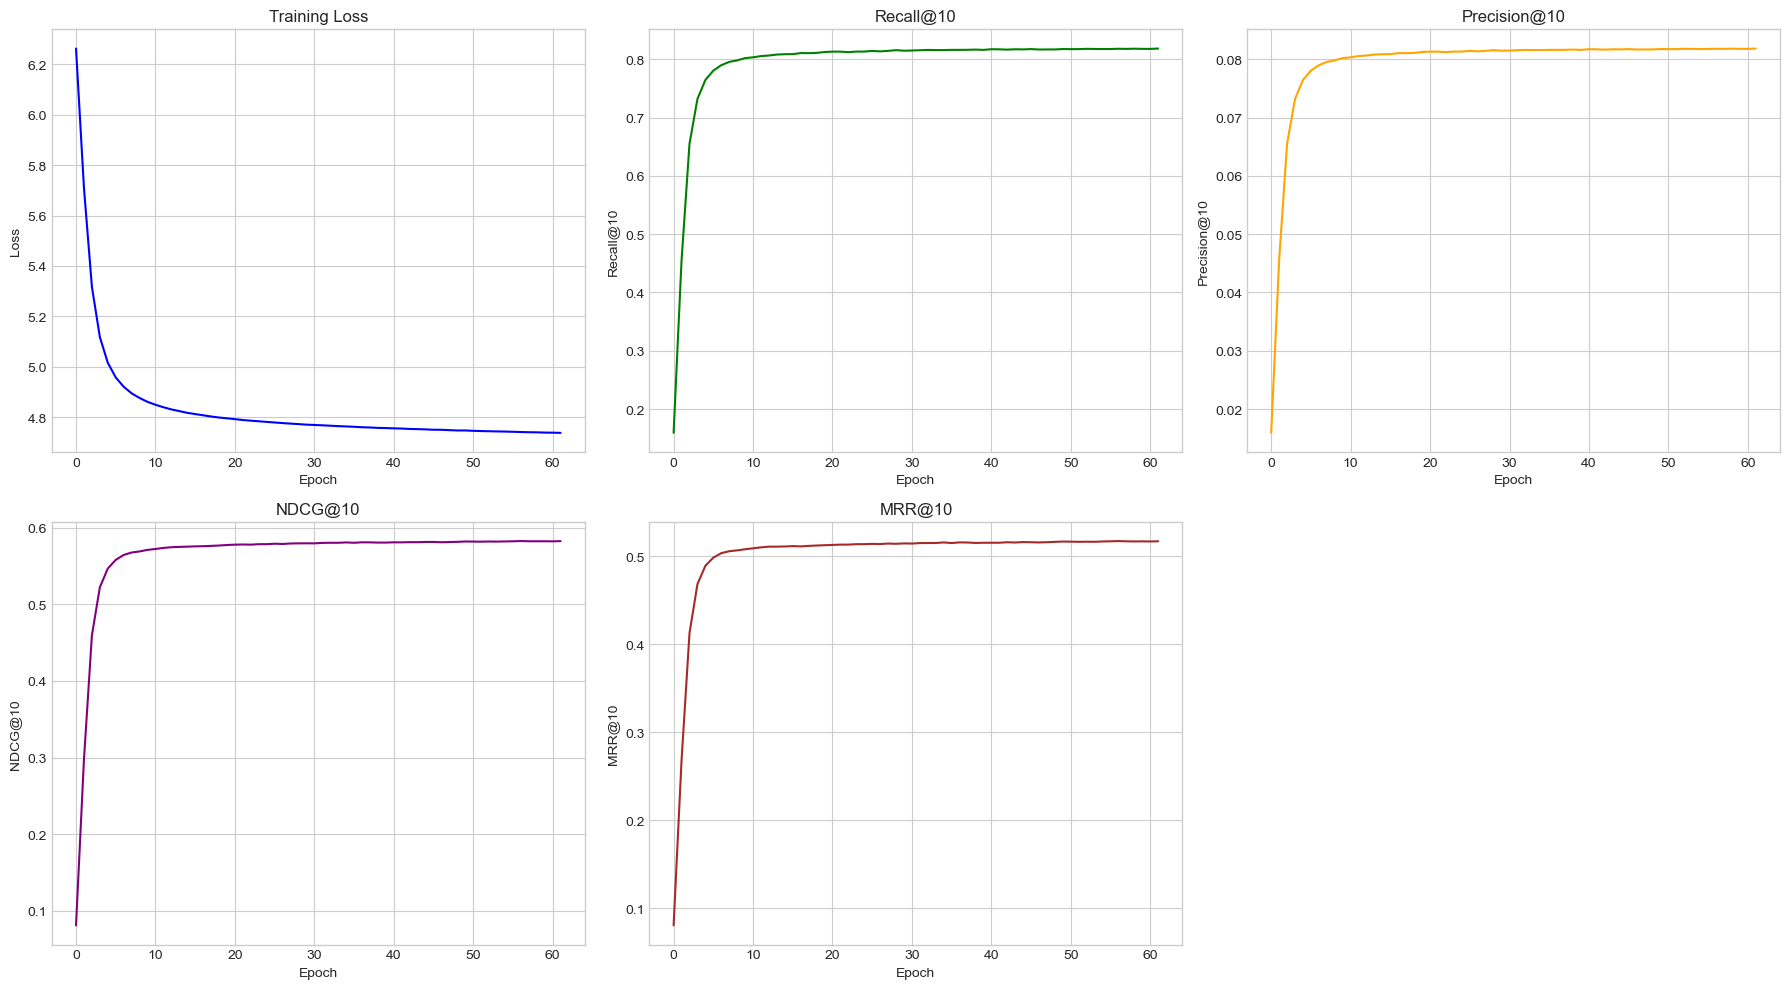

Best epoch: 57
  Recall@10:    0.8183
  Precision@10: 0.0818
  NDCG@10:      0.5824
  MRR@10:       0.5175


In [83]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    (losses_per_epoch,   "Training Loss",          "Loss",          "blue"),
    (recall_epochs,      f"Recall@{k}",            f"Recall@{k}",   "green"),
    (precision_epochs,   f"Precision@{k}",         f"Precision@{k}","orange"),
    (ndcg_epochs,        f"NDCG@{k}",              f"NDCG@{k}",     "purple"),
    (mrr_epochs,         f"MRR@{k}",               f"MRR@{k}",      "brown"),
]

for ax, (data, title, ylabel, color) in zip(axes.flat, metrics):
    ax.plot(data, color=color)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Best epoch summary
best_epoch = int(np.argmax(ndcg_epochs))
print(f"Best epoch: {best_epoch + 1}")
print(f"  Recall@{k}:    {recall_epochs[best_epoch]:.4f}")
print(f"  Precision@{k}: {precision_epochs[best_epoch]:.4f}")
print(f"  NDCG@{k}:      {ndcg_epochs[best_epoch]:.4f}")
print(f"  MRR@{k}:       {mrr_epochs[best_epoch]:.4f}")

## Ablation Study: Sampling Strategy Comparison

We compare five configurations that isolate the effect of each design choice.  
All experiments use the same **100-candidate validation protocol** (1 positive + 100 pre-sampled negatives = 101 candidates per user), consistent with the final shared evaluation.

| Experiment | Sampling Method | MLP | Temperature |
|------------|----------------|-----|-------------|
| In-Batch (baseline) | `in_batch` | No | 0.5 |
| Popularity-Based | `popularity_based` | No | 0.5 |
| Hybrid | `hybrid_negative_sampling` | No | 0.5 |
| Hybrid + lower τ | `hybrid_negative_sampling` | No | 0.3 |
| Hybrid + MLP | `hybrid_negative_sampling` | Yes | 0.5 |

In [84]:
# ── Ablation Study: Sampling Strategy Comparison ────────────────────────────

ABLATION_CONFIGS = [
    {"name": "In-Batch (baseline)",   "sampling_method": "in_batch",               "use_mlp_layers": False, "temperature": 0.5},
    {"name": "Popularity-Based",      "sampling_method": "popularity_based",        "use_mlp_layers": False, "temperature": 0.5},
    {"name": "Hybrid",                "sampling_method": "hybrid_negative_sampling","use_mlp_layers": False, "temperature": 0.5},
    {"name": "Hybrid + low τ=0.3",    "sampling_method": "hybrid_negative_sampling","use_mlp_layers": False, "temperature": 0.3},
    {"name": "Hybrid + MLP",          "sampling_method": "hybrid_negative_sampling","use_mlp_layers": True,  "temperature": 0.5},
]

SHARED = {
    "epoch_size": 200,
    "d_model": 128,
    "batch_size": 512,
    "lr": 0.05,
    "dropout_rate": 0.3,
    "n_neg_sample_popularity": 5,
    "patient": 5,
}

k = 10
ablation_results = []

# Reuse the pre-loaded 100-candidate tensors from Section 6
abl_val_loader = DataLoader(
    TensorDataset(val_user_ids_t, candidates_val_t),
    batch_size=SHARED["batch_size"], shuffle=False
)

global_best_ablation_ndcg = 0.0
global_best_ablation_model_state = None

for cfg in ABLATION_CONFIGS:
    # Reset RNGs so initialisation and negative sampling are comparable across configurations.
    seed_twotower()
    print(f"\n{'='*60}")
    print(f"Running: {cfg['name']}")
    print(f"{'='*60}")

    model = TwoTowerModel(
        processor.n_user, processor.n_item, SHARED["d_model"],
        use_mlp_layers  = cfg["use_mlp_layers"],
        sampling_method = cfg["sampling_method"],
        temperature     = cfg["temperature"],
        dropout_rate    = SHARED["dropout_rate"],
    ).to(device)

    opt   = Adam(model.parameters(), lr=SHARED["lr"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SHARED["epoch_size"], eta_min=1e-4)
    loader = DataLoader(train, shuffle=True, batch_size=SHARED["batch_size"])

    best_ndcg_cfg = 0.0
    best_metrics    = {}
    patience_count  = 0
    current_config_best_model_state = None # To store the best model state for the current config

    for epoch in range(SHARED["epoch_size"]):

        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        for user_idx, pos_idx in loader:
            if cfg["sampling_method"] == "in_batch":
                loss = model(user_idx, pos_idx)
            else:
                neg_idx = processor.sample_negative_random(
                    pos_idx, batch_size=len(user_idx),
                    num_negatives=SHARED["n_neg_sample_popularity"])
                loss = model(user_idx, pos_idx, neg_idxs=neg_idx)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # ── 100-Candidate Validation ───────────────────────────────────────────
        model.eval()
        ranks_epoch = []

        with torch.no_grad():
            for bu, bc in abl_val_loader:
                u_vecs = model.usermodel(bu)                                        # (B, d)
                c_vecs = model.itemmodel(bc.view(-1)).view(len(bu), 101, -1)        # (B, 101, d)
                scores = torch.bmm(u_vecs.unsqueeze(1), c_vecs.transpose(1, 2)).squeeze(1)  # (B, 101)
                order  = torch.argsort(scores, dim=1, descending=True)
                pos_ranks = (order == 0).nonzero(as_tuple=True)[1] + 1
                ranks_epoch.extend(pos_ranks.cpu().tolist())

        ranks_arr  = np.array(ranks_epoch)
        hits       = ranks_arr <= k
        recall_val = hits.mean()
        ndcg_val   = np.where(hits, 1.0 / np.log2(ranks_arr + 1), 0.0).mean()
        mrr_val    = (1.0 / ranks_arr).mean()

        print(f"  Epoch {epoch+1:3d}  Recall@{k}: {recall_val:.4f}  NDCG@{k}: {ndcg_val:.4f}  MRR: {mrr_val:.4f}")

        # ── Early Stopping & Checkpointing for current config─────────────────────────────────────
        if ndcg_val > best_ndcg_cfg:
            best_ndcg_cfg = ndcg_val
            best_metrics    = {"Recall@10": recall_val, "NDCG@10": ndcg_val, "MRR": mrr_val, "Best Epoch": epoch + 1}
            patience_count  = 0
            current_config_best_model_state = copy.deepcopy(model.state_dict()) # Freeze the best-epoch weights
        else:
            patience_count += 1
            if patience_count >= SHARED["patient"]:
                print(f"  >> Early stopping at epoch {epoch + 1}.")
                break

        sched.step()

    # Update global best model if current config's best is better
    if best_ndcg_cfg > global_best_ablation_ndcg:
        global_best_ablation_ndcg = best_ndcg_cfg
        global_best_ablation_model_state = current_config_best_model_state

    ablation_results.append({"Model": cfg["name"],
                              "Sampling": cfg["sampling_method"],
                              "MLP": cfg["use_mlp_layers"],
                              "τ": cfg["temperature"],
                              **best_metrics})




Running: In-Batch (baseline)


  Epoch   1  Recall@10: 0.1625  NDCG@10: 0.0825  MRR: 0.0815


  Epoch   2  Recall@10: 0.4769  NDCG@10: 0.3132  MRR: 0.2815


  Epoch   3  Recall@10: 0.6667  NDCG@10: 0.4667  MRR: 0.4186


  Epoch   4  Recall@10: 0.7338  NDCG@10: 0.5191  MRR: 0.4642


...

  Epoch  54  Recall@10: 0.7684  NDCG@10: 0.5088  MRR: 0.4394


  Epoch  55  Recall@10: 0.7681  NDCG@10: 0.5091  MRR: 0.4398


  Epoch  56  Recall@10: 0.7687  NDCG@10: 0.5089  MRR: 0.4393


  Epoch  57  Recall@10: 0.7680  NDCG@10: 0.5085  MRR: 0.4391


  Epoch  58  Recall@10: 0.7678  NDCG@10: 0.5090  MRR: 0.4397
  >> Early stopping at epoch 58.


In [85]:
# Save the globally best model after the ablation study
from pathlib import Path

if global_best_ablation_model_state is not None:
    artifact_root = Path(ARTIFACT_ROOT)
    artifact_root.mkdir(parents=True, exist_ok=True)
    save_path = artifact_root / "collaborative_model.pt"
    torch.save(global_best_ablation_model_state, save_path)
    print(f"\nSaved the overall best model from ablation study with NDCG@{k}: {global_best_ablation_ndcg:.4f}")

results_df = pd.DataFrame(ablation_results).sort_values("NDCG@10", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("Ablation Study Results (100-Candidate Validation, k=10)")
print("="*70)
print(results_df.to_string(index=False))


Saved the overall best model from ablation study with NDCG@10: 0.5808

Ablation Study Results (100-Candidate Validation, k=10)
              Model                 Sampling   MLP   τ  Recall@10  NDCG@10      MRR  Best Epoch
 Hybrid + low τ=0.3 hybrid_negative_sampling False 0.3   0.816363 0.580777 0.516001          37
   Popularity-Based         popularity_based False 0.5   0.799097 0.555573 0.489535          36
In-Batch (baseline)                 in_batch False 0.5   0.786625 0.549877 0.486544          11
             Hybrid hybrid_negative_sampling False 0.5   0.787396 0.549787 0.486126          11
       Hybrid + MLP hybrid_negative_sampling  True 0.5   0.769806 0.509894 0.440256          53


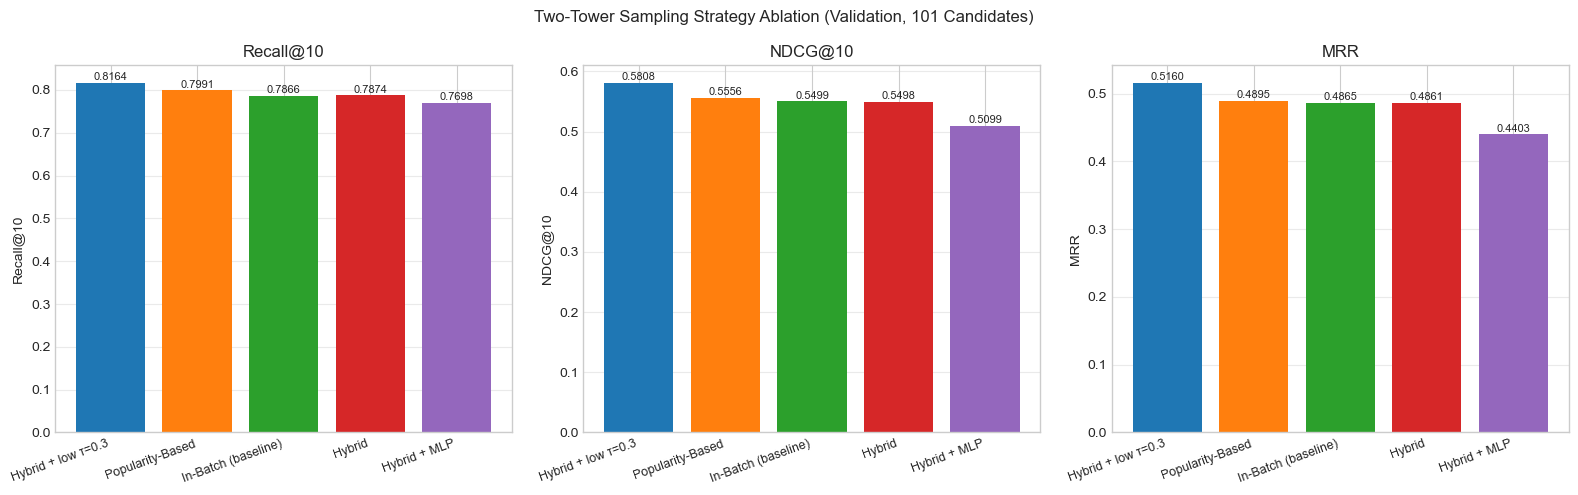

In [86]:
import matplotlib.pyplot as plt
metrics_to_plot = ["Recall@10", "NDCG@10", "MRR"]
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=colors[:len(results_df)])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelrotation=20)
    plt.setp(ax.get_xticklabels(), ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=8)

plt.suptitle("Two-Tower Sampling Strategy Ablation (Validation, 101 Candidates)", fontsize=12)
plt.tight_layout()
plt.show()

## Best model on testset

Evaluate the saved best model using the standard 100-candidate protocol (shared across all team models)

In [87]:
EVAL_SEED = 2026
K_VALUES = [10, 20, 50, 100]
NUM_ITEMS = 81322
ARTIFACT_ROOT = "."
# Load and sort both files by user_idx to ensure alignment
val_df = pd.read_csv(DATA_ROOT + "/test.csv").sort_values("user_idx").reset_index(drop=True)

user_ids_np = val_df["user_idx"].values
pos_items_np = val_df["pos_idx"].values

# Evaluate against the full catalogue of books for each user.
all_item_ids = np.arange(NUM_ITEMS, dtype=np.int64)


def rank_from_scores(user, positive_item, scores, seed):
    """Rank a positive item against the full catalogue with seeded tie-breaking shuffle."""
    candidates = np.arange(len(scores), dtype=np.int64)
    rng = np.random.default_rng(seed + int(user))
    perm = rng.permutation(len(candidates))
    shuffled_positive = int(np.flatnonzero(perm == positive_item)[0])
    order = np.argsort(-scores[perm], kind="stable")
    return int(np.flatnonzero(order == shuffled_positive)[0]) + 1


# Load the best checkpoint saved during training
twotower_model.load_state_dict(torch.load('/content/drive/MyDrive/collaborative_model.pt', map_location=device))
twotower_model.eval()

ranks = []
BATCH = 512

with torch.no_grad():
    item_vectors = twotower_model.itemmodel(torch.tensor(all_item_ids, dtype=torch.long, device=device))
    for start in range(0, len(user_ids_np), BATCH):
        end = min(start + BATCH, len(user_ids_np))
        bu = torch.tensor(user_ids_np[start:end], dtype=torch.long, device=device)
        u_vecs = twotower_model.usermodel(bu)
        scores = torch.matmul(u_vecs, item_vectors.t())
        scores_np = scores.cpu().numpy()

        for i, user in enumerate(user_ids_np[start:end]):
            ranks.append(rank_from_scores(user, int(pos_items_np[start + i]), scores_np[i], EVAL_SEED))

ranks = np.array(ranks)

print("=== Two-Tower HNS-TT | Full-catalogue evaluation ===")
for K in K_VALUES:
    hits = ranks <= K
    ndcg = np.where(hits, 1.0 / np.log2(ranks + 1), 0.0)
    print(f"@{K}: Recall={hits.mean():.4f} | Precision={hits.mean() / K:.4f} | NDCG={ndcg.mean():.4f} | MRR={(1.0 / ranks).mean():.4f}")
print(f"Users: {len(ranks)}")


=== Two-Tower HNS-TT | Full-catalogue evaluation ===
@10: Recall=0.0252 | Precision=0.0025 | NDCG=0.0101 | MRR=0.0099
@20: Recall=0.0455 | Precision=0.0023 | NDCG=0.0152 | MRR=0.0099
@50: Recall=0.0847 | Precision=0.0017 | NDCG=0.0229 | MRR=0.0099
@100: Recall=0.1258 | Precision=0.0013 | NDCG=0.0296 | MRR=0.0099
Users: 64867


# 5. Hybrid Model

This section combines the final **content-based**, **Two-Tower** and
**GRU4Rec sequential** models into one reproducible hybrid-recommendation workflow.

It does not retrain the large component models. Instead, it loads their saved assets,
generates candidate-level scores under one shared protocol, then evaluates individual
and hybrid models fairly.

## Implemented hybrid strategies

1. **Weighted score fusion**: combines per-user z-score-normalised content, CF and
   sequential scores using one set of validation-selected global weights.
2. **Cascade retrieval + confidence-weighted re-ranking**: content and CF retrieve a
   candidate pool, then the three component scores are combined for re-ranking, with
   the GRU4Rec weight adjusted using its relative confidence.
3. **Learned meta-ranking alternatives**: compares linear Learning-to-Rank and
   nonlinear Random Fourier Feature rankers across three score normalisations.

## Important scope

The final content model artifact was not copied into this repository, but its complete
candidate-level validation and test scores were saved in
`Content_Based/content_based_candidate_scores.csv.gz`. Therefore this notebook can run
the fully reproducible **offline hybrid experiment** immediately. Dynamic full-catalogue
content scoring requires the missing content vectorizer/embedding artifact; this is
reported explicitly in the final audit cell.


## Environment and paths

The notebook automatically uses GPU in Colab when available, but all inference code is
also valid on CPU. GPU is recommended because generating GRU4Rec scores for about 13
million user-candidate pairs can take several minutes on CPU.

Run this notebook from the project root after copying the whole project to Colab. Edit
only the path candidates below if your Drive layout differs.

In [88]:
from __future__ import annotations

import gzip
import json
import math
import random
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None

SEED = 2026
TOP_K = 10
SCORE_BATCH_USERS = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "processed_kindle",
    PROJECT_ROOT / "processed_kindle",
    PROJECT_ROOT / "proj2" / "processed_kindle",
]
ARTIFACT_ROOT_CANDIDATES = [
    PROJECT_ROOT / "proj2" / "outputs",
    PROJECT_ROOT / "outputs",
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.is_dir()), None)
ARTIFACT_ROOT = next((p for p in ARTIFACT_ROOT_CANDIDATES if p.is_dir()), None)
assert ARTIFACT_ROOT is not None, f"Cannot find model outputs under {PROJECT_ROOT.resolve()}"
CONTENT_SCORE_PATH = ARTIFACT_ROOT / "content_based" / "content_based_candidate_scores.csv.gz"
CF_CHECKPOINT = ARTIFACT_ROOT / "collaborative_model.pt"
GRU_CHECKPOINT = ARTIFACT_ROOT / "gru4rec_best.pt"
OUTPUT_DIR = ARTIFACT_ROOT / "hybrid"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR is not None, f"Cannot find processed_kindle under {PROJECT_ROOT.resolve()}"
assert CONTENT_SCORE_PATH.exists(), f"Missing {CONTENT_SCORE_PATH}"
assert CF_CHECKPOINT.exists(), f"Missing {CF_CHECKPOINT}"
assert GRU_CHECKPOINT.exists(), f"Missing {GRU_CHECKPOINT}"

print("project root:", PROJECT_ROOT.resolve())
print("data directory:", DATA_DIR.resolve())
print("device:", DEVICE)

project root: D:\unsw\COMP9727\proj2
data directory: D:\unsw\COMP9727\proj2\processed_kindle
device: cuda


## Load shared data and audit the evaluation protocol

Every model is evaluated on exactly the same candidate set: one held-out positive book
and 100 pre-generated negatives per user. Validation uses only training history; test
uses training history plus the validation interaction. This is the common protocol used
by the content and sequential notebooks.

In [89]:
def parse_item_sequence(value: str) -> list[int]:
    if pd.isna(value) or not str(value).strip():
        return []
    return [int(x) for x in str(value).split()]

train_sequences_df = pd.read_csv(DATA_DIR / "train_sequences.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
item_metadata = pd.read_csv(DATA_DIR / "item_metadata.csv")
interactions = pd.read_csv(DATA_DIR / "interactions_clean.csv")

train_sequences = dict(zip(
    train_sequences_df.user_idx.astype(int),
    train_sequences_df.item_seq.map(parse_item_sequence),
))
val_targets = dict(zip(val_df.user_idx.astype(int), val_df.pos_idx.astype(int)))
test_targets = dict(zip(test_df.user_idx.astype(int), test_df.pos_idx.astype(int)))

with open(DATA_DIR / "preprocess_stats.json", encoding="utf-8") as f:
    preprocess_stats = json.load(f)

USER_COUNT = len(train_sequences)
ITEM_COUNT = int(item_metadata.item_idx.max()) + 1
assert set(train_sequences) == set(val_targets) == set(test_targets)
assert USER_COUNT == preprocess_stats["num_users"]
assert ITEM_COUNT == preprocess_stats["num_items"]

train_popularity = np.bincount(
    interactions.loc[interactions["split"] == "train", "item_idx"].to_numpy(),
    minlength=ITEM_COUNT,
).astype(np.float32)
popularity_scores = np.log1p(train_popularity)

test_contexts = {
    user: train_sequences[user] + [val_targets[user]]
    for user in train_sequences
}

print(f"users={USER_COUNT:,}; items={ITEM_COUNT:,}")
print(f"train interactions={preprocess_stats['num_train_interactions']:,}")
print("protocol: validation=train history; test=train history + validation target")

users=64,867; items=81,322
train interactions=884,136
protocol: validation=train history; test=train history + validation target


## Load the canonical content-model candidate scores

The content notebook selected **Weighted-TFIDF-TUNED** using validation NDCG@10 and
exported a score for every official candidate. This file is used as the canonical
candidate ordering for all models, so it prevents the previous collaborative-filtering
candidate-set mismatch (where a negative was accidentally treated as a positive).

In [90]:
def load_canonical_split(split: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return users, candidates, content scores and positive-at-column-zero labels."""
    frame = pd.read_csv(
        CONTENT_SCORE_PATH,
        compression="gzip",
        usecols=["user_idx", "item_idx", "split", "score", "is_positive"],
    )
    frame = frame.loc[frame["split"] == split].copy()
    frame.sort_values(["user_idx"], kind="stable", inplace=True)
    group_sizes = frame.groupby("user_idx", sort=True).size()
    assert len(group_sizes) == USER_COUNT and group_sizes.eq(101).all(), "Expected 101 candidates/user"

    users = group_sizes.index.to_numpy(dtype=np.int64)
    candidates = frame.item_idx.to_numpy(dtype=np.int64).reshape(-1, 101)
    scores = frame.score.to_numpy(dtype=np.float32).reshape(-1, 101)
    positives = frame.is_positive.astype(bool).to_numpy().reshape(-1, 101)
    assert positives[:, 0].all() and positives.sum() == len(users), "Positive must be first candidate"
    return users, candidates, scores, positives

val_users, val_candidates, val_content_scores, val_positive_mask = load_canonical_split("validation")
test_users, test_candidates, test_content_scores, test_positive_mask = load_canonical_split("test")

assert np.array_equal(val_users, test_users)
assert np.array_equal(val_candidates[:, 0], np.array([val_targets[u] for u in val_users]))
assert np.array_equal(test_candidates[:, 0], np.array([test_targets[u] for u in test_users]))

print("canonical score file verified")
print("validation matrix:", val_candidates.shape, "test matrix:", test_candidates.shape)

canonical score file verified
validation matrix: (64867, 101) test matrix: (64867, 101)


## Recreate the two saved PyTorch inference models

The collaborative checkpoint stores only embedding weights, so the small Two-Tower
architecture is reconstructed here. The sequential checkpoint stores its GRU4Rec
configuration and state dictionary. No training is performed in this notebook.

In [91]:
class TwoTowerInference(nn.Module):
    """Matches the final CF notebook when use_mlp_layers=False."""
    def __init__(self, n_users: int, n_items: int, embedding_dim: int):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

    def score_candidates(self, users: torch.Tensor, candidates: torch.Tensor) -> torch.Tensor:
        user_vec = F.normalize(self.user_embedding(users), p=2, dim=1)
        item_vec = F.normalize(self.item_embedding(candidates), p=2, dim=2)
        return torch.einsum("bd,bcd->bc", user_vec, item_vec)


class GRU4RecInference(nn.Module):
    """Architecture matched to SASRec_Sequential_Recommender.ipynb."""
    def __init__(self, num_items: int, max_len: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.max_len = max_len
        self.item_embedding = nn.Embedding(num_items + 1, hidden_dim, padding_idx=0)
        self.gru = nn.GRU(
            hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, item_ids: torch.Tensor) -> torch.Tensor:
        lengths = item_ids.ne(0).sum(dim=1).clamp_min(1).cpu()
        embedded = self.dropout(self.item_embedding(item_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        packed_outputs, _ = self.gru(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs, batch_first=True, total_length=self.max_len
        )
        return self.dropout(output)

    def score_candidates(self, item_ids: torch.Tensor, candidate_ids: torch.Tensor) -> torch.Tensor:
        features = self(item_ids)
        final_pos = item_ids.ne(0).sum(dim=1).clamp_min(1).sub(1)
        context = features[torch.arange(item_ids.size(0), device=item_ids.device), final_pos]
        return torch.einsum("bd,bcd->bc", context, self.item_embedding(candidate_ids))


def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:  # compatibility with older PyTorch versions
        return torch.load(path, map_location="cpu")


cf_state = safe_torch_load(CF_CHECKPOINT)
cf_user_shape = cf_state["usermodel.model.weight"].shape
cf_item_shape = cf_state["itemmodel.model.weight"].shape
assert cf_user_shape[0] == USER_COUNT and cf_item_shape[0] == ITEM_COUNT
assert cf_user_shape[1] == cf_item_shape[1]

cf_model = TwoTowerInference(USER_COUNT, ITEM_COUNT, cf_user_shape[1])
cf_model.user_embedding.weight.data.copy_(cf_state["usermodel.model.weight"])
cf_model.item_embedding.weight.data.copy_(cf_state["itemmodel.model.weight"])
cf_model = cf_model.to(DEVICE).eval()

gru_checkpoint = safe_torch_load(GRU_CHECKPOINT)
gru_config = gru_checkpoint["config"]
assert gru_checkpoint["num_items"] == ITEM_COUNT
assert gru_checkpoint.get("raw_to_model_item_offset", 1) == 1
gru_model = GRU4RecInference(
    num_items=ITEM_COUNT,
    max_len=int(gru_config["max_len"]),
    hidden_dim=int(gru_config["hidden_dim"]),
    num_layers=int(gru_config["num_layers"]),
    dropout=float(gru_config["dropout"]),
)
gru_model.load_state_dict(gru_checkpoint["model_state_dict"])
gru_model = gru_model.to(DEVICE).eval()

print("CF embedding dimension:", cf_user_shape[1])
print("GRU4Rec config:", {k: gru_config[k] for k in ["name", "max_len", "hidden_dim", "num_layers", "dropout"]})

CF embedding dimension: 128
GRU4Rec config: {'name': 'GRU4Rec-short-20', 'max_len': 20, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.1}


## Generate or reuse aligned CF and GRU4Rec candidate scores

Both saved models score the **same 101 candidates in the same order** as the content
file. Cached `.npy` arrays make repeated fusion experiments fast. Delete the cache files
in `hybrid_results/` only if a component checkpoint changes.

In [92]:
def right_pad_context(history: list[int], max_len: int) -> np.ndarray:
    history = list(history)[-max_len:]
    padded = np.zeros(max_len, dtype=np.int64)
    if history:
        padded[:len(history)] = np.asarray(history, dtype=np.int64) + 1
    return padded


@torch.no_grad()
def score_cf(users: np.ndarray, candidates: np.ndarray) -> np.ndarray:
    blocks = []
    for start in range(0, len(users), SCORE_BATCH_USERS):
        end = start + SCORE_BATCH_USERS
        u = torch.as_tensor(users[start:end], dtype=torch.long, device=DEVICE)
        c = torch.as_tensor(candidates[start:end], dtype=torch.long, device=DEVICE)
        blocks.append(cf_model.score_candidates(u, c).cpu().numpy().astype(np.float32))
    return np.vstack(blocks)


@torch.no_grad()
def score_gru(users: np.ndarray, candidates: np.ndarray, contexts: dict[int, list[int]]) -> np.ndarray:
    blocks = []
    max_len = int(gru_config["max_len"])
    for start in range(0, len(users), SCORE_BATCH_USERS):
        end = start + SCORE_BATCH_USERS
        histories = np.stack([right_pad_context(contexts[int(u)], max_len) for u in users[start:end]])
        # Model IDs reserve zero for padding, hence raw item index + 1.
        c = candidates[start:end] + 1
        history_tensor = torch.as_tensor(histories, dtype=torch.long, device=DEVICE)
        candidate_tensor = torch.as_tensor(c, dtype=torch.long, device=DEVICE)
        blocks.append(gru_model.score_candidates(history_tensor, candidate_tensor).cpu().numpy().astype(np.float32))
    return np.vstack(blocks)


def load_or_generate_scores(name: str, split: str, scorer, users, candidates, contexts=None, force=False) -> np.ndarray:
    path = OUTPUT_DIR / f"{name}_{split}_candidate_scores.npy"
    if path.exists() and not force:
        scores = np.load(path)
        assert scores.shape == candidates.shape
        print(f"loaded cached {path.name}")
        return scores
    started = time.time()
    scores = scorer(users, candidates) if contexts is None else scorer(users, candidates, contexts)
    np.save(path, scores)
    print(f"generated {path.name} in {time.time() - started:.1f}s")
    return scores


# Regenerate after training so Hybrid scores always match this run's checkpoints.
val_cf_scores = load_or_generate_scores("cf", "validation", score_cf, val_users, val_candidates, force=True)
test_cf_scores = load_or_generate_scores("cf", "test", score_cf, test_users, test_candidates, force=True)
val_gru_scores = load_or_generate_scores("gru4rec", "validation", score_gru, val_users, val_candidates, train_sequences, force=True)
test_gru_scores = load_or_generate_scores("gru4rec", "test", score_gru, test_users, test_candidates, test_contexts, force=True)

generated cf_validation_candidate_scores.npy in 0.3s
generated cf_test_candidate_scores.npy in 0.1s


generated gru4rec_validation_candidate_scores.npy in 0.5s


generated gru4rec_test_candidate_scores.npy in 0.4s


## Shared ranking metrics and catalogue diagnostics

The positive book is stored in candidate column zero. Scores are converted to a rank for
each user, then aggregated into Recall/Hit@10, Precision@10, NDCG@10 and MRR. Catalogue
metrics are computed from each model's Top-10 test recommendations.

In [93]:
def ranks_from_scores(scores: np.ndarray) -> np.ndarray:
    """Positive is column zero; stable sorting resolves exact ties reproducibly."""
    order = np.argsort(-scores, axis=1, kind="stable")
    return np.argmax(order == 0, axis=1) + 1


def ranking_metrics(scores: np.ndarray, k: int = TOP_K) -> dict[str, float]:
    ranks = ranks_from_scores(scores)
    hits = ranks <= k
    return {
        f"Hit@{k}": float(hits.mean()),
        f"Recall@{k}": float(hits.mean()),
        f"Precision@{k}": float(hits.mean() / k),
        f"NDCG@{k}": float(np.where(hits, 1.0 / np.log2(ranks + 1), 0.0).mean()),
        "MRR": float((1.0 / ranks).mean()),
        "users": int(len(ranks)),
    }


item_categories = {
    int(row.item_idx): frozenset(x.strip() for x in str(row.categories).split(";") if x.strip())
    for row in item_metadata.itertuples()
}


def catalogue_metrics_fn(scores: np.ndarray, candidates: np.ndarray, k: int = TOP_K) -> dict[str, float]:
    top_positions = np.argsort(-scores, axis=1, kind="stable")[:, :k]
    top_items = np.take_along_axis(candidates, top_positions, axis=1)
    flat_items = top_items.ravel()
    total = float(train_popularity.sum() + ITEM_COUNT)
    max_novelty = max(float(np.log2(total)), 1e-8)
    item_novelty = -np.log2((train_popularity[flat_items] + 1.0) / total) / max_novelty
    novelty = float(np.mean(item_novelty))
    diversities = []
    for row in top_items:
        pair_sims = []
        for i in range(len(row)):
            for j in range(i + 1, len(row)):
                left, right = item_categories.get(int(row[i]), frozenset()), item_categories.get(int(row[j]), frozenset())
                pair_sims.append(len(left & right) / max(len(left | right), 1))
        diversities.append(1.0 - np.mean(pair_sims) if pair_sims else 0.0)
    return {
        "CatalogueCoverage": float(len(np.unique(flat_items)) / ITEM_COUNT),
        "Novelty": novelty,
        "IntraListDiversity": float(np.mean(diversities)),
    }


def evaluate_model(name: str, validation_scores: np.ndarray, test_scores: np.ndarray) -> list[dict]:
    rows = []
    for split, scores, candidates in [
        ("validation", validation_scores, val_candidates),
        ("test", test_scores, test_candidates),
    ]:
        rows.append({"model": name, "split": split, **ranking_metrics(scores), **catalogue_metrics_fn(scores, candidates)})
    return rows

## Evaluate the individual models

Before fusion, re-evaluate content, CF and GRU4Rec under one implementation and one
candidate protocol. A popularity baseline is also included to make gains interpretable.

In [94]:
val_popularity_scores = popularity_scores[val_candidates]
test_popularity_scores = popularity_scores[test_candidates]

results = []
results += evaluate_model("Popularity", val_popularity_scores, test_popularity_scores)
results += evaluate_model("Content: Weighted-TFIDF", val_content_scores, test_content_scores)
results += evaluate_model("Two-Tower", val_cf_scores, test_cf_scores)
results += evaluate_model("Sequential: GRU4Rec", val_gru_scores, test_gru_scores)

single_model_results = pd.DataFrame(results)
display(single_model_results.sort_values(["split", f"NDCG@{TOP_K}"], ascending=[True, False]))

,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
5,Two-Tower,test,0.763886,0.763886,0.076389,0.521595,0.457230,64867,0.978099,0.830263,0.655406
3,Content: Weighted-TFIDF,test,0.591441,0.591441,0.059144,0.428251,0.393531,64867,0.818315,0.827954,0.547997
7,Sequential: GRU4Rec,test,0.640742,0.640742,0.064074,0.423697,0.371434,64867,0.832739,0.796191,0.679514
1,Popularity,test,0.381195,0.381195,0.038120,0.235453,0.209538,64867,0.181611,0.738380,0.676371
4,Two-Tower,validation,0.816363,0.816363,0.081636,0.580777,0.516001,64867,0.978505,0.829419,0.654996
6,Sequential: GRU4Rec,validation,0.677725,0.677725,0.067773,0.455477,0.400238,64867,0.833895,0.794383,0.682697
2,Content: Weighted-TFIDF,validation,0.593152,0.593152,0.059315,0.434093,0.400600,64867,0.833587,0.827872,0.552901
0,Popularity,validation,0.412567,0.412567,0.041257,0.256567,0.227543,64867,0.181845,0.738126,0.676716


## Hybrid 1: adaptive weighted score fusion

This section optimises the weighted fusion strategy used to combine the prediction scores from the Content-Based, two tower, and GRU recommendation models. Since the three models produce scores with different numerical distributions, **z-score normalisation** is first applied independently to each model to standardise the scores and ensure that they are directly comparable before fusion.

The final recommendation score is computed as a weighted combination of the normalised prediction scores. To identify the most effective weight configuration, a two-stage grid search is performed on the validation set using **NDCG@10** as the optimisation objective. A coarse search is first conducted over the entire weight space with a step size of 0.1 to locate a promising region. A finer search with a step size of 0.01 is then carried out around the best coarse solution to obtain a more precise set of fusion weights.

The optimal weight combination selected from the fine search is used as the final Adaptive Weighted fusion model for subsequent evaluation and comparison with the other recommendation approaches.

In [95]:
def z_normalise(scores: np.ndarray) -> np.ndarray:
    mean = scores.mean(axis=1, keepdims=True)
    std = scores.std(axis=1, keepdims=True)
    return (scores - mean) / np.maximum(std, 1e-8)


def weighted_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, weights: tuple[float, float, float]) -> np.ndarray:
    wc, wf, ws = weights
    return wc * z_normalise(content) + wf * z_normalise(cf) + ws * z_normalise(gru)


coarse_results = []
coarse_grid = np.arange(0.0, 1.01, 0.1)
for wc in coarse_grid:
    for wf in coarse_grid:
        ws = round(1.0 - wc - wf, 10)
        if ws < 0:
            continue
        weights = (float(wc), float(wf), float(ws))
        metrics = ranking_metrics(weighted_fusion(val_content_scores, val_cf_scores, val_gru_scores, weights))

        coarse_results.append({"content_weight": wc, "cf_weight": wf, "gru_weight": ws, **metrics})

coarse_search = (pd.DataFrame(coarse_results).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True))
coarse_best = tuple(coarse_search.loc[0,["content_weight", "cf_weight", "gru_weight"]].astype(float))
print("Coarse best weights:", coarse_best)
display(coarse_search.head())


best_wc, best_wf, _ = coarse_best
fine_results = []
wc_range = np.arange( max(0, best_wc - 0.1), min(1, best_wc + 0.1) + 0.001,0.01,)
wf_range = np.arange(max(0, best_wf - 0.1),min(1, best_wf + 0.1) + 0.001,0.01,)

for wc in wc_range:
    for wf in wf_range:
        ws = round(1.0 - wc - wf, 10)
        if ws < 0 or ws > 1:
            continue

        weights = (round(float(wc), 2), round(float(wf), 2), round(float(ws), 2),)
        metrics = ranking_metrics( weighted_fusion( val_content_scores, val_cf_scores, val_gru_scores, weights))
        fine_results.append({"content_weight": weights[0], "cf_weight": weights[1], "gru_weight": weights[2],**metrics})

fine_search = (pd.DataFrame(fine_results).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True))
best_weights = tuple(fine_search.loc[0,["content_weight", "cf_weight", "gru_weight"]].astype(float))

print("Final best weights:", best_weights)
display(fine_search.head(10))

Coarse best weights: (0.2, 0.4, 0.4)


,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,0.2,0.4,0.4,0.852097,0.852097,0.085210,0.652441,0.596908,64867
1,0.2,0.5,0.3,0.853022,0.853022,0.085302,0.649237,0.592548,64867
2,0.2,0.3,0.5,0.842616,0.842616,0.084262,0.647758,0.593989,64867
3,0.3,0.4,0.3,0.848999,0.848999,0.084900,0.645669,0.589268,64867
4,0.1,0.5,0.4,0.850386,0.850386,0.085039,0.645098,0.587987,64867


Final best weights: (0.19, 0.39, 0.42)


,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,0.19,0.39,0.42,0.851635,0.851635,0.085163,0.652525,0.597162,64867
1,0.19,0.40,0.41,0.851774,0.851774,0.085177,0.652524,0.597128,64867
2,0.19,0.41,0.40,0.852082,0.852082,0.085208,0.652474,0.596978,64867
3,0.20,0.40,0.40,0.852097,0.852097,0.085210,0.652441,0.596908,64867
4,0.21,0.40,0.39,0.852483,0.852483,0.085248,0.652432,0.596784,64867
5,0.20,0.41,0.39,0.852483,0.852483,0.085248,0.652330,0.596658,64867
6,0.19,0.42,0.39,0.852637,0.852637,0.085264,0.652297,0.596568,64867
7,0.20,0.39,0.41,0.851681,0.851681,0.085168,0.652296,0.596845,64867
8,0.18,0.42,0.40,0.852699,0.852699,0.085270,0.652292,0.596517,64867
9,0.21,0.39,0.40,0.851882,0.851882,0.085188,0.652243,0.596714,64867


## Hybrid 2: cascade retrieval and confidence-weighted re-ranking

This hybrid uses a two-stage recommendation framework consisting of candidate retrieval
and re-ranking.

In the retrieval stage, the top candidates from the Content-Based and Collaborative
Filtering models are combined into one candidate pool. Their retrieval sizes
(`content_top_k` and `cf_top_k`) are tuned on the validation set. GRU4Rec does not add a
separate retrieval list in this implementation; it contributes during re-ranking.

In the re-ranking stage, the Content-Based, Two-Tower and GRU4Rec scores
are combined. The GRU4Rec weight increases when its maximum candidate score indicates
higher relative confidence across users. The remaining weight is divided between
Content-Based and Two-Tower in a 60:40 ratio. Only items in the retrieved
candidate pool remain eligible; all other candidates receive negative-infinity scores.

The two retrieval sizes and the base GRU4Rec weight are selected by validation NDCG@10,
then the selected configuration is evaluated on the test set.


In [96]:
def adaptive_weighted_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, base_gru_weight: float,) -> np.ndarray:
    # Put heterogeneous model scores on a comparable per-user scale.
    content = z_normalise(content)
    cf = z_normalise(cf)
    gru = z_normalise(gru)
    gru_confidence = gru.max(axis=1)
    confidence = (gru_confidence - gru_confidence.min()) / (gru_confidence.max() - gru_confidence.min() + 1e-8)

    # GRU weight increases with confidence
    gru_weight = (base_gru_weight + (1.0 - base_gru_weight) * confidence)
    remaining = 1.0 - gru_weight

    # Preserve more long-term preference
    content_weight = remaining * 0.6
    cf_weight = remaining * 0.4

    scores = (content * content_weight[:, None]+ cf * cf_weight[:, None]+ gru * gru_weight[:, None])
    return scores


def cascade_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, cf_top_k: int, content_top_k: int, base_gru_weight: float,) -> np.ndarray:
    """
    Stage 1:
        Candidate Retrieval

        Top-K(CF)
        UNION
        Top-M(Content)

    Stage 2:
        Adaptive Re-ranking
    """
    n_users, n_items = content.shape

    # Candidate Retrieval
    cf_candidates = np.argpartition(-cf, kth=cf_top_k - 1, axis=1,)[:, :cf_top_k]
    content_candidates = np.argpartition(-content,kth=content_top_k - 1, axis=1,)[:, :content_top_k]

    candidate_mask = np.zeros((n_users, n_items),dtype=bool,)
    rows = np.arange(n_users)[:, None]
    candidate_mask[rows, cf_candidates] = True
    candidate_mask[rows, content_candidates] = True

    # Adaptive Re-ranking
    rerank_scores = adaptive_weighted_fusion(content, cf, gru, base_gru_weight,)
    return np.where( candidate_mask, rerank_scores, -np.inf,)



# Hyperparameter Search
cascade_trials = []
cf_candidates = range(40, 81, 5)
content_candidates = range(10, 31, 5)
gru_candidates = np.linspace(0.40,0.60,11)

for cf_top_k in cf_candidates:
    for content_top_k in content_candidates:
        for base_gru_weight in gru_candidates:
            scores = cascade_fusion(val_content_scores, val_cf_scores, val_gru_scores, cf_top_k, content_top_k, base_gru_weight)
            metrics = ranking_metrics(scores)
            cascade_trials.append({
                "cf_top_k": cf_top_k,
                "content_top_k": content_top_k,
                "base_gru_weight": base_gru_weight,
                **metrics,
            })

cascade_search = (
    pd.DataFrame(cascade_trials)
    .sort_values(
        f"NDCG@{TOP_K}",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(cascade_search.head(10))
best = cascade_search.iloc[0]
best_cf_top_k = int(best.cf_top_k)
best_content_top_k = int(best.content_top_k)
best_base_gru_weight = float(best.base_gru_weight)

print(
    "Best Cascade Configuration\n"
    f"CF Top-K        : {best_cf_top_k}\n"
    f"Content Top-K   : {best_content_top_k}\n"
    f"Base GRU Weight : {best_base_gru_weight:.2f}"
)

val_cascade_scores = cascade_fusion(
    val_content_scores,
    val_cf_scores,
    val_gru_scores,
    best_cf_top_k,
    best_content_top_k,
    best_base_gru_weight,
)

test_cascade_scores = cascade_fusion(
    test_content_scores,
    test_cf_scores,
    test_gru_scores,
    best_cf_top_k,
    best_content_top_k,
    best_base_gru_weight,
)

results += evaluate_model(
    "Hybrid 2: Cascade",
    val_cascade_scores,
    test_cascade_scores,
)

,cf_top_k,content_top_k,base_gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,40,10,0.4,0.822329,0.822329,0.082233,0.629989,0.578282,64867
1,45,10,0.4,0.821728,0.821728,0.082173,0.629716,0.578060,64867
2,40,15,0.4,0.821219,0.821219,0.082122,0.629507,0.577990,64867
3,50,10,0.4,0.821311,0.821311,0.082131,0.629504,0.577862,64867
4,45,15,0.4,0.820833,0.820833,0.082083,0.629338,0.577844,64867
5,55,10,0.4,0.820864,0.820864,0.082086,0.629267,0.577671,64867
6,50,15,0.4,0.820540,0.820540,0.082054,0.629178,0.577683,64867
7,40,20,0.4,0.820433,0.820433,0.082043,0.629141,0.577728,64867
8,45,20,0.4,0.820371,0.820371,0.082037,0.629112,0.577660,64867
9,60,10,0.4,0.820510,0.820510,0.082051,0.629112,0.577554,64867


Best Cascade Configuration
CF Top-K        : 40
Content Top-K   : 10
Base GRU Weight : 0.40


## Compare Hybrid methods and optimise Adaptive Weighted

First compare the two original Hybrid methods using the shared protocol. Since Adaptive
Weighted is the validation winner in the recorded experiment, the following factorial
experiment compares three score normalisations with two learned meta-ranker families:

- z-score, min-max and rank-based candidate-score normalisation;
- linear Learning-to-Rank and nonlinear Random Fourier Feature (RFF) ranking.

The original z-score Adaptive Weighted method is retained as a seventh baseline. To
avoid using the test set for model selection, validation users are deterministically
divided into meta-training users and held-out selection users. Learned rankers are refit
using all validation users only after their held-out comparison; test metrics are
reported for generalisation analysis and are not used to choose the winner.


### Compare the original two Hybrid approaches


,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
11,Hybrid 1: Adaptive Weighted,test,0.822591,0.822591,0.082259,0.612793,0.555547,64867,0.916837,0.813519,0.628346
9,Hybrid 2: Cascade,test,0.792961,0.792961,0.079296,0.595063,0.543071,64867,0.878877,0.806748,0.632184
10,Hybrid 1: Adaptive Weighted,validation,0.851635,0.851635,0.085163,0.652525,0.597162,64867,0.918091,0.812423,0.631053
8,Hybrid 2: Cascade,validation,0.822329,0.822329,0.082233,0.629989,0.578282,64867,0.881336,0.805794,0.633220


Validation-winning Hybrid: Hybrid 1: Adaptive Weighted


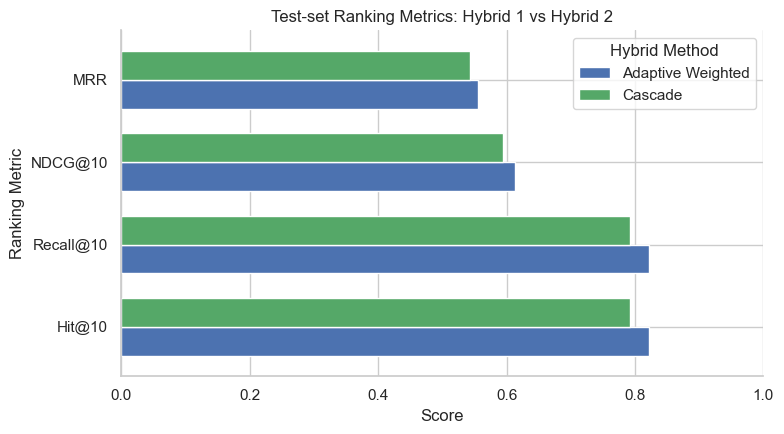

In [97]:

if "best_weights" not in globals():
    raise RuntimeError("Hybrid 1 weights are missing. Run Section 8 first.")
if "results" not in globals():
    results = []
if "Hybrid 1: Adaptive Weighted" not in {row.get("model") for row in results}:
    val_adaptive_weighted_scores = weighted_fusion(val_content_scores, val_cf_scores, val_gru_scores, best_weights)
    test_adaptive_weighted_scores = weighted_fusion(test_content_scores, test_cf_scores, test_gru_scores, best_weights)
    results += evaluate_model( "Hybrid 1: Adaptive Weighted", val_adaptive_weighted_scores, test_adaptive_weighted_scores,)

original_hybrid_names = ["Hybrid 1: Adaptive Weighted","Hybrid 2: Cascade",]
original_hybrid_results = (
    pd.DataFrame(results)
    .loc[
        lambda frame: frame["model"].isin(original_hybrid_names)
    ]
    .drop_duplicates(
        subset=["model", "split"],
        keep="last",
    )
    .copy()
)
missing_hybrids = (set(original_hybrid_names)- set(original_hybrid_results["model"]))
if missing_hybrids:
    raise RuntimeError("Missing original hybrid results: "+ ", ".join(sorted(missing_hybrids)))
display(original_hybrid_results.sort_values(["split", f"NDCG@{TOP_K}"],ascending=[True, False],))

hybrid_validation = (original_hybrid_results.query("split == 'validation'").sort_values(f"NDCG@{TOP_K}",ascending=False,))

if hybrid_validation.empty:
    raise RuntimeError("No validation results were found for the original hybrid models.")

if (hybrid_validation.iloc[0]["model"]!= "Hybrid 1: Adaptive Weighted"):
    raise RuntimeError("Adaptive Weighted is not the validation-winning Hybrid, so it should not be the target of the following optimisation section.")

print("Validation-winning Hybrid:",hybrid_validation.iloc[0]["model"],)
model_order = ["Hybrid 1: Adaptive Weighted","Hybrid 2: Cascade"]
model_display_names = { "Hybrid 1: Adaptive Weighted": "Adaptive Weighted","Hybrid 2: Cascade": "Cascade",}

hybrid_plot_df = original_hybrid_results.loc[(original_hybrid_results["model"].isin(model_order))&(original_hybrid_results["split"] == "test")].copy()


missing_test_models = (set(model_order) - set(hybrid_plot_df["model"]))

if missing_test_models:
    raise RuntimeError("Missing test results for: "+ ", ".join(sorted(missing_test_models)))

plot_df = (
    hybrid_plot_df[
        [
            "model",
            f"Hit@{TOP_K}",
            f"Recall@{TOP_K}",
            f"NDCG@{TOP_K}",
            "MRR",
        ]
    ]
    .set_index("model")
    .reindex(model_order)
    .rename(index=model_display_names)
    .T
)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df.plot(
    kind="barh",
    ax=ax,
    width=0.7,
    color=["#4C72B0",  "#55A868"],
)
ax.set_xlabel("Score")
ax.set_ylabel("Ranking Metric")
ax.set_title(
    "Test-set Ranking Metrics: Hybrid 1 vs Hybrid 2"
)
ax.set_xlim(0, 1)
ax.legend(
    title="Hybrid Method",
    loc="upper right",
    frameon=True,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Shared Helpers for Adaptive Weighted Optimisation

In [98]:

from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

OPTIMISATION_SEED = SEED + 91
LTR_MAX_TRAIN_USERS = 15_000
LTR_NEGATIVES_PER_USER = 20
RFF_COMPONENTS = 96

# Use user identity only to create a reproducible, disjoint validation meta-train/select split.
meta_train_mask = (val_users % 5) != 0
selection_mask = ~meta_train_mask
assert meta_train_mask.any() and selection_mask.any()

def normalise_scores(scores: np.ndarray, method: str) -> np.ndarray:
    if method == "zscore":
        return z_normalise(scores)
    if method == "minmax":
        low = scores.min(axis=1, keepdims=True)
        high = scores.max(axis=1, keepdims=True)
        return (scores - low) / np.maximum(high - low, 1e-8)
    if method == "rank":
        # Highest-scoring candidate receives 1.0, lowest receives 0.0.
        order = np.argsort(-scores, axis=1, kind="stable")
        ranks = np.empty_like(order)
        rows = np.arange(scores.shape[0])[:, None]
        ranks[rows, order] = np.arange(scores.shape[1])
        return 1.0 - ranks / max(scores.shape[1] - 1, 1)
    raise ValueError(f"Unknown normalisation method: {method}")

def normalised_fusion(content, cf, gru, weights, method: str) -> np.ndarray:
    wc, wf, ws = weights
    return (
        wc * normalise_scores(content, method)
        + wf * normalise_scores(cf, method)
        + ws * normalise_scores(gru, method)
    )

def weight_candidates(step: float = 0.1):
    grid = np.arange(0.0, 1.0 + step / 2, step)
    for wc in grid:
        for wf in grid:
            ws = round(1.0 - float(wc) - float(wf), 10)
            if ws >= -1e-9:
                yield (float(wc), float(wf), max(0.0, float(ws)))

def select_fusion_weights(content, cf, gru, mask, method: str):
    best_row = None
    for weights in weight_candidates():
        metrics = ranking_metrics(normalised_fusion(content[mask], cf[mask], gru[mask], weights, method))
        row = {"content_weight": weights[0], "cf_weight": weights[1], "gru_weight": weights[2], **metrics}
        if best_row is None or row[f"NDCG@{TOP_K}"] > best_row[f"NDCG@{TOP_K}"]:
            best_row = row
    return best_row

def history_lengths(users, histories):
    return np.asarray([len(histories[int(user)]) for user in users], dtype=np.float32)

def base_features(users, candidates, content, cf, gru, histories, normalisation_method):
    """Candidate features for one normalisation × ranker experiment."""
    n_users, n_candidates = candidates.shape
    lengths = np.log1p(history_lengths(users, histories)) / np.log1p(
        max(max(len(value) for value in histories.values()), 1)
    )
    popularity_feature = np.log1p(train_popularity[candidates]) / np.log1p(
        max(float(train_popularity.max()), 1.0)
    )
    return np.column_stack([
        normalise_scores(content, normalisation_method).reshape(-1),
        normalise_scores(cf, normalisation_method).reshape(-1),
        normalise_scores(gru, normalisation_method).reshape(-1),
        np.repeat(lengths, n_candidates),
        popularity_feature.reshape(-1),
    ]).astype(np.float32)

def sampled_ltr_training_data(users, candidates, content, cf, gru, histories, mask, seed, normalisation_method):
    rng = np.random.default_rng(seed)
    eligible = np.flatnonzero(mask)
    selected_rows = rng.choice(
        eligible,
        size=min(LTR_MAX_TRAIN_USERS, len(eligible)),
        replace=False,
    )
    neg_positions = np.stack([
        rng.choice(np.arange(1, candidates.shape[1]), size=LTR_NEGATIVES_PER_USER, replace=False)
        for _ in selected_rows
    ])
    positions = np.column_stack([
        np.zeros(len(selected_rows), dtype=np.int64),
        neg_positions,
    ])
    all_features = base_features(
        users[selected_rows], candidates[selected_rows], content[selected_rows],
        cf[selected_rows], gru[selected_rows], histories, normalisation_method,
    ).reshape(len(selected_rows), candidates.shape[1], -1)
    x = all_features[np.arange(len(selected_rows))[:, None], positions].reshape(-1, all_features.shape[-1])
    y = (positions.reshape(-1) == 0).astype(np.int8)
    return x, y

def score_meta_ranker(model, users, candidates, content, cf, gru, histories, normalisation_method, batch_users=1_024):
    output = np.empty(content.shape, dtype=np.float32)
    for start in range(0, len(users), batch_users):
        end = min(start + batch_users, len(users))
        features = base_features(
            users[start:end], candidates[start:end], content[start:end],
            cf[start:end], gru[start:end], histories, normalisation_method,
        )
        output[start:end] = model.predict_proba(features)[:, 1].reshape(end - start, candidates.shape[1])
    return output


###  Optimisation A: Candidate-score normalisation and Hybrid 1 baseline

This section defines the first factor of a 3 × 2 optimisation experiment. The
Content-Based, Two-Tower and GRU4Rec candidate scores are transformed
using **z-score**, **min-max** or **rank-based normalisation** before they are supplied
to a learned meta-ranker. Normalisation is applied within each user's complete candidate
set; history-length and popularity features are not rank-normalised.

Each normalisation is crossed with the two rankers in Sections 10.4 and 10.5, producing
six learned configurations. The seventh configuration is **Adaptive Weighted (Section 8
baseline)**. For fair selection, its z-score weights are searched only on meta-training
users; the Section 8 `best_weights`, obtained from the complete validation set, are used
for final test inference.

Validation users are divided into disjoint meta-training and selection subsets. Rankers
are fitted only on meta-training users and compared using held-out selection NDCG@10.
After selection, every learned configuration is refitted on the complete validation set
for its test report. The winner is still determined solely by held-out selection
performance.

The positive target is expected at candidate position zero, as established by the
candidate-generation stage. Normalisation is computed before negative sampling so that
training and inference use the same candidate-set transformation.


In [99]:

NORMALISATION_METHODS = ("zscore", "minmax", "rank")
all_val_mask = np.ones(len(val_users), dtype=bool)
assert np.array_equal(val_candidates[:, 0], np.array([val_targets[int(u)] for u in val_users]))
assert np.array_equal(test_candidates[:, 0], np.array([test_targets[int(u)] for u in test_users]))

# Hybrid 1 follows the same meta-train/selection protocol as the learned rankers.
baseline_selection_row = select_fusion_weights(
    val_content_scores, val_cf_scores, val_gru_scores, meta_train_mask, "zscore"
)
baseline_selection_weights = tuple(
    baseline_selection_row[name]
    for name in ("content_weight", "cf_weight", "gru_weight")
)
baseline_val_scores = weighted_fusion(
    val_content_scores, val_cf_scores, val_gru_scores, baseline_selection_weights
)
# Section 8 best_weights are the full-validation weights used for test inference.
baseline_test_scores = weighted_fusion(test_content_scores, test_cf_scores, test_gru_scores, best_weights)
baseline_label = "Adaptive Weighted (Section 8 baseline)"
baseline_optimisation_score_set = {baseline_label: (baseline_val_scores, baseline_test_scores)}
baseline_optimisation_row = {
    "method": baseline_label,
    "normalisation": "zscore",
    "ranker": "Section 8 weighted fusion",
    "selected_weights": (
        f"selection={tuple(round(value, 3) for value in baseline_selection_weights)}; "
        f"final={tuple(round(value, 3) for value in best_weights)}"
    ),
    "selection_NDCG@10": ranking_metrics(baseline_val_scores[selection_mask])[f"NDCG@{TOP_K}"],
    "test_NDCG@10": ranking_metrics(baseline_test_scores)[f"NDCG@{TOP_K}"],
    "test_Recall@10": ranking_metrics(baseline_test_scores)[f"Recall@{TOP_K}"],
    "test_MRR": ranking_metrics(baseline_test_scores)["MRR"],
}


### Optimisation B1: Linear Learning-to-Rank across three normalisations

This section fits one linear Learning-to-Rank model for each candidate-score
normalisation defined in Section 10.3. The three configurations are z-score + LTR,
min-max + LTR and rank-based + LTR. They are independent candidates in the factorial
experiment rather than sequential stages.

For every configuration, the selected per-user normalisation is applied to the three
base-model scores. History length and popularity are appended unchanged, after which a
training-set-level `StandardScaler` and class-balanced logistic regression are applied.
The second scaling stage conditions the features and does not replace the per-user
candidate normalisation.

The model is first trained on the meta-training users and evaluated on the held-out
selection users. It is then refitted using all validation users before producing test
scores. All three configurations use the same sampled users, negatives, seed and
evaluation protocol, making the normalisation comparison controlled.


In [100]:
def fit_linear_ltr(users, candidates, content, cf, gru, histories, mask, seed, normalisation_method):
    x_train, y_train = sampled_ltr_training_data(
        users, candidates, content, cf, gru, histories, mask, seed, normalisation_method
    )
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="lbfgs",
            random_state=seed,
        ),
    )
    model.fit(x_train, y_train)
    return model

linear_ltr_rows = {}
linear_ltr_score_sets = {}
for method in NORMALISATION_METHODS:
    selection_model = fit_linear_ltr(
        val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
        train_sequences, meta_train_mask, OPTIMISATION_SEED, method,
    )
    selection_scores = score_meta_ranker(
        selection_model, val_users, val_candidates, val_content_scores, val_cf_scores,
        val_gru_scores, train_sequences, method,
    )
    final_model = fit_linear_ltr(
        val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
        train_sequences, all_val_mask, OPTIMISATION_SEED, method,
    )
    test_scores = score_meta_ranker(
        final_model, test_users, test_candidates, test_content_scores, test_cf_scores,
        test_gru_scores, test_contexts, method,
    )
    label = f"{method} + linear LTR"
    linear_ltr_score_sets[label] = (selection_scores, test_scores)
    linear_ltr_rows[label] = {
        "method": label, "normalisation": method, "ranker": "linear LTR",
        "selected_weights": "learned",
        "selection_NDCG@10": ranking_metrics(selection_scores[selection_mask])[f"NDCG@{TOP_K}"],
        "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
        "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
        "test_MRR": ranking_metrics(test_scores)["MRR"],
    }

### Optimisation B2: Nonlinear RFF ranker across three normalisations

This section fits the nonlinear alternative for each of the same three normalisations,
completing the 3 × 2 design: z-score + RFF, min-max + RFF and rank-based + RFF. Random
Fourier Features approximate an RBF kernel before class-balanced logistic regression.

Candidate-level feature vectors are first standardised and then mapped into a
higher-dimensional feature space. The same sampled users, negatives, seed, feature
definitions, meta-training split and held-out selection split used for linear LTR are
retained. Each configuration is subsequently refitted on all validation users to obtain
its test scores.

RFF hyperparameters remain fixed across all three normalisations, so the experiment
compares the six declared high-level configurations without an additional selection
loop.


In [101]:
def fit_rff_ranker(users, candidates, content, cf, gru, histories, mask, seed, normalisation_method):
    x_train, y_train = sampled_ltr_training_data(
        users, candidates, content, cf, gru, histories, mask, seed, normalisation_method
    )
    model = make_pipeline(
        StandardScaler(),
        RBFSampler(gamma=0.6, n_components=RFF_COMPONENTS, random_state=seed),
        LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="lbfgs",
            random_state=seed,
        ),
    )
    model.fit(x_train, y_train)
    return model

rff_rows = {}
rff_score_sets = {}
for method in NORMALISATION_METHODS:
    selection_model = fit_rff_ranker(
        val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
        train_sequences, meta_train_mask, OPTIMISATION_SEED, method,
    )
    selection_scores = score_meta_ranker(
        selection_model, val_users, val_candidates, val_content_scores, val_cf_scores,
        val_gru_scores, train_sequences, method,
    )
    final_model = fit_rff_ranker(
        val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
        train_sequences, all_val_mask, OPTIMISATION_SEED, method,
    )
    test_scores = score_meta_ranker(
        final_model, test_users, test_candidates, test_content_scores, test_cf_scores,
        test_gru_scores, test_contexts, method,
    )
    label = f"{method} + RFF ranker"
    rff_score_sets[label] = (selection_scores, test_scores)
    rff_rows[label] = {
        "method": label, "normalisation": method, "ranker": "RFF ranker",
        "selected_weights": "learned",
        "selection_NDCG@10": ranking_metrics(selection_scores[selection_mask])[f"NDCG@{TOP_K}"],
        "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
        "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
        "test_MRR": ranking_metrics(test_scores)["MRR"],
    }

###  Adaptive Weighted optimisation comparison

This section combines the separately stored baseline, three linear-LTR and three RFF
results, giving seven methods in total. Keeping each section's results in a separate
dictionary makes repeated execution idempotent and prevents Sections 10.3–10.5 from
overwriting one another's results.

The seven methods are ranked by **NDCG@10 on held-out selection users**. This value alone
determines the winning configuration. Test metrics describe generalisation and are not
used for model selection.

The complete comparison is exported as a CSV file and visualised using separate bars for
held-out selection NDCG@10 and final test NDCG@10.


,method,normalisation,ranker,selected_weights,selection_NDCG@10,test_NDCG@10,test_Recall@10,test_MRR
0,zscore + linear LTR,zscore,linear LTR,learned,0.659896,0.611358,0.825828,0.552668
1,minmax + linear LTR,minmax,linear LTR,learned,0.655084,0.607408,0.825150,0.547728
2,Adaptive Weighted (Section 8 baseline),zscore,Section 8 weighted fusion,"selection=(0.2, 0.4, 0.4); final=(0.19, 0.39, ...",0.653475,0.612793,0.822591,0.555547
3,rank + linear LTR,rank,linear LTR,learned,0.591272,0.545660,0.793423,0.478522
4,rank + RFF ranker,rank,RFF ranker,learned,0.576500,0.543008,0.798125,0.472675
5,minmax + RFF ranker,minmax,RFF ranker,learned,0.566767,0.532976,0.779441,0.465994
6,zscore + RFF ranker,zscore,RFF ranker,learned,0.448557,0.427307,0.741255,0.343133


Best Adaptive Weighted variant selected on held-out validation users: zscore + linear LTR


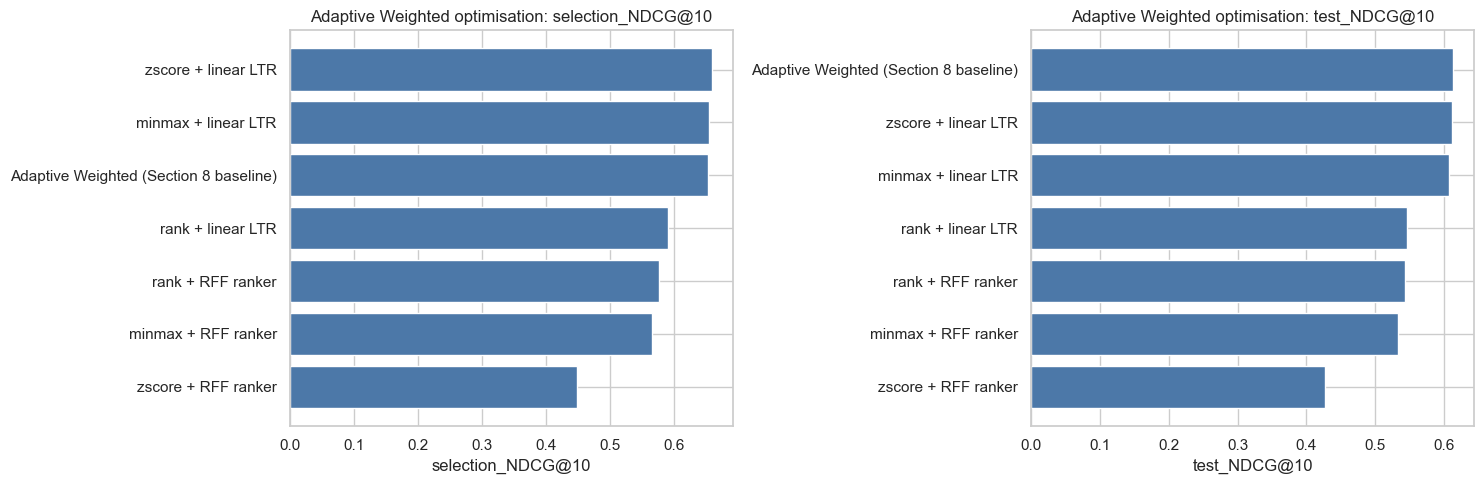

In [102]:
required_result_groups = {
    "10.3 baseline": "baseline_optimisation_row",
    "10.4 linear LTR": "linear_ltr_rows",
    "10.5 RFF": "rff_rows",
}
missing_groups = [label for label, variable in required_result_groups.items() if variable not in globals()]
if missing_groups:
    raise RuntimeError("Run the missing optimisation sections first: " + ", ".join(missing_groups))

optimisation_rows = [
    baseline_optimisation_row,
    *linear_ltr_rows.values(),
    *rff_rows.values(),
]
optimisation_score_sets = {
    **baseline_optimisation_score_set,
    **linear_ltr_score_sets,
    **rff_score_sets,
}
if len(optimisation_rows) != 7 or len(optimisation_score_sets) != 7:
    raise RuntimeError(
        f"Incomplete 3 × 2 comparison: rows={len(optimisation_rows)}, "
        f"score sets={len(optimisation_score_sets)}. Re-run Sections 10.3–10.5."
    )

adaptive_optimisation_results = pd.DataFrame(optimisation_rows).sort_values(
    "selection_NDCG@10", ascending=False
).reset_index(drop=True)
best_adaptive_method = str(adaptive_optimisation_results.loc[0, "method"])
# The first array contains predictions from a model fitted on meta-training users.
# It is used only through the held-out selection metrics recorded above, never as a
# whole-validation estimate. The refitted model's test predictions are safe to report.
_, best_adaptive_test_scores = optimisation_score_sets[best_adaptive_method]

display(adaptive_optimisation_results)
print("Best Adaptive Weighted variant selected on held-out validation users:", best_adaptive_method)
adaptive_optimisation_results.to_csv(
    OUTPUT_DIR / "adaptive_weighted_optimisation_comparison.csv", index=False
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ["selection_NDCG@10", "test_NDCG@10"]):
    ordered = adaptive_optimisation_results.sort_values(metric, ascending=False)
    ax.barh(ordered["method"], ordered[metric], color="#4C78A8")
    ax.set_title(f"Adaptive Weighted optimisation: {metric}")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "adaptive_weighted_optimisation_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Final Comparison

This section consolidates the final test results for four representative approaches:
the Content-Based model, Two-Tower model, GRU4Rec sequential model and
the hybrid configuration selected exclusively by held-out validation NDCG@10. Depending
on the optimisation outcome, the selected hybrid may be the original Adaptive Weighted
baseline, a linear Learning-to-Rank model or an RFF ranker.

The comparison reports Hit@10, Recall@10, NDCG@10 and Mean Reciprocal Rank (MRR). It also
reports Catalogue Coverage, Novelty and Intra-List Diversity to describe the breadth and
composition of each model's Top-10 recommendations. Results and visualisations are
exported for reproducibility.


,model,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
3,Best hybrid: zscore + linear LTR,0.825828,0.825828,0.082583,0.611358,0.552668,64867,0.932995,0.808795,0.625122
1,Two-Tower,0.763886,0.763886,0.076389,0.521595,0.457230,64867,0.978099,0.830263,0.655406
0,Content: Weighted-TFIDF,0.591441,0.591441,0.059144,0.428251,0.393531,64867,0.818315,0.827954,0.547997
2,Sequential: GRU4Rec,0.640742,0.640742,0.064074,0.423697,0.371434,64867,0.832739,0.796191,0.679514


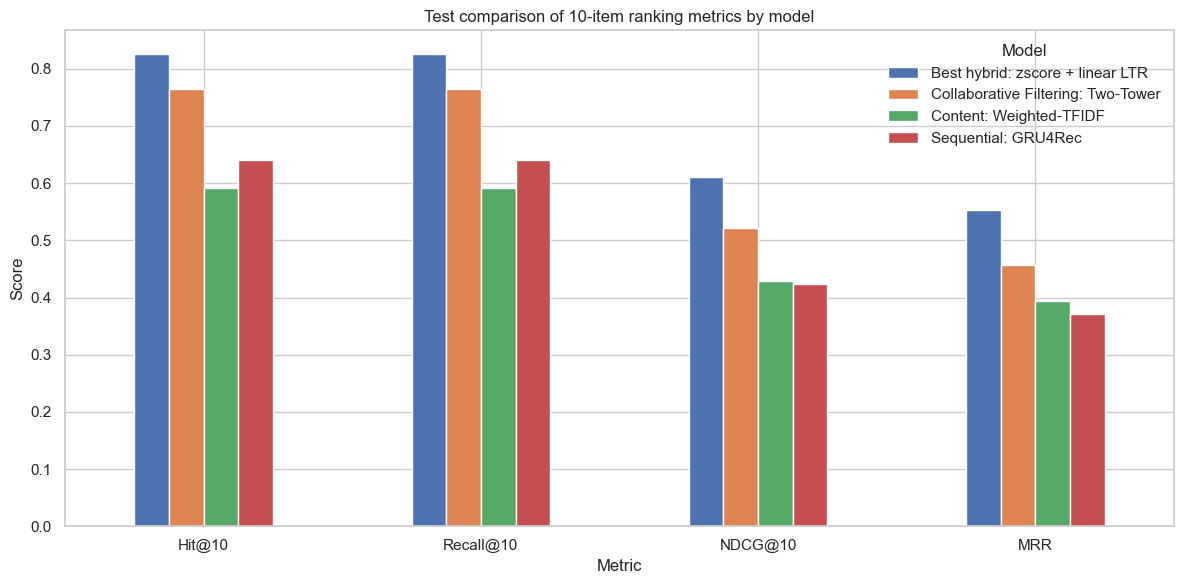

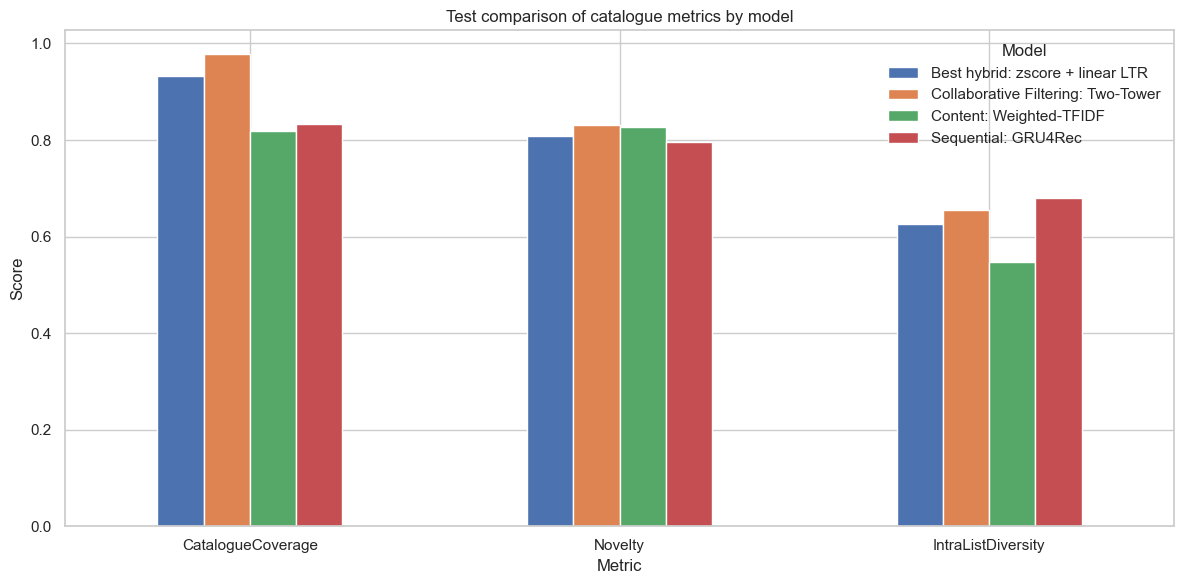

In [103]:
if "best_adaptive_method" not in globals() or "best_adaptive_test_scores" not in globals():
    raise RuntimeError("Run Sections 10.3–10.6 before the final comparison.")

model_name = f"Best hybrid: {best_adaptive_method}"
comparison_model_names = [
    "Content: Weighted-TFIDF",
    "Two-Tower",
    "Sequential: GRU4Rec",
]

# Reuse the already evaluated component-model test rows. The selected hybrid is added
# directly as a test-only result: its meta-training predictions must not be presented as
# an unbiased whole-validation estimate.
component_test_results = pd.DataFrame(results).loc[
    lambda frame: frame["model"].isin(comparison_model_names) & frame["split"].eq("test")
].drop_duplicates(subset=["model", "split"], keep="last")

missing_models = set(comparison_model_names) - set(component_test_results["model"])
if missing_models:
    raise RuntimeError(
        "Run Section 7 before this comparison. Missing test results for: "
        + ", ".join(sorted(missing_models))
    )

best_hybrid_test_result = {
    "model": model_name,
    "split": "test",
    **ranking_metrics(best_adaptive_test_scores),
    **catalogue_metrics_fn(best_adaptive_test_scores, test_candidates),
}
test_results = pd.concat(
    [component_test_results, pd.DataFrame([best_hybrid_test_result])],
    ignore_index=True,
).sort_values(f"NDCG@{TOP_K}", ascending=False)

test_results.to_csv(OUTPUT_DIR / "all_model_results_optimised.csv", index=False)
display(test_results.drop(columns=["split"]))

metrics = [f"Hit@{TOP_K}", f"Recall@{TOP_K}", f"NDCG@{TOP_K}", "MRR"]
plot_data = test_results.set_index("model")[metrics].T

fig, ax = plt.subplots(figsize=(12, 6))
plot_data.plot(kind="bar", ax=ax)
ax.set_title(f"Test comparison of {TOP_K}-item ranking metrics by model")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.legend(title="Model", loc="upper right", bbox_to_anchor=(1, 1))
ax.set_xticklabels(metrics, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_model_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

catalogue_metric_names = ["CatalogueCoverage", "Novelty", "IntraListDiversity"]
catalogue_plot_data = test_results.set_index("model")[catalogue_metric_names].T

fig, ax = plt.subplots(figsize=(12, 6))
catalogue_plot_data.plot(kind="bar", ax=ax)
ax.set_title("Test comparison of catalogue metrics by model")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.legend(title="Model", loc="upper right", bbox_to_anchor=(1, 1))
ax.set_xticklabels(catalogue_metric_names, rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_model_catalogue_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


# 7. Conclusion

## Overall outcome

This project developed and evaluated an integrated Kindle eBook recommendation pipeline covering data analysis, reproducible preprocessing, content-based recommendation, sequential recommendation,  Two-Tower, and hybrid ranking. The central result is that the three component models capture complementary signals. Content features describe what a book is about, the Two-Tower model learns persistent user–item affinity from interaction data, and GRU4Rec models the order and recency of a user's reading behaviour. Combining these signals produces a materially stronger ranking than relying on any component alone.

Under the final shared evaluation implementation, the validation-selected **z-score + linear Learning-to-Rank hybrid** achieved **Recall/Hit@10 = 0.8258, NDCG@10 = 0.6114, and MRR = 0.5527** across 64,867 test users. The strongest individual model, Two-Tower, reached Recall@10 = 0.7639, NDCG@10 = 0.5216, and MRR = 0.4572. The locked hybrid therefore improved NDCG@10 by approximately **17.2%** and Recall@10 by approximately **8.1%** relative to the best standalone model. This supports the main hypothesis of the project: heterogeneous preference signals are more useful when fused at candidate-score level than when treated as competing alternatives.

## Data and experimental design

The raw Kindle Store collection is large, sparse, and strongly long-tailed: it contains about 25.6 million review interactions from 5.65 million users over 1.59 million items, while the median user has only one interaction. Ratings are also positively skewed, with approximately 86.3% of interactions rated at least four stars. These properties motivate both positive-feedback filtering and explicit control of sparsity. Metadata is useful but incomplete—most notably, descriptions are missing for a substantial proportion of items—so no single content field is sufficiently reliable on its own.

The preprocessing pipeline restricted interactions to 2014–2022, retained ratings of at least four, kept the latest user–item interaction, required a metadata match, applied iterative 5-core filtering, and used user-activity-stratified sampling. The resulting experiment contains **64,867 users, 81,322 items, and 1,013,870 positive interactions**, divided chronologically into 884,136 training interactions and one validation plus one test interaction per user. Validation uses training history only, while test uses training history plus the validation item. Every reported final ranking is evaluated against the same one-positive-plus-100-fixed-negatives candidate set. This chronological, aligned protocol reduces leakage and makes the final model comparison internally consistent.

## Findings from the component models

The content experiments show that representation design mattered more than adding dimensionality reduction. The selected field-weighted TF-IDF model emphasised title and category information and obtained test Recall@10 = 0.5914, NDCG@10 = 0.4283, and MRR = 0.3935. It substantially outperformed the popularity baseline (test NDCG@10 = 0.2355). Including author information improved the tuned SVD family, whereas increasing the verified-purchase multiplier above 1.0 did not help. Both ordinary and field-weighted SVD variants remained below the unreduced field-weighted TF-IDF representation, indicating that compression discarded ranking-relevant lexical information in this setting. Content recommendation nevertheless had the lowest intra-list diversity of the three components (0.5480), consistent with recommending semantically similar books.

The sequential experiments demonstrate that recent interaction order contains useful information, but model choice is important. The lightweight SASRec configurations were comparatively weak under the short-history setting, whereas GRU4Rec learned a substantially more effective next-item signal. In the final shared test evaluation, GRU4Rec achieved Recall@10 = 0.6407, NDCG@10 = 0.4237, and MRR = 0.3714. It also produced the highest intra-list diversity among the component models (0.6795), but its novelty was the lowest (0.7962), suggesting that sequential relevance and catalogue exploration are not identical objectives. The notebook's Markov and GRU4Rec–Markov experiments further show that low-complexity transition information is a meaningful baseline and should not be omitted when claiming gains from neural sequence modelling.

Two-Tower was the strongest standalone approach in the unified comparison. Its test Recall@10 of 0.7639, NDCG@10 of 0.5216, and MRR of 0.4572 indicate that learned long-term user–item affinity is especially effective for this filtered dataset. It also reached the highest catalogue coverage (0.9781) and highest novelty (0.8303) among the final models. The negative-sampling ablation supports the use of hybrid negative sampling. For cross-model conclusions, the final shared evaluation is therefore treated as authoritative.

##  Hybrid-model interpretation

Simple weighted fusion already delivered a large improvement. Per-user z-score normalisation followed by validation-tuned weights of 0.19 for content, 0.39 for Two-Tower, and 0.42 for GRU4Rec produced test Recall@10 = 0.8226, NDCG@10 = 0.6128, and MRR = 0.5555. The relatively balanced CF and sequential weights confirm that long-term affinity and short-term intent both contribute strongly, while the smaller non-zero content weight provides information not fully represented by interaction embeddings. The tested cascade strategy reached test Recall@10 = 0.7930 and NDCG@10 = 0.5951. It remained stronger than every standalone model on NDCG, but below score-level fusion, illustrating that early candidate filtering can discard useful cross-model evidence when the official candidate set is already small.

The optimisation study compared the weighted baseline with linear and nonlinear meta-rankers across z-score, min–max, and rank normalisation. Model selection used only held-out validation users. **Z-score + linear LTR** was selected with held-out selection NDCG@10 = 0.6599 and reached test Recall@10 = 0.8258 and NDCG@10 = 0.6114. The manually tuned weighted fusion was marginally higher on test NDCG@10 (0.6128) and MRR (0.5555), while the locked LTR model was higher on Recall@10. This small reversal is reported rather than using the test set to re-select the model. It indicates that most of the gain comes from aligning and combining component scores; more flexible Random Fourier Feature rankers did not generalise as well.

The accuracy gain involves a catalogue-quality trade-off. The locked hybrid's catalogue coverage of 0.9330 is higher than content-based or GRU4Rec coverage but below Two-Tower's 0.9781. Its novelty (0.8088) and intra-list diversity (0.6251) are also below the strongest component values. Fusion therefore improves the probability and position of the held-out item, but does not simultaneously maximise every diversity objective. A production system should treat relevance, novelty, coverage, and diversity as separate objectives rather than assuming that the most accurate offline ranker is optimal for all users and business goals.

## Limitations and future work

These results are conditional on the offline protocol. Because each user is ranked against 100 sampled negatives rather than the full 81,322-item catalogue, the reported Recall, NDCG, MRR, coverage, novelty, and diversity values should not be interpreted as full-catalogue or online performance. With exactly one relevant item per user, Hit@10 equals Recall@10 and Precision@10 is mechanically Hit@10 divided by ten. Historical reviews also reflect exposure and selection bias, missing metadata may disadvantage some items, the 5-core filter excludes true cold-start users and items, and a single chronological holdout cannot represent every future preference change.

The most valuable extensions would be: full-catalogue retrieval followed by re-ranking; time-aware and hard-negative sampling; explicit cold-start evaluation; richer text embeddings for missing or semantically complex metadata; calibration or gating that adapts fusion weights by user-history length and confidence; and multi-objective re-ranking that controls diversity and novelty while preserving relevance. Repeated runs across random seeds and temporal windows, followed by online A/B testing, would be required before deployment. Within the present scope, however, the evidence is consistent and practically meaningful: **the validation-selected linear hybrid improves ranking accuracy over every standalone model, while Two-Tower remains the strongest standalone and broadest-coverage model.**


# 8. Other Issues and Execution Boundaries

The following items are intentionally listed separately from the modelling narrative:

1. **End-to-end execution is verified.** All 103 code cells were executed successfully in order
   under the local `c9517` kernel (Python 3.10.19) on 5–6 August 2026, with no error outputs.
2. **Raw-data stages are expensive.** Full EDA scans read multi-gigabyte gzip files and full
   preprocessing uses a SQLite work database. Cached summaries and `processed_kindle/` are reused
   by default.
3. **Neural training is expensive.** The verified end-to-end run took about 3 hours 38 minutes.
   Sequential tuning, Two-Tower training and the Two-Tower ablation dominate the runtime; GPU
   acceleration is strongly recommended for reproducing the full run.
4. **Hybrid prerequisites are strict.** Hybrid execution requires the content score export,
   Two-Tower checkpoint and GRU4Rec checkpoint produced by the preceding sections.
5. **Legacy metric naming.** With exactly one relevant candidate per user, Recall@10 equals
   Hit@10, while the reported Precision@10 is Hit@10 divided by 10. These values should not be
   interpreted as multi-relevance catalogue precision/recall.
6. **Environment dependencies.** The complete notebook requires NumPy, pandas, SciPy,
   scikit-learn, matplotlib, PyTorch, joblib and optionally seaborn. GPU acceleration is strongly
   recommended for neural training.
7. **Harmless framework warnings.** PyTorch emitted three `enable_nested_tensor` warnings for
   SASRec because `norm_first=True`; these do not indicate failed cells or invalid outputs.
8. **Offline boundary.** The shared 101-candidate protocol enables aligned comparison, but the
   reported ranking metrics are not substitutes for full-catalogue retrieval or online testing.

The integrated notebook includes ordering, local path portability, reproducibility controls,
metric and checkpoint correctness fixes, score normalisation, and removal of redundant Colab
mounting. The original module notebooks remain unchanged for traceability.
